<h1 style="text-align: center;">Arabic Dialect Identification<h1>

Prepare libraries

In [1]:
import pandas as pd
import os
import pickle
import re
import matplotlib.pyplot as plt
import nltk
import numpy as np
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud
from collections import Counter
from nltk.util import bigrams,trigrams
import random
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score,classification_report
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import LabelBinarizer
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.naive_bayes import MultinomialNB
import arabic_reshaper
from bidi.algorithm import get_display

In [2]:
# %pip install wordcloud
# %pip install arabic_reshaper
# %pip install python-bidi
# %pip install openpyxl
# nltk.download('stopwords')


In [3]:
# from google.colab import drive
# drive.mount('/content/drive')


<h2 dir="rtl">مثال عن كيفية تنظيم حلول الطلبات:

قم بوضع الخلايا الأربع التالية لحل كل طلب</h2>

<div dir="rtl">ملاحظاتك في حال وجودها</div>
<div dir="rtl">يمكنك إضافة خلايا لكل طلب بقدر ما تشاء، المهم أن تحافظ على تنظيم الملف</div>

# مهمة 01  : تحميل البيانات

### Madar

## [1.1]

و طباعة العدد الكلي للعيناتmadarتحميل داتا

In [4]:
# folder_path = "/content/drive/MyDrive/Nlp1/MADAR_Corpus"
folder_path = "C:\\Users\\EUROPELAPTOP\\Desktop\\5th\\NLP\\Labs\\NLP_homework\\MADAR_Corpus"


files = [f for f in os.listdir(folder_path) ]

dataframes = []

for file in files:
    file_path = os.path.join(folder_path, file)
    df = pd.read_csv(file_path, sep='\t')
    dataframes.append(df)

Madar_dataframe = pd.concat(dataframes, ignore_index=True)

len(Madar_dataframe)


124000

طباعة أول عشرة أسطر

In [5]:
Madar_dataframe.head(10)

,sentID.BTEC,split,lang,sent
0,5,corpus-6-test-corpus-26-train,ALE,هو هنيك، قدام معلومات السياح بالضبط.
1,9,corpus-6-test-corpus-26-train,ALE,مالي سمعان من قبل بهالعنوان هون.
2,11,corpus-6-test-corpus-26-train,ALE,روح ساوي لبين ما تشوف صيدلية.
3,26,corpus-6-test-corpus-26-train,ALE,بشقد الفطور؟
4,27,corpus-6-test-corpus-26-train,ALE,شلون بقدر أساعدك؟
5,30,corpus-6-test-corpus-26-train,ALE,روح عاليسار عند تالت مفرق.
6,50,corpus-6-test-corpus-26-train,ALE,بتريد كريمة وسكر بقهوتك؟
7,64,corpus-6-test-corpus-26-train,ALE,خرج تصرفلي شيك الميتين دولار تبعي؟
8,74,corpus-6-test-corpus-26-train,ALE,إذا لازم يبين، اتصل فيني إذا سمحت.
9,86,corpus-6-test-corpus-26-train,ALE,وين الكافيه؟


التحقق من وجود خلايا فارغة

In [6]:
missing_cells = Madar_dataframe.isnull().sum().sum()
print("NAN rows:", missing_cells)

NAN rows: 24000


  للاسطر التي تحوي خلايا فارغة lang طباعة قيمة العمود

In [7]:
lang_nan_values = Madar_dataframe.loc[Madar_dataframe.isnull().any(axis=1), 'lang']

print(lang_nan_values)

54000    EN
54001    EN
54002    EN
54003    EN
54004    EN
         ..
79995    FR
79996    FR
79997    FR
79998    FR
79999    FR
Name: lang, Length: 24000, dtype: object


 ف نستطيع ازالتها FR  و  EN جميعها

In [8]:
Madar_dataframe = Madar_dataframe.dropna()
print(len(Madar_dataframe))


100000


التحقق من الاسطر المكررة

In [9]:
duplicate_rows = Madar_dataframe.duplicated().sum()
print("duplicate rows:", duplicate_rows)


duplicate rows: 0


التحقق من الاسطر المكررة على مستوى الجملة و اللهجة و تقسيم الداتا

In [10]:
duplicates = Madar_dataframe.duplicated(subset=['sent', 'lang','split'])
duplicate_rows = Madar_dataframe[duplicates]
len(duplicate_rows)



485

In [11]:
duplicate_rows.head(-100)

,sentID.BTEC,split,lang,sent
667,6812,corpus-6-test-corpus-26-train,ALE,وين قسم السيدات؟
982,10156,corpus-6-test-corpus-26-train,ALE,وين الحمامات؟
1700,17038,corpus-6-test-corpus-26-train,ALE,بتحسن تصلح هاد؟
1810,18323,corpus-6-test-corpus-26-train,ALE,اش هي المحطة الجاية؟
1899,19144,corpus-6-test-corpus-26-train,ALE,راسي عم يوجعني.
...,...,...,...,...
96892,11540,corpus-6-train,RAB,عمر، عافاك.
97440,12460,corpus-6-train,RAB,فيا الرواح.
97863,13121,corpus-6-train,RAB,فينا هو استلام الامتعة؟
98144,13587,corpus-6-train,RAB,بنين.


ف نستطيع ازالتها id  بما ان الجمل المكررة مختلفة فقط في ال

In [12]:
Madar_dataframe = Madar_dataframe.drop_duplicates(subset=['sent', 'lang', 'split'])

In [13]:
len(Madar_dataframe)

99515

In [14]:
# train_count = len(Madar_dataframe[Madar_dataframe['split'] == 'corpus-6-train'])
# print(f"train count: {train_count}")


## [1.2]

الكود يقرأ بيانات من ملف اكسل يدمجها مع داتا فريم آخر بناء على تطابق القيم في عمود اللغة، ثم يعيد تسمية الأعمدة

In [15]:

# excel_path = '/content/drive/My Drive/Nlp1/dialect_name_unification.xlsx'
excel_path = "C:\\Users\\EUROPELAPTOP\\Desktop\\5th\\NLP\\Labs\\NLP_homework\\dialect_name_unification.xlsx"
excel_df = pd.read_excel(excel_path)

city_column = excel_df.columns[6]
region_column = excel_df.columns[1]
country_column = excel_df.columns[4]

Madar_dataframe = Madar_dataframe.merge(
    excel_df[[city_column, region_column, country_column]],
    left_on="lang",
    right_on=city_column,
    how="left"
)

Madar_dataframe = Madar_dataframe.rename(columns={region_column: "region", country_column: "country"})


Madar_dataframe = Madar_dataframe.drop(columns=[city_column])



In [16]:
Madar_dataframe.head(-10)

,sentID.BTEC,split,lang,sent,region,country
0,5,corpus-6-test-corpus-26-train,ALE,هو هنيك، قدام معلومات السياح بالضبط.,Levant,Syria
1,9,corpus-6-test-corpus-26-train,ALE,مالي سمعان من قبل بهالعنوان هون.,Levant,Syria
2,11,corpus-6-test-corpus-26-train,ALE,روح ساوي لبين ما تشوف صيدلية.,Levant,Syria
3,26,corpus-6-test-corpus-26-train,ALE,بشقد الفطور؟,Levant,Syria
4,27,corpus-6-test-corpus-26-train,ALE,شلون بقدر أساعدك؟,Levant,Syria
...,...,...,...,...,...,...
99500,19943,corpus-6-train,TUN,سامحني، عنا كان بيرة و ويسكي.,Maghreb,Tunisia
99501,19944,corpus-6-train,TUN,هو لبرا مل بيرو توا. نجم نخليلو مساج؟,Maghreb,Tunisia
99502,19945,corpus-6-test-corpus-26-train,TUN,زوز كبار و طفل عمرو تلاثة سنين.,Maghreb,Tunisia
99503,19947,corpus-6-train,TUN,يعيشك استعمل شيكات سياحية.,Maghreb,Tunisia


In [17]:
len(Madar_dataframe)

99515

qadi لتتناسب مع داتا  madar  في داتا  split  قبل دمج الداتا نعدل اسماء الاعمدة و اسطر العمود  

In [18]:
split_mapping = {
    "corpus-6-train": "train",
    "corpus-6-dev": "validation",
    "corpus-6-test-corpus-26-train": "train",
    "corpus-6-test-corpus-26-dev": "validation",
    "corpus-6-test-corpus-26-test": "test"
}

Madar_dataframe['split'] = Madar_dataframe['split'].replace(split_mapping)

Madar_dataframe = Madar_dataframe.rename(columns={
    'sentID.BTEC': 'id',
    'sent': 'text',
    'lang': 'city'
})

Madar_dataframe.head()


,id,split,city,text,region,country
0,5,train,ALE,هو هنيك، قدام معلومات السياح بالضبط.,Levant,Syria
1,9,train,ALE,مالي سمعان من قبل بهالعنوان هون.,Levant,Syria
2,11,train,ALE,روح ساوي لبين ما تشوف صيدلية.,Levant,Syria
3,26,train,ALE,بشقد الفطور؟,Levant,Syria
4,27,train,ALE,شلون بقدر أساعدك؟,Levant,Syria


### QADI

## [1.1]

لتحديد كل سطر الى اي مجموعة ينتمي  split  تحوي ثلاث ملفات لبيانات التدريب والتحقق وللبيانات الخاصة بالاختبار ف قمنا باضافة عمود اسمه  qadi  هنا مجموعة البيانات الخاصة ب


In [19]:
# folder_path = '/content/drive/My Drive/Nlp1/QADI'
folder_path = "C:\\Users\\EUROPELAPTOP\\Desktop\\5th\\NLP\\Labs\\NLP_homework\\QADI"

files = [f for f in os.listdir(folder_path) ]

dataframes = []

for file in files:
    file_path = os.path.join(folder_path, file)

    df = pd.read_parquet(file_path)

    if 'train' in file:
        df['split'] = 'train'
    elif 'test' in file:
        df['split'] = 'test'
    elif 'validation' in file:
        df['split'] = 'validation'

    dataframes.append(df)

qadi_dataframe = pd.concat(dataframes, ignore_index=True)
train_count = len(qadi_dataframe[qadi_dataframe['split'] == 'train'])
test_count = len(qadi_dataframe[qadi_dataframe['split'] == 'test'])
validation_count =len(qadi_dataframe[qadi_dataframe['split'] == 'validation'])

print(f"train count: {train_count}")
print(f"test count: {test_count}")
print(f"validation count: {validation_count}")
print(f"total: {len(qadi_dataframe)}")

train count: 440052
test count: 8981
validation count: 9164
total: 458197


In [20]:
qadi_dataframe.head(10)

,id,label,text,split
0,1159906099585327104,10,ايه الخيبة و الهرتلة قدام الجون دول؟؟ 🤪😲\nالعي...,test
1,950123809608171648,14,@FIA_WIS تذكرت ما اسمي عائشة انا اسمي خولة,test
2,1091295506960142336,2,@showqiy @3nood_mh لا والله نروح نشجع قطر و نف...,test
3,1179845110718181376,14,@espoir_dz1 يسلملي قلبك ولد مدينتي,test
4,1011983655546302464,10,ملخص مؤتمر أبو سبوبة، قصدي أبو ريدة....احنا عم...,test
5,1163125327318704128,4,@VJSdI48K5DnXaX9 ياليت تركز أقصد السياحية الدا...,test
6,1097560483303997440,0,أعتقد انحس إسبوع مر بحياتي ، مرتين السياره توق...,test
7,988460473912705024,11,تزكرت بس هديك المره بتحلطم لك ع البنت الي معي ...,test
8,949396064821481600,0,@Omantel ياخلفان ياللي بعمانتل هدقتنا بنفس الع...,test
9,938545640891613184,4,@asool10201 @AlsaeedFajer ياشيخ عقلك في جوتي ا...,test


التحقق من الاسطر المكررة

In [21]:
duplicate_rows = qadi_dataframe.duplicated().sum()
print("duplicate rows:", duplicate_rows)


duplicate rows: 0


In [22]:
duplicates = qadi_dataframe.duplicated(subset=['text', 'label','split'])
duplicate_rows = qadi_dataframe[duplicates]
len(duplicate_rows)

0

التحقق من وجود خلايا فارغة

In [23]:
missing_cells = qadi_dataframe.isnull().sum().sum()
print("NAN rows:", missing_cells)

NAN rows: 0


## [1.2]

الخاص بالبلد  id  الى اسماء البلدان بدلا من ال  label  هنا نقوم بتغيير قيم عمود ال

In [24]:
names = ['OM', 'SD', 'SA', 'KW', 'QA', 'LB', 'JO', 'SY', 'IQ', 'MA',
         'EG', 'PL', 'YE', 'BH', 'DZ', 'AE', 'TN', 'LY']
qadi_dataframe['label'] = qadi_dataframe['label'].map({i: name for i, name in enumerate(names)})

In [25]:
qadi_dataframe.head(10)

,id,label,text,split
0,1159906099585327104,EG,ايه الخيبة و الهرتلة قدام الجون دول؟؟ 🤪😲\nالعي...,test
1,950123809608171648,DZ,@FIA_WIS تذكرت ما اسمي عائشة انا اسمي خولة,test
2,1091295506960142336,SA,@showqiy @3nood_mh لا والله نروح نشجع قطر و نف...,test
3,1179845110718181376,DZ,@espoir_dz1 يسلملي قلبك ولد مدينتي,test
4,1011983655546302464,EG,ملخص مؤتمر أبو سبوبة، قصدي أبو ريدة....احنا عم...,test
5,1163125327318704128,QA,@VJSdI48K5DnXaX9 ياليت تركز أقصد السياحية الدا...,test
6,1097560483303997440,OM,أعتقد انحس إسبوع مر بحياتي ، مرتين السياره توق...,test
7,988460473912705024,PL,تزكرت بس هديك المره بتحلطم لك ع البنت الي معي ...,test
8,949396064821481600,OM,@Omantel ياخلفان ياللي بعمانتل هدقتنا بنفس الع...,test
9,938545640891613184,QA,@asool10201 @AlsaeedFajer ياشيخ عقلك في جوتي ا...,test


الكود يقرأ بيانات من ملف اكسل يدمجها مع داتا فريم آخر بناء على تطابق القيم في عمود التصنيف، ثم يعيد تسمية بعض الأعمدة ويحذف الأعمدة والتكرارات غير المطلوبة

In [26]:
# excel_path = '/content/drive/My Drive/Nlp1/dialect_name_unification.xlsx'
excel_path = "C:\\Users\\EUROPELAPTOP\\Desktop\\5th\\NLP\\Labs\\NLP_homework\\dialect_name_unification.xlsx"

excel_df = pd.read_excel(excel_path)

label_column = excel_df.columns[3]
region_column = excel_df.columns[1]
country_column = excel_df.columns[4]

qadi_dataframe = qadi_dataframe.merge(
    excel_df[[label_column, region_column, country_column]],
    left_on="label",
    right_on=label_column,
    how="left"
)

qadi_dataframe = qadi_dataframe.rename(columns={region_column: "region", country_column: "country"})

qadi_dataframe = qadi_dataframe.drop(columns=[label_column])
qadi_dataframe = qadi_dataframe.drop(columns=["label"])
qadi_dataframe = qadi_dataframe.drop_duplicates()

print(f"total: {len(qadi_dataframe)}")


total: 458197


 madar مع   داتا  data frame نضيف عمود جديد للمدينة بقيم فارغة لتطابق ال

In [27]:
qadi_dataframe['city'] = pd.NA

In [28]:
qadi_dataframe.head(10)

,id,text,split,region,country,city
0,1159906099585327104,ايه الخيبة و الهرتلة قدام الجون دول؟؟ 🤪😲\nالعي...,test,Nile_Basin,Egypt,<NA>
3,950123809608171648,@FIA_WIS تذكرت ما اسمي عائشة انا اسمي خولة,test,Maghreb,Algeria,<NA>
5,1091295506960142336,@showqiy @3nood_mh لا والله نروح نشجع قطر و نف...,test,Gulf,Saudi Arabia,<NA>
7,1179845110718181376,@espoir_dz1 يسلملي قلبك ولد مدينتي,test,Maghreb,Algeria,<NA>
9,1011983655546302464,ملخص مؤتمر أبو سبوبة، قصدي أبو ريدة....احنا عم...,test,Nile_Basin,Egypt,<NA>
12,1163125327318704128,@VJSdI48K5DnXaX9 ياليت تركز أقصد السياحية الدا...,test,Gulf,Qatar,<NA>
13,1097560483303997440,أعتقد انحس إسبوع مر بحياتي ، مرتين السياره توق...,test,Gulf,Oman,<NA>
14,988460473912705024,تزكرت بس هديك المره بتحلطم لك ع البنت الي معي ...,test,Levant,Palestine,<NA>
16,949396064821481600,@Omantel ياخلفان ياللي بعمانتل هدقتنا بنفس الع...,test,Gulf,Oman,<NA>
17,938545640891613184,@asool10201 @AlsaeedFajer ياشيخ عقلك في جوتي ا...,test,Gulf,Qatar,<NA>


## [1.3]

qadi data frame مع  madar data frame  ندمج  

In [29]:
merged_dataframe = pd.concat([Madar_dataframe, qadi_dataframe], ignore_index=True)
len(merged_dataframe)

557712

In [30]:
merged_dataframe.head(-10)

,id,split,city,text,region,country
0,5,train,ALE,هو هنيك، قدام معلومات السياح بالضبط.,Levant,Syria
1,9,train,ALE,مالي سمعان من قبل بهالعنوان هون.,Levant,Syria
2,11,train,ALE,روح ساوي لبين ما تشوف صيدلية.,Levant,Syria
3,26,train,ALE,بشقد الفطور؟,Levant,Syria
4,27,train,ALE,شلون بقدر أساعدك؟,Levant,Syria
...,...,...,...,...,...,...
557697,1140859255819579392,validation,NaN,@BintOma34737874 @TaawonNetwork @Najlaalameer ...,Gulf,Oman
557698,850662745506709504,validation,NaN,@bogaili واضح من عيونه يابو محمد,Gulf,Kawait
557699,1137230486852518016,validation,NaN,انزين اقعد في ديرتك اكو ابو صفريه جاب البيزات,Gulf,Bahrin
557700,1032654838742622208,validation,NaN,بالمنام عم شوفك انا..\n#بالغرام,Levant,Syria


# مهمة 02 : فهم وتحليل البيانات

EDA

## [2.1]


train فلترة داتا ال

In [31]:
train = merged_dataframe[merged_dataframe['split'] == 'train'].copy()


In [32]:
len(train)

524581

عدد النصوص في كل مدينة

city
RAB    10553
CAI    10550
TUN    10544
BEI    10532
DOH    10438
SAN     1598
SAL     1598
MOS     1598
DAM     1598
FES     1597
BAS     1597
AMM     1597
ALX     1596
MUS     1596
ASW     1596
BEN     1595
KHA     1595
RIY     1595
SFX     1595
TRI     1595
ALE     1595
BAG     1594
JED     1593
JER     1593
ALG     1591
Name: count, dtype: int64


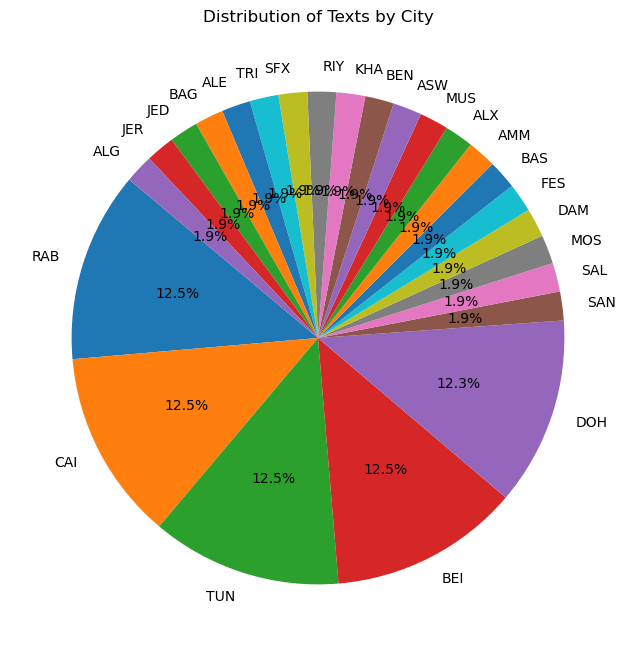

In [33]:
city_counts = train['city'].value_counts()
print(city_counts)
plt.figure(figsize=(8, 8))
plt.pie(city_counts, labels=city_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Texts by City")
plt.show()


الداتا غير موزعة بشكل متساو على مستوى المدينة حيث اكثرية الجمل تعود للمدن: تونس ,الدوحة, بيروت ,القاهرة ,الرباط وعدد المدن 25

عدد النصوص في كل منطقة

region
Gulf          180136
Levant        129462
Maghreb        99627
Nile_Basin     84552
Iraqi          19672
Yemen          11132
Name: count, dtype: int64


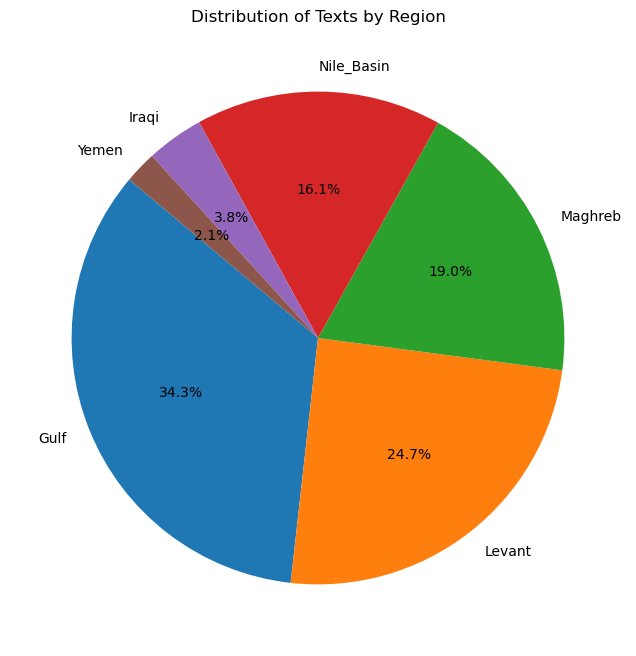

In [34]:
region_counts = train['region'].value_counts()
print(region_counts)

plt.figure(figsize=(8, 8))
plt.pie(region_counts, labels=region_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Texts by Region")
plt.show()


الداتا غير موزعة بشكل متساو حيث اكثرية الجمل تابعة للمنطقة الشامية والخليجية وعدد المناطق هو 6

عدد النصوص في كل دولة

country
Egypt           69095
Palestine       43603
Kawait          40442
Qatar           40277
Libya           38243
Lebanon         37056
Jordan          30011
Saudi Arabia    28957
Emirates        25254
Bahrin          25251
Morocco         23232
Tunisia         21019
Oman            19955
Iraq            19672
Syria           18792
Algeria         17133
Sudan           15457
Yemen           11132
Name: count, dtype: int64


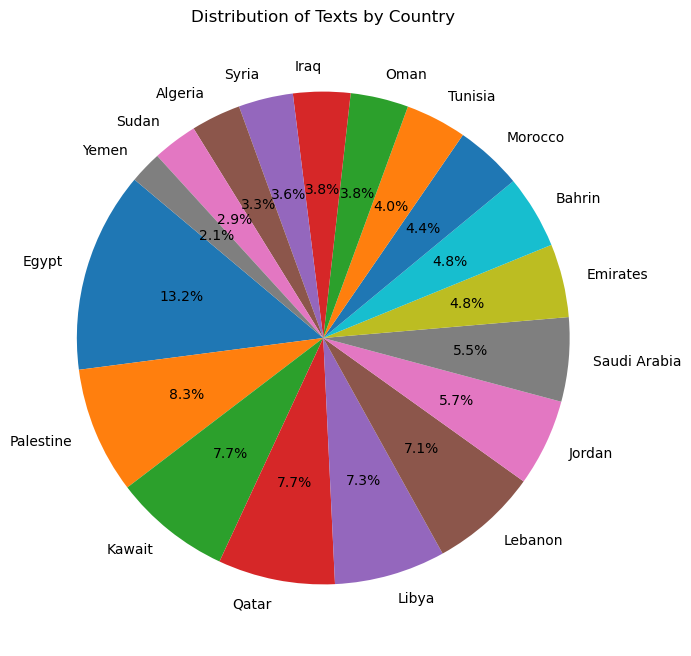

In [35]:
country_counts = train['country'].value_counts()
print(country_counts)

plt.figure(figsize=(8, 8))
plt.pie(country_counts, labels=country_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribution of Texts by Country")
plt.show()


الداتا موزع بشكل افضل نوعا ما بالنسبة للمدينة و المنطقة و يوجد جمل ل 18 دولة

## [2.2]

\d+ : رقم او اكثر
__ [\w]+ : يطابق الكلمات
__ [^\w\s] : يطابق أي رمز ليس حرفًا أو فراغًا

 يقوم الكود بتقسيم النصوص  إلى كلمات وعلامات ترقيم و ايموجيز باستخدام التعبيرات النمطية، وتخزينها في عمود جديد

In [36]:
def custom_tokenizer(text):
    pattern = r'\d+|[\w]+|[^\w\s]'
    return re.findall(pattern, text)

train['tokens'] = train['text'].apply(custom_tokenizer)


In [35]:
train[['text', 'tokens']].head(-10)

,text,tokens
0,هو هنيك، قدام معلومات السياح بالضبط.,"[هو, هنيك, ،, قدام, معلومات, السياح, بالضبط, .]"
1,مالي سمعان من قبل بهالعنوان هون.,"[مالي, سمعان, من, قبل, بهالعنوان, هون, .]"
2,روح ساوي لبين ما تشوف صيدلية.,"[روح, ساوي, لبين, ما, تشوف, صيدلية, .]"
3,بشقد الفطور؟,"[بشقد, الفطور, ؟]"
4,شلون بقدر أساعدك؟,"[شلون, بقدر, أساعدك, ؟]"
...,...,...
548533,@chaima_20dz @dalya1314 هههههههههههه واه عندك ...,"[@, chaima_20dz, @, dalya1314, هههههههههههه, و..."
548534,القمر بيضوّي عالناس والناس بيتقاتلوا 🎼💜,"[القمر, بيضو, ّ, ي, عالناس, والناس, بيتقاتلوا,..."
548535,@mycousinvinnyys احنا بناخد اخبارنا من السوشيا...,"[@, mycousinvinnyys, احنا, بناخد, اخبارنا, من,..."
548536,@yas_lens انا ماستخدم سوالف التان احلى لون يوم...,"[@, yas_lens, انا, ماستخدم, سوالف, التان, احلى..."


عدد التوكنز الكلي

In [36]:
total_tokens = train['tokens'].apply(len).sum()
print(f"Total tokens: {total_tokens}")

Total tokens: 9017616


In [37]:
train.head()

,id,split,city,text,region,country,tokens
0,5,train,ALE,هو هنيك، قدام معلومات السياح بالضبط.,Levant,Syria,"[هو, هنيك, ،, قدام, معلومات, السياح, بالضبط, .]"
1,9,train,ALE,مالي سمعان من قبل بهالعنوان هون.,Levant,Syria,"[مالي, سمعان, من, قبل, بهالعنوان, هون, .]"
2,11,train,ALE,روح ساوي لبين ما تشوف صيدلية.,Levant,Syria,"[روح, ساوي, لبين, ما, تشوف, صيدلية, .]"
3,26,train,ALE,بشقد الفطور؟,Levant,Syria,"[بشقد, الفطور, ؟]"
4,27,train,ALE,شلون بقدر أساعدك؟,Levant,Syria,"[شلون, بقدر, أساعدك, ؟]"


عدد التوكنز الفريدة

In [38]:
all_tokens = [token for tokens in train['tokens'] for token in tokens]

vocab = set(all_tokens)
len(vocab)

709143

In [39]:
# for word in vocab:
#     print(word)

In [40]:
arabic_stopwords = set(stopwords.words('arabic'))
english_stopwords = set(stopwords.words('english'))
all_stopwords = arabic_stopwords.union(english_stopwords)

def remove_stopwords(text):
    tokens = custom_tokenizer(text)
    cleaned_tokens = [token for token in tokens if token.lower() not in all_stopwords]
    return " ".join(cleaned_tokens)

train['cleaned_text'] = train['text'].apply(remove_stopwords)


train[['text', 'cleaned_text', ]]


,text,cleaned_text
0,هو هنيك، قدام معلومات السياح بالضبط.,هنيك ، قدام معلومات السياح بالضبط .
1,مالي سمعان من قبل بهالعنوان هون.,مالي سمعان بهالعنوان هون .
2,روح ساوي لبين ما تشوف صيدلية.,روح ساوي لبين تشوف صيدلية .
3,بشقد الفطور؟,بشقد الفطور ؟
4,شلون بقدر أساعدك؟,شلون بقدر أساعدك ؟
...,...,...
548543,انت مش مجبور تجامل حدا وتعطيه اكبر من حجمه ؛ ع...,انت مش مجبور تجامل حدا وتعطيه اكبر حجمه ؛ عادي...
548544,رتم الفريق بدون جيرو سريييييييييع ، مع جيرو يص...,رتم الفريق بدون جيرو سريييييييييع ، جيرو يصير ...
548545,🇸🇦💚🇸🇦💚🇸🇦\nksa\n👆🏻\nوغير هالبلد قلبي ما عشق ولا...,🇸 🇦 💚 🇸 🇦 💚 🇸 🇦 ksa 👆 🏻 وغير هالبلد قلبي عشق ي...
548546,@a7lawa7di @ranim2298 خلص اذا هيييك بطلت ادعي ...,@ a7lawa7di @ ranim2298 خلص اذا هيييك بطلت ادع...


## [2.3]

هذا الكود يعالج النصوص لاستخراج الكلمات الأكثر تكرارا ثم يعرضها في صورة سحابة كلمات تدعم النصوص العربية والإنجليزية

In [41]:
tokens = []
for sent in train['tokens']:
    for word in sent:
        tokens.append(word)

[('.', 413109), ('@', 409947), ('/', 201910), ('😂', 135460), ('من', 102627), ('؟', 85252), ('،', 80767), (':', 79147), ('في', 76367), ('ما', 74853), ('t', 66329), ('co', 66261), ('و', 65580), ('!', 61736), ('https', 61504), ('اللي', 58316), ('#', 55589), ('الله', 47549), ('على', 47529), ('بس', 46303), ('يا', 41921), ('انا', 31319), ('مش', 30800), ('كل', 30756), ('ولا', 26254), ('لا', 24768), ('والله', 23884), ('لو', 23275), ('شي', 21033), ('️', 20441), ('ّ', 19849), ('مع', 19460), ('🤣', 17633), ('انت', 16708), ('"', 16547), ('ان', 16044), ('ع', 15722), ('كان', 15516), ('عن', 15419), ('هو', 15379), ('هذا', 15337), ('❤', 15329), ('😍', 13958), ('واحد', 13837), ('فيه', 13756), ('ً', 13318), ('عشان', 13180), ('بعد', 12932), ('الناس', 12885), ('يعني', 12800), ('الي', 11973), ('مو', 11811), ('ده', 11669), ('اذا', 11506), ('علي', 11338), ('غير', 11179), ('او', 11008), ('ممكن', 10901), ('اي', 10694), ('لما', 10664), ('حتى', 10356), ('يوم', 10152), ('وين', 10125), ('شو', 9869), ('فيها', 9725), (

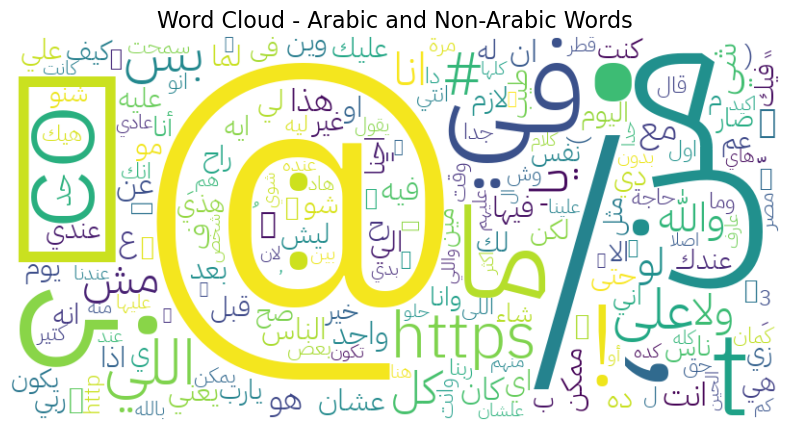

In [42]:
word_counts = Counter(tokens)
most_common_words = word_counts.most_common(40000)
print(most_common_words)

reshaped_words = {}
for word, count in most_common_words:
    if re.match(r'^[ء-ي]+$', word):  # If the word is Arabic
        reshaped_words[get_display(arabic_reshaper.reshape(word))] = count
    else:  # If the word is non-Arabic
        reshaped_words[word] = count

wordcloud = WordCloud(
    font_path='IBMPlexSansArabic-Light.ttf',
    width=800,
    height=400,
    background_color="white"
).generate_from_frequencies(reshaped_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Arabic and Non-Arabic Words", fontsize=16)
plt.show()


 و نلاحظ وجود علامات ترقيم غير مفيدة و احرف انكليزية لا معنى لها و ايموجيز (stop words حتى,ان,انا والكثير من الكلمات التي تعتبر )نلاحظ وجود كلمات مكررة لا تنتمي للهجة محددة مثل

## [2.4]

1.هذا الكود يبحث في النص الأطول بين مجموعة النصوص ويحدد الكلمات الأكثر تكرارا حسب دخل المستخدم  مع عدد مرات ظهورها و تم اختيار اطول نص للتأكد من مرور كلمات مكررة

In [43]:
def most_frequent_words(tokens, n=1):

    words = [token for token in tokens if re.match(r'\b\w+\b', token)]
    word_counts = Counter(words)
    most_common_words = word_counts.most_common(n) #tuple -> word:freq
    return most_common_words

longest_text = train.loc[train['tokens'].str.len().idxmax(), 'tokens']
long = " ".join(longest_text)

# Input for the number of words
n = int(input("Enter the number of most frequent words you want to display: "))

# Get the most frequent words
most_common_words = most_frequent_words(longest_text, n)

# Display results
print("Longest text:", long)
print("\nMost frequent words:")
print(" ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))


Longest text: يا اجمل عنابي وربي انا اشهد انك ترفع الراس 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ https : / / t . co / SVeGO3cCVv

Most frequent words:
1. يا (1) 2. اجمل (1)


2.هذا الكود يبحث في النص الأطول بين مجموعة النصوص ويحدد الكلمات الاقل تكرارا حسب دخل المستخدم  مع عدد مرات ظهورها

In [44]:
def least_frequent_words(tokens, n):
    words = [token for token in tokens if re.match(r'\b\w+\b', token)]
    word_counts = Counter(words)
    least_common_words = [word for word, count in word_counts.items() if count == 1]
    return least_common_words[:n]

longest_text = train.loc[train['tokens'].str.len().idxmax(), 'tokens']
long = " ".join(longest_text)

n = int(input("Enter the number of least frequent words you want to display: "))

least_common_words = least_frequent_words(longest_text, n)

print("Longest text:", long)
print("\nLeast frequent words:")
print(" ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))


Longest text: يا اجمل عنابي وربي انا اشهد انك ترفع الراس 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ 🇶 🇦 ♥ ️ https : / / t . co / SVeGO3cCVv

Least frequent words:
1. يا 2. اجمل


اكثر ثنائيات كلمات مكررة في النص

In [45]:
def most_frequent_bigrams(tokens, n):
    words = [token for token in tokens if re.match(r'\b\w+\b', token)]
    bigram_list = list(bigrams(words))
    bigram_counts = Counter(bigram_list)
    most_common_bigrams = bigram_counts.most_common(n)
    return most_common_bigrams

random_index = random.randint(0, len(train) - 1)
random_tokens = train.loc[random_index, 'tokens']
random_text = " ".join(random_tokens)

n = int(input("Enter the number of most frequent bigrams you want to display: "))

most_common_bigrams = most_frequent_bigrams(random_tokens, n)

print("Random text:", random_text)
print("\nMost frequent bigrams:")
print(", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))


Random text: شلون اقدر اروح مركز إيه بي سي ؟

Most frequent bigrams:
1. ('شلون', 'اقدر') (1), 2. ('اقدر', 'اروح') (1)


اكثر ثلاثيات كلمات مكررة في النص

In [46]:
def most_frequent_trigrams(tokens, n):
    words = [token for token in tokens if re.match(r'\b\w+\b', token)]
    trigram_list = list(trigrams(words))
    trigram_counts = Counter(trigram_list)
    most_common_trigrams = trigram_counts.most_common(n)
    return most_common_trigrams

random_index = random.randint(0, len(train) - 1)
random_tokens = train.loc[random_index, 'tokens']
random_text = " ".join(random_tokens)

n = int(input("Enter the number of most frequent trigrams you want to display: "))

most_common_trigrams = most_frequent_trigrams(random_tokens, n)

print("Random text:", random_text)
print("\nMost frequent trigrams:")
print(", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})"
                 for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))


Random text: - ف َ تعل ُ ق ُ الفاني ب ِ الفاني ي ُ فنيه ، وتعل ُ ق ُ الفاني ب ِ الباقي ي ُ بقيه ️ 🌏 . 💜 💙 💛

Most frequent trigrams:
1. ('ق', 'الفاني', 'ب') (2), 2. ('ف', 'تعل', 'ق') (1)


لنحصل على الكلمات المهمة فقط stop words  اكثر ثنائيات مهمة في النص هنا نقوم بازالة ال

In [47]:
# nltk.download('stopwords')
stop_words = set(stopwords.words('arabic'))

def significant_bigrams(text, n):

    words = re.findall(r'\b\w+\b', text)

    significant_words = [word for word in words if word not in stop_words]

    bigram_list = list(bigrams(significant_words))

    bigram_counts = Counter(bigram_list)

    most_common_bigrams = bigram_counts.most_common(n)
    return most_common_bigrams

random_index = random.randint(0, len(train) - 1)
random_text = train.loc[random_index, 'text']

n = int(input("Enter the number of most frequent significant bigrams you want to display: "))

most_common_significant_bigrams = significant_bigrams(random_text, n)

print("Random text:", random_text)
print("\nMost frequent significant bigrams:")
for i, ((word1, word2), frequency) in enumerate(most_common_significant_bigrams, start=1):
    print(f"{i}. Bigram: ('{word1}', '{word2}'), Frequency: {frequency}")


Random text: ليش صاغ هشكل؟

Most frequent significant bigrams:
1. Bigram: ('ليش', 'صاغ'), Frequency: 1
2. Bigram: ('صاغ', 'هشكل'), Frequency: 1


لنحصل على الكلمات المهمة فقط stop words  اكثر ثلاثيات مهمة في النص هنا نقوم بازالة ال

In [48]:
stop_words = set(stopwords.words('arabic'))

def significant_trigrams(text, n=1):

    words = re.findall(r'\b\w+\b', text)

    significant_words = [word for word in words if word not in stop_words]

    trigram_list = list(trigrams(significant_words))

    trigram_counts = Counter(trigram_list)

    most_common_trigrams = trigram_counts.most_common(n)
    return most_common_trigrams

random_index = random.randint(0, len(train) - 1)
random_text = train.loc[random_index, 'text']

n = int(input("Enter the number of most frequent significant trigrams you want to display: "))

most_common_significant_trigrams = significant_trigrams(random_text, n)

print("Random text:", random_text)
print("\nMost frequent significant trigrams:")
for i, ((word1, word2, word3), frequency) in enumerate(most_common_significant_trigrams, start=1):
    print(f"{i}. Trigram: ('{word1}', '{word2}', '{word3}'), Frequency: {frequency}")


Random text: اللي وايد منهارين ومصورين صفحتى بالقبس انها انحجبت وكاتبين ما يصح الا الصحيح وايد تكسرون الخاطر الصراحه .. ما عليه نطروا تفاصيل التفاصيل

Most frequent significant trigrams:
1. Trigram: ('اللي', 'وايد', 'منهارين'), Frequency: 1
2. Trigram: ('وايد', 'منهارين', 'ومصورين'), Frequency: 1


لاستخراج الكلمات الأكثر أهمية ثم تنشئ الثنائيات وتعد تكرار كل ثنائي ثم تعيد الثنائيات الأكثر تكرارا وفقا للعدد المحدد TF-IDF هذه الدالة تقوم بتحليل قائمة من النصوص تستخدم

In [ ]:
def extract_significant_bigrams(tokens_list, n, max_features=2000):

    texts = [" ".join(tokens) for tokens in tokens_list]

    vectorizer = TfidfVectorizer(max_features=max_features, token_pattern=r'\b\w+\b')
    tfidf_matrix = vectorizer.fit_transform(texts)
    significant_words = vectorizer.get_feature_names_out()

    bigram_list = []
    for tokens in tokens_list:
        filtered_tokens = [token for token in tokens if token in significant_words]
        bigram_list.extend(bigrams(filtered_tokens))

    bigram_counts = Counter(bigram_list)

    return bigram_counts.most_common(n)


لاستخراج الكلمات الأكثر أهمية ثم تنشئ الثلاثيات وتعد تكرار كل ثنائي ثم تعيد الثلاثيات الأكثر تكرارا وفقا للعدد المحدد TF-IDF هذه الدالة تقوم بتحليل قائمة من النصوص تستخدم

In [ ]:
def extract_significant_trigrams(tokens_list, n, max_features=2000):

    texts = [" ".join(tokens) for tokens in tokens_list]

    vectorizer = TfidfVectorizer(max_features=max_features, token_pattern=r'\b\w+\b')
    tfidf_matrix = vectorizer.fit_transform(texts)
    significant_words = vectorizer.get_feature_names_out()

    trigram_list = []
    for tokens in tokens_list:
        filtered_tokens = [token for token in tokens if token in significant_words]
        trigram_list.extend(trigrams(filtered_tokens))

    trigram_counts = Counter(trigram_list)

    return trigram_counts.most_common(n)


In [ ]:
# print(type(train['region']))
train.head()

,id,split,city,text,region,country,tokens,cleaned_text
0,5,train,ALE,هو هنيك، قدام معلومات السياح بالضبط.,Levant,Syria,"[هو, هنيك, ،, قدام, معلومات, السياح, بالضبط, .]",هنيك ، قدام معلومات السياح بالضبط .
1,9,train,ALE,مالي سمعان من قبل بهالعنوان هون.,Levant,Syria,"[مالي, سمعان, من, قبل, بهالعنوان, هون, .]",مالي سمعان بهالعنوان هون .
2,11,train,ALE,روح ساوي لبين ما تشوف صيدلية.,Levant,Syria,"[روح, ساوي, لبين, ما, تشوف, صيدلية, .]",روح ساوي لبين تشوف صيدلية .
3,26,train,ALE,بشقد الفطور؟,Levant,Syria,"[بشقد, الفطور, ؟]",بشقد الفطور ؟
4,27,train,ALE,شلون بقدر أساعدك؟,Levant,Syria,"[شلون, بقدر, أساعدك, ؟]",شلون بقدر أساعدك ؟


تحليل الداتا بناء على المنطقة

Maghreb

In [ ]:
maghreb_tokens = train[train['region'] == 'Maghreb']['tokens']
maghreb_texts = [token for tokens_list in maghreb_tokens for token in tokens_list if len(token.strip()) > 0]

# الكلمات الأكثر شيوعًا
most_common_words = most_frequent_words(maghreb_texts, 10)
print("Most frequent words in Maghreb region:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

# الكلمات الأقل شيوعًا
least_common_words = least_frequent_words(maghreb_texts, 10)
print("Least frequent words in Maghreb region:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

# ثنائيات الكلمات الأكثر شيوعًا
most_common_bigrams = most_frequent_bigrams(maghreb_texts, 10)
print("Most frequent bigrams in Maghreb region:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

# ثلاثيات الكلمات الأكثر شيوعًا
most_common_trigrams = most_frequent_trigrams(maghreb_texts, 10)
print("Most frequent trigrams in Maghreb region:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(maghreb_tokens, 10)
print("Most frequent significant bigrams in Maghreb region:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(maghreb_tokens, 10)
print("Most frequent significant trigrams in Maghreb region:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Most frequent words in Maghreb region: 1. في (18877), 2. و (16615), 3. من (16034), 4. t (10003), 5. co (9993), 6. https (9300), 7. اللي (8681), 8. ما (8621), 9. على (7745), 10. الله (7635)
Least frequent words in Maghreb region: 1. تاوعي, 2. فالشاك, 3. للبرية, 4. تزيدلها, 5. تبعثها, 6. عراض, 7. الأنتيم, 8. الكابو, 9. فالكولواغ, 10. بيوفر
Most frequent bigrams in Maghreb region: 1. ('t', 'co') (9993), 2. ('https', 't') (9300), 3. ('شاء', 'الله') (1441), 4. ('ان', 'شاء') (975), 5. ('http', 't') (692), 6. ('الله', 'يبارك') (407), 7. ('كل', 'شي') (358), 8. ('من', 'فضلك') (356), 9. ('و', 'لا') (316), 10. ('من', 'غير') (312)
Most frequent trigrams in Maghreb region: 1. ('https', 't', 'co') (9300), 2. ('ان', 'شاء', 'الله') (944), 3. ('http', 't', 'co') (692), 4. ('الله', 'يبارك', 'فيك') (248), 5. ('إن', 'شاء', 'الله') (192), 6. ('الله', 'ونعم', 'الوكيل') (160), 7. ('t', 'co', '8') (159), 8. ('t', 'co', '0') (152), 9. ('t', 'co', '4') (149), 10. ('t', 'co', '7') (146)
Most frequent significant

Nile_Basin

In [ ]:
Nile_Basin_tokens = train[train['region'] == 'Nile_Basin']['tokens']
Nile_Basin_texts =[token for tokens_list in Nile_Basin_tokens for token in tokens_list if len(token.strip()) > 0]
#الكلمات الأكثر شيوعًا
most_common_words = most_frequent_words(Nile_Basin_texts, 10)
print("Most frequent words in Nile_Basin region:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))
#الكلمات الأقل شيوعًا
least_common_words = least_frequent_words(Nile_Basin_texts, 10)
print("Least frequent words in Nile_Basin region:" ,", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))
#ثنائيات الكلمات الأكثر شيوعًا
most_common_bigrams = most_frequent_bigrams(Nile_Basin_texts, 10)
print("Most frequent bigrams in Nile_Basin region:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))
#ثلاثيات الكلمات الأكثر شيوعًا
most_common_trigrams = most_frequent_trigrams(Nile_Basin_texts, 10)
print("Most frequent trigrams in Nile_Basin region:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Nile_Basin_tokens, 10)
print("Most frequent significant bigrams in Nile_Basin region:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Nile_Basin_tokens, 10)
print("Most frequent significant trigrams in Nile_Basin region:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Nile_Basin region: 1. من (16533), 2. في (15520), 3. t (13213), 4. co (13194), 5. https (12821), 6. مش (11334), 7. ده (10786), 8. اللي (10100), 9. و (10093), 10. يا (9988)
Least frequent words in Nile_Basin region: 1. ثمانين, 2. للإيميل, 3. هتسخنه, 4. عاوزنى, 5. بيساعدنى, 6. اكستنشن, 7. همبرجر, 8. واتانابى, 9. سروورنا, 10. أخطبوط
Most frequent bigrams in Nile_Basin region: 1. ('t', 'co') (13194), 2. ('https', 't') (12821), 3. ('لو', 'سمحت') (999), 4. ('من', 'فضلك') (977), 5. ('شاء', 'الله') (733), 6. ('من', 'غير') (574), 7. ('ان', 'شاء') (492), 8. ('مش', 'عارف') (447), 9. ('اكتر', 'من') (432), 10. ('انا', 'مش') (413)
Most frequent trigrams in Nile_Basin region: 1. ('https', 't', 'co') (12821), 2. ('ان', 'شاء', 'الله') (485), 3. ('http', 't', 'co') (365), 4. ('t', 'co', '4') (199), 5. ('t', 'co', '1') (197), 6. ('t', 'co', '7') (190), 7. ('t', 'co', '2') (185), 8. ('t', 'co', '6') (181), 9. ('t', 'co', '5') (180), 10. ('t', 'co', '9') (178)
Most frequent significan

Levant

In [ ]:
Levant_tokens = train[train['region'] == 'Levant']['tokens']
Levant_texts = [token for tokens_list in Levant_tokens for token in tokens_list if len(token.strip()) > 0]
#الكلمات الأكثر شيوعًا
most_common_words = most_frequent_words(Levant_texts, 10)
print("Most frequent words in Levant region:", ", ".join([f"{i}. ({word}) ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))
#الكلمات الأقل شيوعًا
least_common_words = least_frequent_words(Levant_texts, 10)
print("Least frequent words in Levant region:" ,", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))
#ثنائيات الكلمات الأكثر شيوعًا
most_common_bigrams = most_frequent_bigrams(Levant_texts, 10)
print("Most frequent bigrams in Levant region:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))
#ثلاثيات الكلمات الأكثر شيوعًا
most_common_trigrams = most_frequent_trigrams(Levant_texts, 10)
print("Most frequent trigrams in Levant region:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Levant_tokens, 10)
print("Most frequent significant bigrams in Levant region:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Levant_tokens, 10)
print("Most frequent significant trigrams in Levant region:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Most frequent words in Levant region: 1. (ما) (26034), 2. (من) (22296), 3. (t) (16159), 4. (co) (16144), 5. (بس) (15771), 6. (و) (15245), 7. (https) (14537), 8. (يا) (12747), 9. (في) (12251), 10. (مش) (11658)
Least frequent words in Levant region: 1. المفرد, 2. أتساعد, 3. هبمرغر, 4. عالعملية, 5. وحبار, 6. الجواني, 7. للمانطو, 8. إدينبيره, 9. ودائع, 10. هالكفوف
Most frequent bigrams in Levant region: 1. ('t', 'co') (16144), 2. ('https', 't') (14537), 3. ('http', 't') (1607), 4. ('يا', 'رب') (1260), 5. ('شاء', 'الله') (1109), 6. ('ما', 'في') (1002), 7. ('لو', 'سمحت') (868), 8. ('كل', 'شي') (723), 9. ('في', 'ناس') (700), 10. ('بس', 'ما') (659)
Most frequent trigrams in Levant region: 1. ('https', 't', 'co') (14537), 2. ('http', 't', 'co') (1607), 3. ('ان', 'شاء', 'الله') (611), 4. ('ما', 'شاء', 'الله') (251), 5. ('t', 'co', '0') (238), 6. ('t', 'co', '2') (232), 7. ('t', 'co', '3') (218), 8. ('t', 'co', '9') (218), 9. ('t', 'co', '6') (210), 10. ('t', 'co', '5') (204)
Most frequent signif

Iraqi

In [ ]:
Iraqi_tokens = train[train['region'] == 'Iraqi']['tokens']
Iraqi_texts = [token for tokens_list in Iraqi_tokens for token in tokens_list if len(token.strip()) > 0]
#الكلمات الأكثر شيوعًا
most_common_words = most_frequent_words(Iraqi_texts, 10)
print("Most frequent words in Iraqi region:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))
#الكلمات الأقل شيوعًا
least_common_words = least_frequent_words(Iraqi_texts, 10)
print("Least frequent words in Iraqi region:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))
#ثنائيات الكلمات الأكثر شيوعًا
most_common_bigrams = most_frequent_bigrams(Iraqi_texts, 10)
print("Most frequent bigrams in Iraqi region:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))
#ثلاثيات الكلمات الأكثر شيوعًا
most_common_trigrams = most_frequent_trigrams(Iraqi_texts, 10)
print("Most frequent trigrams in Iraqi region:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Iraqi_tokens, 10)
print("Most frequent significant bigrams in Iraqi region:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Iraqi_tokens, 10)
print("Most frequent significant trigrams in Iraqi region:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Most frequent words in Iraqi region: 1. من (3456), 2. t (2467), 3. co (2464), 4. ما (2242), 5. https (2197), 6. بس (2123), 7. على (1778), 8. مو (1675), 9. اللي (1427), 10. هذا (1223)
Least frequent words in Iraqi region: 1. الصيدلية, 2. اخليلك, 3. بالكهوة, 4. وتلث, 5. للتسليم, 6. ببوز, 7. عريض, 8. بسريرين, 9. كشي, 10. المصادف
Most frequent bigrams in Iraqi region: 1. ('t', 'co') (2464), 2. ('https', 't') (2197), 3. ('http', 't') (265), 4. ('شاء', 'الله') (159), 5. ('I', 'added') (150), 6. ('added', 'a') (150), 7. ('a', 'video') (150), 8. ('video', 'to') (150), 9. ('to', 'a') (150), 10. ('a', 'YouTube') (150)
Most frequent trigrams in Iraqi region: 1. ('https', 't', 'co') (2197), 2. ('http', 't', 'co') (265), 3. ('I', 'added', 'a') (150), 4. ('added', 'a', 'video') (150), 5. ('a', 'video', 'to') (150), 6. ('video', 'to', 'a') (150), 7. ('to', 'a', 'YouTube') (150), 8. ('a', 'YouTube', 'playlist') (150), 9. ('YouTube', 'playlist', 'https') (150), 10. ('playlist', 'https', 't') (150)
Most

Gulf

In [ ]:
Gulf_tokens = train[train['region'] == 'Gulf']['tokens']
Gulf_texts = [token for tokens_list in Gulf_tokens for token in tokens_list if len(token.strip()) > 0]
#الكلمات الأكثر شيوعًا
most_common_words = most_frequent_words(Gulf_texts, 10)
print("Most frequent words in Gulf region:" ,", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))
#الكلمات الأقل شيوعًا
least_common_words = least_frequent_words(Gulf_texts, 10)
print("Least frequent words in Gulf region:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))
#ثنائيات الكلمات الأكثر شيوعًا
most_common_bigrams = most_frequent_bigrams(Gulf_texts, 10)
print("Most frequent bigrams in Gulf region:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))
#ثلاثيات الكلمات الأكثر شيوعًا
most_common_trigrams = most_frequent_trigrams(Gulf_texts, 10)
print("Most frequent trigrams in Gulf region:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Gulf_tokens, 10)
print("Most frequent significant bigrams in Gulf region:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Gulf_tokens, 10)
print("Most frequent significant trigrams in Gulf region:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Gulf region: 1. من (42053), 2. ما (28694), 3. في (28032), 4. اللي (27158), 5. t (22947), 6. co (22926), 7. الله (22838), 8. و (22536), 9. https (21325), 10. على (20821)
Least frequent words in Gulf region: 1. بهالعنوان, 2. أبغيه, 3. ستونر, 4. متعورة, 5. للمؤتمرات, 6. كاتس, 7. فانلة, 8. أرز, 9. هاجمني, 10. هالبركة
Most frequent bigrams in Gulf region: 1. ('t', 'co') (22926), 2. ('https', 't') (21324), 3. ('لو', 'سمحت') (1917), 4. ('شاء', 'الله') (1889), 5. ('http', 't') (1600), 6. ('كل', 'شي') (1302), 7. ('ان', 'شاء') (1072), 8. ('حسبي', 'الله') (792), 9. ('اكثر', 'من') (751), 10. ('الله', 'يبارك') (746)
Most frequent trigrams in Gulf region: 1. ('https', 't', 'co') (21324), 2. ('http', 't', 'co') (1600), 3. ('ان', 'شاء', 'الله') (1050), 4. ('ما', 'شاء', 'الله') (445), 5. ('الله', 'ونعم', 'الوكيل') (402), 6. ('الله', 'يبارك', 'فيك') (395), 7. ('t', 'co', '8') (326), 8. ('t', 'co', '2') (323), 9. ('t', 'co', '0') (321), 10. ('t', 'co', '5') (319)
Most frequent sign

Yemen

In [ ]:
Yemen_tokens = train[train['region'] == 'Yemen']['tokens']
Yemen_texts = [token for tokens_list in Yemen_tokens for token in tokens_list if len(token.strip()) > 0]
#الكلمات الأكثر شيوعًا
most_common_words = most_frequent_words(Yemen_texts, 10)
print("Most frequent words in Yemen region:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

#الكلمات الأقل شيوعًا
least_common_words = least_frequent_words(Yemen_texts, 10)
print("Least frequent words in Yemen region:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

#ثنائيات الكلمات الأكثر شيوعًا
most_common_bigrams = most_frequent_bigrams(Yemen_texts, 10)
print("Most frequent bigrams in Yemen region:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

#ثلاثيات الكلمات الأكثر شيوعًا
most_common_trigrams = most_frequent_trigrams(Yemen_texts, 10)
print("Most frequent trigrams in Yemen region:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Yemen_tokens, 10)
print("Most frequent significant bigrams in Yemen region:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Yemen_tokens, 10)
print("Most frequent significant trigrams in Yemen region:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Yemen region: 1. من (2255), 2. t (1540), 3. co (1540), 4. https (1324), 5. في (1248), 6. اللي (1090), 7. ما (1049), 8. على (1018), 9. الله (996), 10. و (761)
Least frequent words in Yemen region: 1. هوذاك, 2. سمعتش, 3. أطفالي, 4. للبريد, 5. للتوصيل, 6. اواجه, 7. واسعه, 8. تجعيد, 9. تبرز, 10. يثيت
Most frequent bigrams in Yemen region: 1. ('t', 'co') (1540), 2. ('https', 't') (1324), 3. ('http', 't') (215), 4. ('لو', 'سمحت') (157), 5. ('ھ', 'ھ') (115), 6. ('شاء', 'الله') (95), 7. ('تقنية', 'اخبار') (81), 8. ('اخبار', 'Tech') (81), 9. ('Tech', 'اقلام_تك') (81), 10. ('كل', 'شي') (66)
Most frequent trigrams in Yemen region: 1. ('https', 't', 'co') (1324), 2. ('http', 't', 'co') (215), 3. ('ھ', 'ھ', 'ھ') (86), 4. ('تقنية', 'اخبار', 'Tech') (81), 5. ('اخبار', 'Tech', 'اقلام_تك') (81), 6. ('ان', 'شاء', 'الله') (58), 7. ('جواس', 'جواس', 'جواس') (31), 8. ('t', 'co', '6') (30), 9. ('قادر', 'قادر', 'قادر') (29), 10. ('t', 'co', '7') (27)
Most frequent significant bigrams in

تحليل الداتا بناء على الدولة

Morocco

In [ ]:
Morocco_tokens = train[train['country'] == 'Morocco']['tokens']
Morocco_texts = [token for tokens_list in Morocco_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Morocco_texts, 10)
print("Most frequent words in Morocco country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Morocco_texts, 10)
print("Least frequent words in Morocco country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Morocco_texts, 10)
print("Most frequent bigrams in Morocco country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Morocco_texts, 10)
print("Most frequent trigrams in Morocco country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Morocco_tokens, 10)
print("Most frequent significant bigrams in Morocco country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Morocco_tokens, 10)
print("Most frequent significant trigrams in Morocco country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Morocco country: 1. من (2909), 2. و (2883), 3. واش (2208), 4. شي (2202), 5. على (2104), 6. لي (1703), 7. ديال (1678), 8. هاد (1614), 9. في (1591), 10. t (1571)
Least frequent words in Morocco country: 1. ماسبقليش, 2. سيرعلى, 3. مئتي, 4. خصه, 5. برمانونت, 6. اثبات, 7. بصديقي, 8. كتهدف, 9. لتعزيز, 10. الغطى
Most frequent bigrams in Morocco country: 1. ('t', 'co') (1570), 2. ('https', 't') (1445), 3. ('واش', 'عندك') (228), 4. ('واش', 'يمكن') (227), 5. ('كاين', 'شي') (217), 6. ('شي', 'حاجة') (215), 7. ('يمكن', 'لي') (205), 8. ('يمكن', 'ليك') (175), 9. ('شاء', 'الله') (170), 10. ('من', 'بعد') (161)
Most frequent trigrams in Morocco country: 1. ('https', 't', 'co') (1445), 2. ('واش', 'كاين', 'شي') (130), 3. ('http', 't', 'co') (124), 4. ('ان', 'شاء', 'الله') (117), 5. ('واش', 'يمكن', 'لي') (103), 6. ('واش', 'عندك', 'شي') (101), 7. ('elmarocain', 'https', 't') (87), 8. ('واش', 'يمكن', 'ليك') (76), 9. ('تفو', 'تفو', 'تفو') (60), 10. ('يمكن', 'لي', 'نحصل') (38)
Most frequ

Algeria

In [ ]:
Algeria_tokens = train[train['country'] == 'Algeria']['tokens']
Algeria_texts = [token for tokens_list in Algeria_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Algeria_texts, 10)
print("Most frequent words in Algeria country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Algeria_texts, 10)
print("Least frequent words in Algeria country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Algeria_texts, 10)
print("Most frequent bigrams in Algeria country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Algeria_texts, 10)
print("Most frequent trigrams in Algeria country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Algeria_tokens, 10)
print("Most frequent significant bigrams in Algeria country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Algeria_tokens, 10)
print("Most frequent significant trigrams in Algeria country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Algeria country: 1. و (3574), 2. من (2836), 3. في (2797), 4. الله (1970), 5. ما (1800), 6. على (1614), 7. يا (1412), 8. انا (1384), 9. t (1365), 10. co (1362)
Least frequent words in Algeria country: 1. الجيهة, 2. صيدلية, 3. الميتين, 4. تاوعي, 5. راهوم, 6. فالشاك, 7. عيطلي, 8. للبرية, 9. تزيدلها, 10. تبعثها
Most frequent bigrams in Algeria country: 1. ('t', 'co') (1362), 2. ('https', 't') (1354), 3. ('شاء', 'الله') (481), 4. ('ان', 'شاء') (362), 5. ('غازي', 'المطيري') (294), 6. ('من', 'فضلك') (184), 7. ('الله', 'يبارك') (141), 8. ('ربي', 'يحفظك') (138), 9. ('راني', 'حاب') (126), 10. ('الحمد', 'لله') (118)
Most frequent trigrams in Algeria country: 1. ('https', 't', 'co') (1354), 2. ('ان', 'شاء', 'الله') (357), 3. ('ما', 'شاء', 'الله') (45), 4. ('يا', 'رب', 'يا') (42), 5. ('رب', 'يا', 'رب') (40), 6. ('إن', 'شاء', 'الله') (33), 7. ('الله', 'ونعم', 'الوكيل') (30), 8. ('أن', 'شاء', 'الله') (26), 9. ('t', 'co', '0') (26), 10. ('الله', 'يبارك', 'فيك') (25)
Most frequen

Tunisia

In [ ]:
Tunisia_tokens = train[train['country'] == 'Tunisia']['tokens']
Tunisia_texts = [token for tokens_list in Tunisia_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Tunisia_texts, 10)
print("Most frequent words in Tunisia country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Tunisia_texts, 10)
print("Least frequent words in Tunisia country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Tunisia_texts, 10)
print("Most frequent bigrams in Tunisia country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Tunisia_texts, 10)
print("Most frequent trigrams in Tunisia country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Tunisia_tokens, 10)
print("Most frequent significant bigrams in Tunisia country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Tunisia_tokens, 10)
print("Most frequent significant trigrams in Tunisia country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Tunisia country: 1. و (4398), 2. في (4361), 3. من (2424), 4. ما (2062), 5. على (1946), 6. t (1754), 7. co (1752), 8. https (1566), 9. يا (1346), 10. يعيشك (1328)
Least frequent words in Tunisia country: 1. الإرشادات, 2. تارى, 3. الفارمسي, 4. للأولاد, 5. لاستخدام, 6. كيرلي, 7. تسخنه, 8. أوكتوبر, 9. الفليزة, 10. نتلها
Most frequent bigrams in Tunisia country: 1. ('t', 'co') (1752), 2. ('https', 't') (1566), 3. ('شاء', 'الله') (190), 4. ('http', 't') (186), 5. ('ان', 'شاء') (147), 6. ('في', 'تونس') (144), 7. ('نجم', 'ناخو') (133), 8. ('من', 'هوني') (105), 9. ('و', 'ما') (99), 10. ('من', 'غير') (96)
Most frequent trigrams in Tunisia country: 1. ('https', 't', 'co') (1566), 2. ('http', 't', 'co') (186), 3. ('ان', 'شاء', 'الله') (136), 4. ('الله', 'يبارك', 'فيك') (46), 5. ('t', 'co', '4') (32), 6. ('t', 'co', '8') (29), 7. ('MaguyBouGhosn', 'https', 't') (29), 8. ('t', 'co', '0') (26), 9. ('t', 'co', '5') (25), 10. ('إن', 'شاء', 'الله') (24)
Most frequent significant b

Libya

In [ ]:
Libya_tokens = train[train['country'] == 'Libya']['tokens']
Libya_texts =[token for tokens_list in Libya_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Libya_texts, 10)
print("Most frequent words in Libya country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Libya_texts, 10)
print("Least frequent words in Libya country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Libya_texts, 10)
print("Most frequent bigrams in Libya country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Libya_texts, 10)
print("Most frequent trigrams in Libya country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Libya_tokens, 10)
print("Most frequent significant bigrams in Libya country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Libya_tokens, 10)
print("Most frequent significant trigrams in Libya country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Libya country: 1. في (10128), 2. من (7865), 3. و (5760), 4. اللي (5691), 5. t (5313), 6. co (5309), 7. https (4935), 8. مش (3986), 9. ما (3606), 10. الله (3256)
Least frequent words in Libya country: 1. بالعنوان, 2. للشوكة, 3. مزدوجة, 4. لاستعمال, 5. بدالها, 6. مشدود, 7. حنضطر, 8. والرياضة, 9. لوجبته, 10. لشخصين
Most frequent bigrams in Libya country: 1. ('t', 'co') (5309), 2. ('https', 't') (4935), 3. ('شاء', 'الله') (599), 4. ('http', 't') (374), 5. ('ان', 'شاء') (347), 6. ('لو', 'سمحت') (275), 7. ('في', 'ليبيا') (256), 8. ('مش', 'عارف') (228), 9. ('كل', 'شي') (211), 10. ('اللي', 'في') (204)
Most frequent trigrams in Libya country: 1. ('https', 't', 'co') (4935), 2. ('http', 't', 'co') (374), 3. ('ان', 'شاء', 'الله') (333), 4. ('الله', 'يبارك', 'فيك') (151), 5. ('الله', 'ونعم', 'الوكيل') (112), 6. ('إن', 'شاء', 'الله') (101), 7. ('t', 'co', '1') (84), 8. ('t', 'co', '8') (83), 9. ('t', 'co', '6') (82), 10. ('t', 'co', '4') (81)
Most frequent significant bigrams

Egypt

In [ ]:
Egypt_tokens = train[train['country'] == 'Egypt']['tokens']
Egypt_texts =[token for tokens_list in Egypt_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Egypt_texts, 10)
print("Most frequent words in Egypt country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Egypt_texts, 10)
print("Least frequent words in Egypt country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Egypt_texts, 10)
print("Most frequent bigrams in Egypt country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Egypt_texts, 10)
print("Most frequent trigrams in Egypt country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Egypt_tokens, 10)
print("Most frequent significant bigrams in Egypt country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Egypt_tokens, 10)
print("Most frequent significant trigrams in Egypt country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Egypt country: 1. من (13462), 2. في (11365), 3. مش (11101), 4. t (10465), 5. co (10451), 6. https (10160), 7. اللي (9691), 8. ده (9587), 9. و (8571), 10. يا (8431)
Least frequent words in Egypt country: 1. تبديلات, 2. منزوع, 3. ستونر, 4. تشتريته, 5. حأبلغها, 6. تكلمك, 7. متعورة, 8. للمؤتمرات, 9. لفرنسا, 10. حفلى
Most frequent bigrams in Egypt country: 1. ('t', 'co') (10451), 2. ('https', 't') (10160), 3. ('لو', 'سمحت') (990), 4. ('من', 'فضلك') (763), 5. ('شاء', 'الله') (572), 6. ('من', 'غير') (515), 7. ('مش', 'عارف') (440), 8. ('انا', 'مش') (409), 9. ('ولا', 'ايه') (398), 10. ('ان', 'شاء') (396)
Most frequent trigrams in Egypt country: 1. ('https', 't', 'co') (10160), 2. ('ان', 'شاء', 'الله') (391), 3. ('http', 't', 'co') (284), 4. ('t', 'co', '1') (162), 5. ('t', 'co', '4') (155), 6. ('t', 'co', '7') (149), 7. ('t', 'co', '6') (148), 8. ('t', 'co', '9') (140), 9. ('t', 'co', '8') (140), 10. ('t', 'co', '2') (136)
Most frequent significant bigrams in Egypt countr

Sudan

In [ ]:
Sudan_tokens = train[train['country'] == 'Sudan']['tokens']
Sudan_texts = [token for tokens_list in Sudan_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Sudan_texts, 10)
print("Most frequent words in Sudan country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Sudan_texts, 10)
print("Least frequent words in Sudan country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Sudan_texts, 10)
print("Most frequent bigrams in Sudan country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Sudan_texts, 10)
print("Most frequent trigrams in Sudan country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Sudan_tokens, 10)
print("Most frequent significant bigrams in Sudan country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Sudan_tokens, 10)
print("Most frequent significant trigrams in Sudan country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Sudan country: 1. في (4155), 2. ما (3611), 3. من (3071), 4. t (2748), 5. co (2743), 6. https (2661), 7. دي (2348), 8. دا (1767), 9. يا (1557), 10. و (1522)
Least frequent words in Sudan country: 1. بالعنوان, 2. شيكي, 3. يكلف, 4. وتمنين, 5. للبريد, 6. للتسليم, 7. أواجه, 8. عريضة, 9. اصابع, 10. لاستعمال
Most frequent bigrams in Sudan country: 1. ('t', 'co') (2743), 2. ('https', 't') (2661), 3. ('من', 'فضلك') (214), 4. ('شاء', 'الله') (161), 5. ('ولا', 'شنو') (127), 6. ('دي', 'ما') (107), 7. ('اكتر', 'من') (99), 8. ('ان', 'شاء') (96), 9. ('في', 'ناس') (91), 10. ('الناس', 'دي') (89)
Most frequent trigrams in Sudan country: 1. ('https', 't', 'co') (2661), 2. ('ان', 'شاء', 'الله') (94), 3. ('http', 't', 'co') (81), 4. ('t', 'co', '2') (49), 5. ('شنو', 'https', 't') (46), 6. ('t', 'co', '5') (46), 7. ('t', 'co', '4') (44), 8. ('t', 'co', '7') (41), 9. ('t', 'co', '9') (38), 10. ('بس', 'https', 't') (36)
Most frequent significant bigrams in Sudan country: ('t', 'co'), ('

Palestine

In [ ]:
Palestine_tokens = train[train['country'] == 'Palestine']['tokens']
Palestine_texts =[token for tokens_list in Palestine_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Palestine_texts, 10)
print("Most frequent words in Palestine country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Palestine_texts, 10)
print("Least frequent words in Palestine country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Palestine_texts, 10)
print("Most frequent bigrams in Palestine country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Palestine_texts, 10)
print("Most frequent trigrams in Palestine country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Palestine_tokens, 10)
print("Most frequent significant bigrams in Palestine country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Palestine_tokens, 10)
print("Most frequent significant trigrams in Palestine country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Palestine country: 1. ما (7659), 2. من (7438), 3. t (5995), 4. co (5991), 5. https (5737), 6. مش (5518), 7. بس (5493), 8. في (5085), 9. يا (4792), 10. اللي (4326)
Least frequent words in Palestine country: 1. استعلامات, 2. لتلاقي, 3. الكورنر, 4. تصرفلي, 5. الميتين, 6. للبريد, 7. للتوصيل, 8. صعوبات, 9. لاستعمال, 10. الصوص
Most frequent bigrams in Palestine country: 1. ('t', 'co') (5991), 2. ('https', 't') (5737), 3. ('يا', 'رب') (624), 4. ('شاء', 'الله') (542), 5. ('مش', 'عارف') (308), 6. ('في', 'ناس') (280), 7. ('ان', 'شاء') (267), 8. ('http', 't') (254), 9. ('لو', 'سمحت') (249), 10. ('ما', 'في') (247)
Most frequent trigrams in Palestine country: 1. ('https', 't', 'co') (5737), 2. ('ان', 'شاء', 'الله') (266), 3. ('http', 't', 'co') (254), 4. ('ما', 'شاء', 'الله') (148), 5. ('الله', 'ونعم', 'الوكيل') (103), 6. ('t', 'co', '2') (86), 7. ('t', 'co', '0') (85), 8. ('t', 'co', '3') (80), 9. ('t', 'co', '1') (79), 10. ('حسبي', 'الله', 'ونعم') (78)
Most frequent signifi

Jordan

In [ ]:
Jordan_tokens= train[train['country'] == 'Jordan']['tokens']
Jordan_texts =[token for tokens_list in Jordan_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Jordan_texts, 10)
print("Most frequent words in Jordan country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Jordan_texts, 10)
print("Least frequent words in Jordan country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Jordan_texts, 10)
print("Most frequent bigrams in Jordan country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Jordan_texts, 10)
print("Most frequent trigrams in Jordan country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Jordan_tokens, 10)
print("Most frequent significant bigrams in Jordan country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Jordan_tokens, 10)
print("Most frequent significant trigrams in Jordan country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Jordan country: 1. ما (5978), 2. من (5099), 3. و (4822), 4. بس (3769), 5. t (3767), 6. co (3761), 7. https (3508), 8. يا (3156), 9. الله (3112), 10. في (2847)
Least frequent words in Jordan country: 1. تصرفلي, 2. الأصابع, 3. تستخدمها, 4. مموج, 5. خمرة, 6. تسخنه, 7. إتطور, 8. بساعدني, 9. همبرغر, 10. وجبته
Most frequent bigrams in Jordan country: 1. ('t', 'co') (3761), 2. ('https', 't') (3508), 3. ('لو', 'سمحت') (463), 4. ('يا', 'رب') (377), 5. ('شاء', 'الله') (325), 6. ('http', 't') (253), 7. ('و', 'الله') (224), 8. ('ان', 'شاء') (192), 9. ('ما', 'في') (191), 10. ('في', 'ناس') (179)
Most frequent trigrams in Jordan country: 1. ('https', 't', 'co') (3508), 2. ('http', 't', 'co') (253), 3. ('ان', 'شاء', 'الله') (188), 4. ('ما', 'شاء', 'الله') (71), 5. ('t', 'co', '0') (64), 6. ('t', 'co', '2') (61), 7. ('t', 'co', '4') (59), 8. ('t', 'co', '9') (57), 9. ('t', 'co', '8') (49), 10. ('t', 'co', '6') (48)
Most frequent significant bigrams in Jordan country: ('t', 'co'),

Lebanon

In [ ]:
Lebanon_tokens = train[train['country'] == 'Lebanon']['tokens']
Lebanon_texts = [token for tokens_list in Lebanon_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Lebanon_texts, 10)
print("Most frequent words in Lebanon country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Lebanon_texts, 10)
print("Least frequent words in Lebanon country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Lebanon_texts, 10)
print("Most frequent bigrams in Lebanon country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Lebanon_texts, 10)
print("Most frequent trigrams in Lebanon country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Lebanon_tokens, 10)
print("Most frequent significant bigrams in Lebanon country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Lebanon_tokens, 10)
print("Most frequent significant trigrams in Lebanon country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Lebanon country: 1. ما (9611), 2. من (6322), 3. و (4713), 4. بس (4431), 5. t (3626), 6. co (3623), 7. https (3528), 8. عم (3514), 9. يا (3366), 10. مش (3315)
Least frequent words in Lebanon country: 1. تعديلات, 2. استعلامات, 3. بهالعنوان, 4. بحالتي, 5. أوضتين, 6. ستونر, 7. عالواسع, 8. كسرته, 9. تدقلك, 10. بقهوتك
Most frequent bigrams in Lebanon country: 1. ('t', 'co') (3623), 2. ('https', 't') (3528), 3. ('إزا', 'بتريد') (562), 4. ('ما', 'في') (492), 5. ('إذا', 'بتريد') (471), 6. ('ما', 'حدا') (377), 7. ('عمول', 'معروف') (356), 8. ('في', 'شي') (327), 9. ('كل', 'شي') (323), 10. ('بس', 'ما') (292)
Most frequent trigrams in Lebanon country: 1. ('https', 't', 'co') (3528), 2. ('http', 't', 'co') (95), 3. ('ما', 'في', 'شي') (66), 4. ('t', 'co', '3') (61), 5. ('t', 'co', '7') (53), 6. ('ثورة', 'ثورة', 'ثورة') (52), 7. ('t', 'co', '5') (50), 8. ('t', 'co', '9') (48), 9. ('كلن', 'يعني', 'كلن') (48), 10. ('t', 'co', '4') (46)
Most frequent significant bigrams in Lebanon c

Syria

In [ ]:
Syria_tokens = train[train['country'] == 'Syria']['tokens']
Syria_texts = [token for tokens_list in Syria_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Syria_texts, 10)
print("Most frequent words in Syria country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Syria_texts, 10)
print("Least frequent words in Syria country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Syria_texts, 10)
print("Most frequent bigrams in Syria country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Syria_texts, 10)
print("Most frequent trigrams in Syria country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Syria_tokens, 10)
print("Most frequent significant bigrams in Syria country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Syria_tokens, 10)
print("Most frequent significant trigrams in Syria country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Syria country: 1. من (3437), 2. ما (2786), 3. t (2771), 4. co (2769), 5. بس (2078), 6. و (2056), 7. https (1764), 8. الله (1683), 9. على (1433), 10. يا (1433)
Least frequent words in Syria country: 1. بهالعنوان, 2. بقهوتك, 3. عريض, 4. للاستعمال, 5. المفرد, 6. إثبات, 7. تسخنو, 8. مصممة, 9. ترتيبات, 10. أتساعد
Most frequent bigrams in Syria country: 1. ('t', 'co') (2769), 2. ('https', 't') (1764), 3. ('http', 't') (1005), 4. ('العفاريت', 'الزرق') (231), 5. ('إذا', 'سمحت') (217), 6. ('اعتقلوه', 'العفاريت') (189), 7. ('شاء', 'الله') (177), 8. ('لو', 'سمحت') (129), 9. ('ان', 'شاء') (119), 10. ('في', 'شي') (91)
Most frequent trigrams in Syria country: 1. ('https', 't', 'co') (1764), 2. ('http', 't', 'co') (1005), 3. ('اعتقلوه', 'العفاريت', 'الزرق') (183), 4. ('ان', 'شاء', 'الله') (118), 5. ('طوني_عيسى_الحب_جنون', 'طوني_عيسى_الحب_جنون', 'طوني_عيسى_الحب_جنون') (73), 6. ('العفاريت', 'الزرق', 'بتاريخ') (70), 7. ('العفاريت', 'الزرق', 'من') (64), 8. ('t', 'co', '6') (46), 9.

Iraq

In [ ]:
Iraq_tokens = train[train['country'] == 'Iraq']['tokens']
Iraq_texts =[token for tokens_list in Iraq_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Iraq_texts, 10)
print("Most frequent words in Iraq country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Iraq_texts, 10)
print("Least frequent words in Iraq country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Iraq_texts, 10)
print("Most frequent bigrams in Iraq country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Iraq_texts, 10)
print("Most frequent trigrams in Iraq country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Iraq_tokens, 10)
print("Most frequent significant bigrams in Iraq country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Iraq_tokens, 10)
print("Most frequent significant trigrams in Iraq country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Iraq country: 1. من (3456), 2. t (2467), 3. co (2464), 4. ما (2242), 5. https (2197), 6. بس (2123), 7. على (1778), 8. مو (1675), 9. اللي (1427), 10. هذا (1223)
Least frequent words in Iraq country: 1. السياح, 2. يسرة, 3. بكهوتك, 4. عريضة, 5. الأصابع, 6. تخابر, 7. اتساعدني, 8. ملحق, 9. للعملية, 10. لوجباتنا
Most frequent bigrams in Iraq country: 1. ('t', 'co') (2464), 2. ('https', 't') (2197), 3. ('http', 't') (265), 4. ('شاء', 'الله') (159), 5. ('I', 'added') (150), 6. ('added', 'a') (150), 7. ('a', 'video') (150), 8. ('video', 'to') (150), 9. ('to', 'a') (150), 10. ('a', 'YouTube') (150)
Most frequent trigrams in Iraq country: 1. ('https', 't', 'co') (2197), 2. ('http', 't', 'co') (265), 3. ('I', 'added', 'a') (150), 4. ('added', 'a', 'video') (150), 5. ('a', 'video', 'to') (150), 6. ('video', 'to', 'a') (150), 7. ('to', 'a', 'YouTube') (150), 8. ('a', 'YouTube', 'playlist') (150), 9. ('YouTube', 'playlist', 'https') (150), 10. ('playlist', 'https', 't') (150)
M

Qatar

In [ ]:
Qatar_tokens = train[train['country'] == 'Qatar']['tokens']
Qatar_texts =[token for tokens_list in Qatar_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Qatar_texts, 10)
print("Most frequent words in Qatar country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Qatar_texts, 10)
print("Least frequent words in Qatar country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Qatar_texts, 10)
print("Most frequent bigrams in Qatar country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Qatar_texts, 10)
print("Most frequent trigrams in Qatar country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Qatar_tokens, 10)
print("Most frequent significant bigrams in Qatar country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Qatar_tokens, 10)
print("Most frequent significant trigrams in Qatar country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Qatar country: 1. من (9433), 2. في (8135), 3. ما (5263), 4. على (5116), 5. اللي (4654), 6. الله (4431), 7. و (4182), 8. بس (3495), 9. t (2898), 10. co (2894)
Least frequent words in Qatar country: 1. بهالعنوان, 2. أبغيه, 3. ستونر, 4. مشويات, 5. وهادي, 6. كسرته, 7. متعورة, 8. تجهيزات, 9. للمؤتمرات, 10. الواقعية
Most frequent bigrams in Qatar country: 1. ('t', 'co') (2894), 2. ('https', 't') (2624), 3. ('لو', 'سمحت') (1381), 4. ('حسبي', 'الله') (385), 5. ('شاء', 'الله') (283), 6. ('http', 't') (270), 7. ('كل', 'شي') (251), 8. ('في', 'قطر') (236), 9. ('الدب', 'الداشر') (199), 10. ('ونعم', 'الوكيل') (183)
Most frequent trigrams in Qatar country: 1. ('https', 't', 'co') (2624), 2. ('http', 't', 'co') (270), 3. ('الله', 'ونعم', 'الوكيل') (179), 4. ('ان', 'شاء', 'الله') (170), 5. ('حسبي', 'الله', 'ونعم') (138), 6. ('حسبي', 'الله', 'عليهم') (95), 7. ('لو', 'سمحت', 'ممكن') (77), 8. ('حسبي', 'الله', 'عليكم') (64), 9. ('farraj_m_s', 'h_m_h_a_', '3') (54), 10. ('h_m_h_a_', '

Emirates

In [ ]:
Emirates_tokens = train[train['country'] == 'Emirates']['tokens']
Emirates_texts = [token for tokens_list in Emirates_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Emirates_texts, 10)
print("Most frequent words in Emirates country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Emirates_texts, 10)
print("Least frequent words in Emirates country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Emirates_texts, 10)
print("Most frequent bigrams in Emirates country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Emirates_texts, 10)
print("Most frequent trigrams in Emirates country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Emirates_tokens, 10)
print("Most frequent significant bigrams in Emirates country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Emirates_tokens, 10)
print("Most frequent significant trigrams in Emirates country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Emirates country: 1. من (6248), 2. ما (5451), 3. و (5053), 4. في (4833), 5. اللي (4365), 6. t (4106), 7. co (4104), 8. https (3886), 9. الله (3765), 10. على (3060)
Least frequent words in Emirates country: 1. mohammadqaratas, 2. جلالة, 3. هجوومكم, 4. HadiPhoto, 5. افرهم, 6. الحبس, 7. صجها, 8. FIzq7b9TZe, 9. يبيضها, 10. لتدارك
Most frequent bigrams in Emirates country: 1. ('t', 'co') (4104), 2. ('https', 't') (3885), 3. ('شاء', 'الله') (423), 4. ('ان', 'شاء') (239), 5. ('http', 't') (219), 6. ('كل', 'شي') (181), 7. ('gt', 'gt') (150), 8. ('اكثر', 'من') (149), 9. ('الله', 'يبارك') (143), 10. ('في', 'كل') (129)
Most frequent trigrams in Emirates country: 1. ('https', 't', 'co') (3885), 2. ('ان', 'شاء', 'الله') (234), 3. ('http', 't', 'co') (219), 4. ('ما', 'شاء', 'الله') (86), 5. ('شاهد', 'الموضوع', 'كامل') (74), 6. ('الموضوع', 'كامل', 'gt') (74), 7. ('كامل', 'gt', 'gt') (74), 8. ('gt', 'gt', 'gt') (74), 9. ('gt', 'gt', 'https') (74), 10. ('gt', 'https', 't') (74)
M

Oman

In [ ]:
Oman_tokens = train[train['country'] == 'Oman']['tokens']
Oman_texts = [token for tokens_list in Oman_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Oman_texts, 10)
print("Most frequent words in Oman country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Oman_texts, 10)
print("Least frequent words in Oman country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Oman_texts, 10)
print("Most frequent bigrams in Oman country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Oman_texts, 10)
print("Most frequent trigrams in Oman country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Oman_tokens, 10)
print("Most frequent significant bigrams in Oman country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Oman_tokens, 10)
print("Most frequent significant trigrams in Oman country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Oman country: 1. ما (4804), 2. من (4209), 3. اللي (2592), 4. في (2180), 5. الله (1960), 6. t (1618), 7. co (1618), 8. على (1513), 9. بس (1488), 10. https (1418)
Least frequent words in Oman country: 1. بالهعنوان, 2. للتقاطع, 3. تصرفلي, 4. بمائتي, 5. للأطفال, 6. وتكلف, 7. سنتا, 8. للبريد, 9. للتسليم, 10. واجهت
Most frequent bigrams in Oman country: 1. ('t', 'co') (1618), 2. ('https', 't') (1418), 3. ('شاء', 'الله') (352), 4. ('http', 't') (200), 5. ('ما', 'شاء') (153), 6. ('كل', 'شي') (150), 7. ('ان', 'شاء') (149), 8. ('اللي', 'ما') (121), 9. ('007007007', 'KJ') (120), 10. ('من', 'فضلك') (114)
Most frequent trigrams in Oman country: 1. ('https', 't', 'co') (1418), 2. ('http', 't', 'co') (200), 3. ('ما', 'شاء', 'الله') (151), 4. ('ان', 'شاء', 'الله') (148), 5. ('الله', 'يبارك', 'فيك') (34), 6. ('t', 'co', '3') (28), 7. ('t', 'co', '4') (28), 8. ('t', 'co', '5') (26), 9. ('t', 'co', '7') (26), 10. ('ربي', 'يبارك', 'فيك') (25)
Most frequent significant bigrams in Oma

Saudi Arabia

In [ ]:
Saudi_Arabia_tokens = train[train['country'] == 'Saudi Arabia']['tokens']
Saudi_Arabia_texts = [token for tokens_list in Saudi_Arabia_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Saudi_Arabia_texts , 10)
print("Most frequent words in Saudi Arabia country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Saudi_Arabia_texts, 10)
print("Least frequent words in Saudi Arabia country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Saudi_Arabia_texts, 10)
print("Most frequent bigrams in Saudi Arabia country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Saudi_Arabia_texts, 10)
print("Most frequent trigrams in Saudi Arabia country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Saudi_Arabia_tokens, 10)
print("Most frequent significant bigrams in Saudi Arabia country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Saudi_Arabia_tokens, 10)
print("Most frequent significant trigrams in Saudi Arabia country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Saudi Arabia country: 1. من (6648), 2. اللي (4787), 3. الله (4582), 4. في (4227), 5. على (3585), 6. t (3075), 7. co (3069), 8. و (3000), 9. https (2879), 10. ما (2481)
Least frequent words in Saudi Arabia country: 1. بكريمة, 2. المئتين, 3. للبريد, 4. بواجه, 5. صعوبة, 6. احذية, 7. بيرم, 8. تسخنه, 9. بصديقي, 10. والرياضة
Most frequent bigrams in Saudi Arabia country: 1. ('t', 'co') (3069), 2. ('https', 't') (2879), 3. ('لو', 'سمحت') (403), 4. ('شاء', 'الله') (191), 5. ('http', 't') (190), 6. ('كل', 'شي') (167), 7. ('صح', 'الله') (146), 8. ('من', 'اللي') (130), 9. ('صح', 'لسانك') (130), 10. ('الله', 'يبارك') (125)
Most frequent trigrams in Saudi Arabia country: 1. ('https', 't', 'co') (2879), 2. ('http', 't', 'co') (190), 3. ('ان', 'شاء', 'الله') (91), 4. ('صح', 'الله', 'لسانك') (87), 5. ('أعجبني', 'فيديو', 'YouTube') (81), 6. ('على', 'https', 't') (80), 7. ('فيديو', 'YouTube', 'على') (78), 8. ('YouTube', 'على', 'https') (78), 9. ('الله', 'يبارك', 'فيك') (76), 10. (

Kawait

In [ ]:
Kawait_tokens = train[train['country'] == 'Kawait']['tokens']
Kawait_texts = [token for tokens_list in Kawait_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Kawait_texts, 10)
print("Most frequent words in Kawait country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Kawait_texts, 10)
print("Least frequent words in Kawait country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Kawait_texts, 10)
print("Most frequent bigrams in Kawait country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Kawait_texts, 10)
print("Most frequent trigrams in Kawait country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Kawait_tokens, 10)
print("Most frequent significant bigrams in Kawait country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Kawait_tokens, 10)
print("Most frequent significant trigrams in Kawait country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))



Most frequent words in Kawait country: 1. من (10049), 2. t (7678), 3. co (7677), 4. https (7297), 5. اللي (7187), 6. ما (6313), 7. و (5508), 8. الله (5383), 9. على (4759), 10. في (4111)
Least frequent words in Kawait country: 1. ارباحها, 2. تعدة, 3. ضعفاء, 4. وجيرانك, 5. حادثة, 6. كنابل, 7. يأجرون, 8. أجنبية, 9. المستأجرة, 10. بمحامي
Most frequent bigrams in Kawait country: 1. ('t', 'co') (7677), 2. ('https', 't') (7297), 3. ('http', 't') (378), 4. ('شاء', 'الله') (367), 5. ('كل', 'شي') (360), 6. ('ان', 'شاء') (258), 7. ('الله', 'يبارك') (245), 8. ('طال', 'عمرك') (219), 9. ('6', 'wee6er') (213), 10. ('صباح', 'الخير') (199)
Most frequent trigrams in Kawait country: 1. ('https', 't', 'co') (7297), 2. ('http', 't', 'co') (378), 3. ('ان', 'شاء', 'الله') (250), 4. ('الله', 'يبارك', 'فيك') (138), 5. ('t', 'co', '6') (120), 6. ('t', 'co', '0') (115), 7. ('t', 'co', '8') (115), 8. ('t', 'co', '2') (112), 9. ('t', 'co', '7') (109), 10. ('t', 'co', '5') (97)
Most frequent significant bigrams in 

Bahrin

In [ ]:
Bahrin_tokens = train[train['country'] == 'Bahrin']['tokens']
Bahrin_texts = [token for tokens_list in Bahrin_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Bahrin_texts, 10)
print("Most frequent words in Bahrin country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Bahrin_texts, 10)
print("Least frequent words in Bahrin country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Bahrin_texts, 10)
print("Most frequent bigrams in Bahrin country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Bahrin_texts, 10)
print("Most frequent trigrams in Bahrin country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Bahrin_tokens, 10)
print("Most frequent significant bigrams in Bahrin country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Bahrin_tokens, 10)
print("Most frequent significant trigrams in Bahrin country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Most frequent words in Bahrin country: 1. من (5466), 2. في (4546), 3. ما (4382), 4. اللي (3573), 5. t (3572), 6. co (3564), 7. و (3385), 8. https (3221), 9. على (2788), 10. الله (2717)
Least frequent words in Bahrin country: 1. Death, 2. Stalin, 3. WNbts3iNNT, 4. هلالى, 5. فاهمينكم, 6. مشجعيين, 7. pstv_kw, 8. deadline, 9. abduljalilsyria, 10. شعرفهم
Most frequent bigrams in Bahrin country: 1. ('t', 'co') (3564), 2. ('https', 't') (3221), 3. ('http', 't') (343), 4. ('شاء', 'الله') (273), 5. ('كل', 'شي') (193), 6. ('ان', 'شاء') (159), 7. ('ALSHAHEENNN', 'Manama9200Ahmed') (140), 8. ('اللي', 'ما') (126), 9. ('alzeen1122333', 'hamdolla120') (121), 10. ('اي', 'والله') (115)
Most frequent trigrams in Bahrin country: 1. ('https', 't', 'co') (3221), 2. ('http', 't', 'co') (343), 3. ('ان', 'شاء', 'الله') (157), 4. ('3', 'anoodAlThani', 'Benguennak') (62), 5. ('ALSHAHEENNN', 'Manama9200Ahmed', 'alzeen1122333') (62), 6. ('Bahrain', 'https', 't') (58), 7. ('hamdolla120', 'layla_buhazza', 'sh411637

Yemen

In [ ]:
Yemen_country_tokens = train[train['country'] == 'Yemen']['tokens']
Yemen_country_texts = [token for tokens_list in Yemen_country_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Yemen_country_texts, 10)
print("Most frequent words in Tunisia country:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Yemen_country_texts, 10)
print("Least frequent words in Tunisia country:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Yemen_country_texts, 10)
print("Most frequent bigrams in Tunisia country:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Yemen_country_texts, 10)
print("Most frequent trigrams in Tunisia country:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Yemen_country_tokens, 10)
print("Most frequent significant bigrams in Yemen country:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Yemen_country_tokens, 10)
print("Most frequent significant trigrams in Yemen country:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Most frequent words in Tunisia country: 1. من (2255), 2. t (1540), 3. co (1540), 4. https (1324), 5. في (1248), 6. اللي (1090), 7. ما (1049), 8. على (1018), 9. الله (996), 10. و (761)
Least frequent words in Tunisia country: 1. هوذاك, 2. سمعتش, 3. أطفالي, 4. للبريد, 5. للتوصيل, 6. اواجه, 7. واسعه, 8. تجعيد, 9. تبرز, 10. يثيت
Most frequent bigrams in Tunisia country: 1. ('t', 'co') (1540), 2. ('https', 't') (1324), 3. ('http', 't') (215), 4. ('لو', 'سمحت') (157), 5. ('ھ', 'ھ') (115), 6. ('شاء', 'الله') (95), 7. ('تقنية', 'اخبار') (81), 8. ('اخبار', 'Tech') (81), 9. ('Tech', 'اقلام_تك') (81), 10. ('كل', 'شي') (66)
Most frequent trigrams in Tunisia country: 1. ('https', 't', 'co') (1324), 2. ('http', 't', 'co') (215), 3. ('ھ', 'ھ', 'ھ') (86), 4. ('تقنية', 'اخبار', 'Tech') (81), 5. ('اخبار', 'Tech', 'اقلام_تك') (81), 6. ('ان', 'شاء', 'الله') (58), 7. ('جواس', 'جواس', 'جواس') (31), 8. ('t', 'co', '6') (30), 9. ('قادر', 'قادر', 'قادر') (29), 10. ('t', 'co', '7') (27)
Most frequent significan

تحليل الداتا بناء على المدينة

Tripoli

In [ ]:
Tripoli_tokens = train[train['city'] == 'TRI']['tokens']
Tripoli_texts = [token for tokens_list in Tripoli_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Tripoli_texts, 10)
print("Most frequent words in Tripoli city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Tripoli_texts, 10)
print("Least frequent words in Tripoli city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Tripoli_texts, 10)
print("Most frequent bigrams in Tripoli city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Tripoli_texts, 10)
print("Most frequent trigrams in Tripoli city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Tripoli_tokens, 10)
print("Most frequent significant bigrams in Tripoli city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Tripoli_tokens, 10)
print("Most frequent significant trigrams in Tripoli city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Benghazi

In [ ]:
Benghazi_tokens = train[train['city'] == 'BEN']['tokens']
Benghazi_texts = [token for tokens_list in Benghazi_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Benghazi_texts, 10)
print("Most frequent words in Benghazi city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Benghazi_texts, 10)
print("Least frequent words in Benghazi city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Benghazi_texts, 10)
print("Most frequent bigrams in Benghazi city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Benghazi_texts, 10)
print("Most frequent trigrams in Benghazi city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Benghazi_tokens, 10)
print("Most frequent significant bigrams in Benghazi city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Benghazi_tokens, 10)
print("Most frequent significant trigrams in Benghazi city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Cairo

In [ ]:
Cairo_tokens = train[train['city'] == 'CAI']['tokens']
Cairo_texts = [token for tokens_list in Cairo_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Cairo_texts, 10)
print("Most frequent words in Cairo city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Cairo_texts, 10)
print("Least frequent words in Cairo city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Cairo_texts, 10)
print("Most frequent bigrams in Cairo city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Cairo_texts, 10)
print("Most frequent trigrams in Cairo city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Cairo_tokens, 10)
print("Most frequent significant bigrams in Cairo city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Cairo_tokens, 10)
print("Most frequent significant trigrams in Cairo city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Alexandria

In [ ]:
Alexandria_texts = train[train['city'] == 'ALX']['tokens']
Alexandria_texts = [token for tokens_list in Alexandria_texts for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Alexandria_texts, 10)
print("Most frequent words in Alexandria city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Alexandria_texts, 10)
print("Least frequent words in Alexandria city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Alexandria_texts, 10)
print("Most frequent bigrams in Alexandria city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Alexandria_texts, 10)
print("Most frequent trigrams in Alexandria city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(maghreb_tokens, 10)
print("Most frequent significant bigrams in Maghreb city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(maghreb_tokens, 10)
print("Most frequent significant trigrams in Maghreb city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Aswan

In [ ]:
Aswan_tokens = train[train['city'] == 'ASW']['tokens']
Aswan_texts = [token for tokens_list in Aswan_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Aswan_texts, 10)
print("Most frequent words in Aswan city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Aswan_texts, 10)
print("Least frequent words in Aswan city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Aswan_texts, 10)
print("Most frequent bigrams in Aswan city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Aswan_texts, 10)
print("Most frequent trigrams in Aswan city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Aswan_tokens, 10)
print("Most frequent significant bigrams in Aswan city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Aswan_tokens, 10)
print("Most frequent significant trigrams in Aswan city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Khartoum

In [ ]:
Khartoum_tokens = train[train['city'] == 'KHA']['tokens']
Khartoum_texts = [token for tokens_list in Khartoum_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Khartoum_texts, 10)
print("Most frequent words in Khartoum city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Khartoum_texts, 10)
print("Least frequent words in Khartoum city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Khartoum_texts, 10)
print("Most frequent bigrams in Khartoum city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Khartoum_texts, 10)
print("Most frequent trigrams in Khartoum city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Khartoum_tokens, 10)
print("Most frequent significant bigrams in Khartoum city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Khartoum_tokens, 10)
print("Most frequent significant trigrams in Khartoum city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Jerusalem

In [ ]:
Jerusalem_tokens = train[train['city'] == 'JER']['tokens']
Jerusalem_texts = [token for tokens_list in Jerusalem_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Jerusalem_texts, 10)
print("Most frequent words in Jerusalem city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Jerusalem_texts, 10)
print("Least frequent words in Jerusalem city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Jerusalem_texts, 10)
print("Most frequent bigrams in Jerusalem city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Jerusalem_texts, 10)
print("Most frequent trigrams in Jerusalem city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Jerusalem_tokens, 10)
print("Most frequent significant bigrams in Jerusalem city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Jerusalem_tokens, 10)
print("Most frequent significant trigrams in Jerusalem city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Amman

In [ ]:
Amman_tokens = train[train['city'] == 'AMM']['tokens']
Amman_texts = [token for tokens_list in Amman_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Amman_texts, 10)
print("Most frequent words in Amman city:", ", ".join([f", {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Amman_texts, 10)
print("Least frequent words in Amman city:", ", ".join([f", {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Amman_texts, 10)
print("Most frequent bigrams in Amman city:", ", ".join([f", ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Amman_texts, 10)
print("Most frequent trigrams in Amman city:", ", ".join([f", ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Amman_tokens, 10)
print("Most frequent significant bigrams in Amman city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Amman_tokens, 10)
print("Most frequent significant trigrams in Amman city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Salt

In [ ]:
Salt_tokens = train[train['city'] == 'SAL']['tokens']
Salt_texts = [token for tokens_list in Salt_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Salt_texts, 10)
print("Most frequent words in Salt city:", ", ".join([f", {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Salt_texts, 10)
print("Least frequent words in Salt city:", ", ".join([f", {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Salt_texts, 10)
print("Most frequent bigrams in Salt city:", ", ".join([f", ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Salt_texts, 10)
print("Most frequent trigrams in Salt city:", ", ".join([f", ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Salt_tokens, 10)
print("Most frequent significant bigrams in Salt city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Salt_tokens, 10)
print("Most frequent significant trigrams in Salt city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Beirut

In [ ]:
Beirut_tokens = train[train['city'] == 'BEI']['tokens']
Beirut_texts = [token for tokens_list in Beirut_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Beirut_texts, 10)
print("Most frequent words in Beirut city:", ", ".join([f", {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Beirut_texts, 10)
print("Least frequent words in Beirut city:", ", ".join([f", {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Beirut_texts, 10)
print("Most frequent bigrams in Beirut city:", ", ".join([f", ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Beirut_texts, 10)
print("Most frequent trigrams in Beirut city:", ", ".join([f", ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Beirut_tokens, 10)
print("Most frequent significant bigrams in Beirut city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Beirut_tokens, 10)
print("Most frequent significant trigrams in Beirut city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Damascus

In [ ]:
Damascus_tokens = train[train['city'] == 'DAM']['tokens']
Damascus_texts = [token for tokens_list in Damascus_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Damascus_texts, 10)
print("Most frequent words in Damascus city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Damascus_texts, 10)
print("Least frequent words in Damascus city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Damascus_texts, 10)
print("Most frequent bigrams in Damascus city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Damascus_texts, 10)
print("Most frequent trigrams in Damascus city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Damascus_tokens, 10)
print("Most frequent significant bigrams in Damascus city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Damascus_tokens, 10)
print("Most frequent significant trigrams in Damascus city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Aleppo

In [ ]:
Aleppo_tokens = train[train['city'] == 'ALE']['tokens']
Aleppo_texts = [token for tokens_list in Aleppo_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Aleppo_texts, 10)
print("Most frequent words in Aleppo city:", ", ".join([f", {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Aleppo_texts, 10)
print("Least frequent words in Aleppo city:", ", ".join([f", {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Aleppo_texts, 10)
print("Most frequent bigrams in Aleppo city:", ", ".join([f", ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Aleppo_texts, 10)
print("Most frequent trigrams in Aleppo city:", ", ".join([f", ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Aleppo_tokens, 10)
print("Most frequent significant bigrams in Aleppo city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Aleppo_tokens, 10)
print("Most frequent significant trigrams in Aleppo city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Mosul

In [ ]:
Mosul_tokens = train[train['city'] == 'MOS']['tokens']
Mosul_texts = [token for tokens_list in Mosul_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Mosul_texts, 10)
print("Most frequent words in Mosul city:", ", ".join([f", {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Mosul_texts, 10)
print("Least frequent words in Mosul city:", ", ".join([f", {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Mosul_texts, 10)
print("Most frequent bigrams in Mosul city:", ", ".join([f", ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Mosul_texts, 10)
print("Most frequent trigrams in Mosul city:", ", ".join([f", ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Mosul_tokens, 10)
print("Most frequent significant bigrams in Mosul city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Mosul_tokens, 10)
print("Most frequent significant trigrams in Mosul city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Baghdad

In [ ]:
Baghdad_tokens = train[train['city'] == 'BAG']['tokens']
Baghdad_texts = [token for tokens_list in Baghdad_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Baghdad_texts, 10)
print("Most frequent words in Baghdad city:", ", ".join([f", {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Baghdad_texts, 10)
print("Least frequent words in Baghdad city:", ", ".join([f", {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Baghdad_texts, 10)
print("Most frequent bigrams in Baghdad city:", ", ".join([f", ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Baghdad_texts, 10)
print("Most frequent trigrams in Baghdad city:", ", ".join([f", ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Baghdad_tokens, 10)
print("Most frequent significant bigrams in Baghdad city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Baghdad_tokens, 10)
print("Most frequent significant trigrams in Baghdad city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Basra

In [ ]:
Basra_tokens = train[train['city'] == 'BAS']['tokens']
Basra_texts = [token for tokens_list in Basra_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Basra_texts, 10)
print("Most frequent words in Basra city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Basra_texts, 10)
print("Least frequent words in Basra city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Basra_texts, 10)
print("Most frequent bigrams in Basra city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Basra_texts, 10)
print("Most frequent trigrams in Basra city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Basra_tokens, 10)
print("Most frequent significant bigrams in Basra city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Basra_tokens, 10)
print("Most frequent significant trigrams in Basra city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Doha

In [ ]:
Doha_tokens = train[train['city'] == 'DOH']['tokens']
Doha_texts = [token for tokens_list in Doha_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Doha_texts, 10)
print("Most frequent words in Doha city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Doha_texts, 10)
print("Least frequent words in Doha city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Doha_texts, 10)
print("Most frequent bigrams in Doha city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Doha_texts, 10)
print("Most frequent trigrams in Doha city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Doha_tokens, 10)
print("Most frequent significant bigrams in Doha city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Doha_tokens, 10)
print("Most frequent significant trigrams in Doha city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Muscat

In [ ]:
Muscat_tokens = train[train['city'] == 'MUS']['tokens']
Muscat_texts = [token for tokens_list in Muscat_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Muscat_texts, 10)
print("Most frequent words in Muscat city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Muscat_texts, 10)
print("Least frequent words in Muscat city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Muscat_texts, 10)
print("Most frequent bigrams in Muscat city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Muscat_texts, 10)
print("Most frequent trigrams in Muscat city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Muscat_tokens, 10)
print("Most frequent significant bigrams in Muscat city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Muscat_tokens, 10)
print("Most frequent significant trigrams in Muscat city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Riyadh

In [ ]:
Riyadh_tokens = train[train['city'] == 'RIY']['tokens']
Riyadh_texts = [token for tokens_list in Riyadh_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Riyadh_texts, 10)
print("Most frequent words in Riyadh city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Riyadh_texts, 10)
print("Least frequent words in Riyadh city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Riyadh_texts, 10)
print("Most frequent bigrams in Riyadh city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Riyadh_texts, 10)
print("Most frequent trigrams in Riyadh city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Riyadh_tokens, 10)
print("Most frequent significant bigrams in Riyadh city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Riyadh_tokens, 10)
print("Most frequent significant trigrams in Riyadh city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Jeddah

In [ ]:
Jeddah_tokens = train[train['city'] == 'JED']['tokens']
Jeddah_texts = [token for tokens_list in Jeddah_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Jeddah_texts, 10)
print("Most frequent words in Jeddah city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Jeddah_texts, 10)
print("Least frequent words in Jeddah city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Jeddah_texts, 10)
print("Most frequent bigrams in Jeddah city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Jeddah_texts, 10)
print("Most frequent trigrams in Jeddah city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Jeddah_tokens, 10)
print("Most frequent significant bigrams in Jeddah city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Jeddah_tokens, 10)
print("Most frequent significant trigrams in Jeddah city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


Sana’a

In [ ]:
Sanaa_tokens = train[train['city'] == 'SAN']['tokens']
Sanaa_texts = [token for tokens_list in Sanaa_tokens for token in tokens_list if len(token.strip()) > 0]

most_common_words = most_frequent_words(Sanaa_texts, 10)
print("Most frequent words in Sanaa city:", ", ".join([f"{i}. {word} ({frequency})" for i, (word, frequency) in enumerate(most_common_words, start=1)]))

least_common_words = least_frequent_words(Sanaa_texts, 10)
print("Least frequent words in Sanaa city:", ", ".join([f"{i}. {word}" for i, word in enumerate(least_common_words, start=1)]))

most_common_bigrams = most_frequent_bigrams(Sanaa_texts, 10)
print("Most frequent bigrams in Sanaa city:", ", ".join([f"{i}. ('{word1}', '{word2}') ({frequency})" for i, ((word1, word2), frequency) in enumerate(most_common_bigrams, start=1)]))

most_common_trigrams = most_frequent_trigrams(Sanaa_texts, 10)
print("Most frequent trigrams in Sanaa city:", ", ".join([f"{i}. ('{word1}', '{word2}', '{word3}') ({frequency})" for i, ((word1, word2, word3), frequency) in enumerate(most_common_trigrams, start=1)]))

most_common_bigrams = extract_significant_bigrams(Sanaa_tokens, 10)
print("Most frequent significant bigrams in Sanaa city:",", ".join([f"('{word1}', '{word2}')" for (word1, word2), frequency in most_common_bigrams]))

most_common_trigrams = extract_significant_trigrams(Sanaa_tokens, 10)
print("Most frequent significant trigrams in Sanaa city:",", ".join([f"('{word1}', '{word2}', '{word3}') ({frequency})" for (word1, word2, word3), frequency in most_common_trigrams]))


In [ ]:
test.lfhvhjb

NameError: name 'test' is not defined

## [2.5]


- **الهدف:**    
 من النصوص مع تطبيق حد أدنى للتكرار tf_idf استخراج أهم الكلمات بناءً على قيم
- **الخطوات:**
  1. تحويل النصوص إلى قائمة (corpus)
  2. مع تعبير منتظم لاستخراج الكلمات العربية فقط TfidfVectorizer تطبيق
  3.  لكل كلمة وجمعها عبر النصوص tf-idf حساب قيم
  4. حساب عدد النصوص التي تحتوي على كل كلمة
  5. min_frequency تصفية الكلمات التي تظهر أقل من
  

- **لماذا هذه الطريقة؟**
  - TF-IDF يبرز الكلمات المميزة في النصوص
  - الفلترة والحد الأدنى للتكرار تزيد الدقة من خلال استبعاد الكلمات غير المهمة أو النادرة جدا

In [37]:
def extract_tfidf_for_group(data, text_col='cleaned_test', top_n=10, min_frequency=100):
    corpus = data[text_col].tolist()

    vectorizer = TfidfVectorizer(
        max_features=1000,
        tokenizer=lambda x: re.findall(r'\b[ء-ي]+\b', x),
    )
    X = vectorizer.fit_transform(corpus)

    feature_names = vectorizer.get_feature_names_out()
    tfidf_scores = X.sum(axis=0).A1
    word_counts = (X > 0).sum(axis=0).A1

    filtered_words = [
        (feature_names[i], tfidf_scores[i])
        for i in range(len(feature_names))
        if word_counts[i] >= min_frequency
    ]

    filtered_words = sorted(filtered_words, key=lambda x: x[1], reverse=True)[:top_n]

    return filtered_words


تطبيق التحليل على مستوى مدينة القاهرة


In [ ]:
city_data = train[train['city'] == 'CAI']
city_top_words = extract_tfidf_for_group(city_data, text_col='text', top_n=10)
print("\n=== Top TF-IDF words for City 'CAI' ===")
print(city_top_words)



=== Top TF-IDF words for City 'CAI' ===
[('ممكن', 455.6946616535766), ('من', 403.5748578062147), ('ده', 399.00322037106656), ('في', 347.7043163556935), ('عايز', 332.0869912635324), ('لو', 273.05715771394455), ('سمحت', 260.46318878355584), ('فضلك', 251.4739775162651), ('انا', 210.2842760553466), ('و', 197.8612968665356)]


 الكلمات المستخرجة مثل "ممكن"، "عايز"، "لو سمحت"، و"ده" تُعتبر مؤشرات قوية للهجة المصرية لكن الكلمات مثل "من","في","على" تعتبر كلمات شائعة باللغة العربية لا تنتمي للهجة معينة

  تطبيق التحليل على مستوى منطقة الخليج


In [ ]:
region_data = train[train['region'] == 'Gulf']
region_top_words = extract_tfidf_for_group(region_data, text_col='text', top_n=10)
print("\n=== Top TF-IDF words for Region 'Gulf' ===")
print(region_top_words)


=== Top TF-IDF words for Region 'Gulf' ===
[('من', 8250.205428880803), ('في', 6263.854884435668), ('ما', 6262.398550976077), ('الله', 6028.411796637627), ('اللي', 5925.955296819015), ('على', 5038.915056634486), ('و', 4914.207386938255), ('بس', 3991.591857001105), ('يا', 3511.04537314556), ('والله', 3036.20724927489)]


الكلمات المستخرجة تظهر ملامح واضحة قليلا للهجة الخليجية كلمات مثل "ما"، "اللي"، "والله" تُستخدم بكثرة في السياق الخليجي لكنها ايضا شائعة في الدول الاخرى لذا سيكون صعب تصنيف اللهجة الخليجية رغم انها الاكبر في الداتا

 تطبيق التحليل على مستوى دولة سوريا


In [ ]:
country_data = train[train['country'] == 'Syria']
country_top_words = extract_tfidf_for_group(country_data, text_col='text', top_n=10)
print("\n=== Top TF-IDF words for Country 'Syria' ===")
print(country_top_words)



=== Top TF-IDF words for Country 'Syria' ===
[('من', 750.1438565168945), ('ما', 639.4756978831034), ('الله', 524.802397943094), ('بس', 507.3733699402428), ('و', 475.9421634156183), ('يا', 423.6091952714563), ('على', 408.29859204207673), ('شو', 390.2285462483077), ('في', 380.2006017804293), ('اللي', 375.8523707298424)]


الكلمات المستخرجة تعكس ملامح اللهجة السورية  كلمات مثل "شو" تُستخدم بكثرة في اللهجة السورية للسؤال  و"بس" تُعبر عن الحصر أو الاستدراك لكن مثل  "يا" و"الله" و "اللي" هي كلمات شائعة ايضا في الخليج لذا سيتم الخلط بينهم

## Log Odds Analysis

 للكلمات لكل تصنيف Log-Odds حساب نسب 

In [37]:
def calculate_word_ratios(data, group_column, prior_strength=1):
 
    # Flatten all tokens
    all_tokens = [token for tokens in data['tokens'] for token in tokens]
    overall_word_counts = Counter(all_tokens)

    # Group by category and count word frequencies
    group_word_counts = {
        group: Counter(
            [token for tokens in data[data[group_column] == group]['tokens'] for token in tokens]
        ) for group in data[group_column].unique()
    }

    # Calculate log-odds
    word_ratios_data = {}
    for group, group_counts in group_word_counts.items():
        other_counts = Counter(
            {word: overall_word_counts[word] - group_counts[word] for word in overall_word_counts}
        )

        word_ratios = {
            word: np.log((group_counts[word] + prior_strength * overall_word_counts[word]) / 
                         (other_counts[word] + prior_strength * overall_word_counts[word]))
            for word in overall_word_counts
        }

        word_ratios_data[group] = word_ratios

    # Convert to DataFrame
    word_ratios_df = pd.DataFrame(word_ratios_data).fillna(0)
    return word_ratios_df


In [38]:
city_word_ratios = calculate_word_ratios(train, 'city', prior_strength=1)
region_word_ratios = calculate_word_ratios(train, 'region', prior_strength=1)
country_word_ratios = calculate_word_ratios(train, 'country', prior_strength=1)

 لكل تصنيف Log-Odds  استخراج الكلمات الأعلى حسب 

In [39]:
def extract_top_words(word_ratios_df, top_n=10):
   
    return {
        group: word_ratios_df[group].nlargest(top_n).index.tolist()
        for group in word_ratios_df.columns
    }

المدينة

In [40]:
top_words_by_city = extract_top_words(city_word_ratios, top_n=10)
for city, words in top_words_by_city.items():
    print(f"Top words for city {city}: {', '.join(words)}")

Top words for city ALE: بتريدني, أتساعد, هبمرغر, للمانطو, إدينبيره, عليهون, بيحسنوا, هالكفوف, أصلون, بتصرفون
Top words for city ALX: الكوفى, هتسخنه, عاوزنى, بيساعدنى, واتانابى, ساعتى, دواعى, سروورنا, بالتاكسى, وضبت
Top words for city ALG: تاوعي, فالشاك, ويدا, ثمانون, للبرية, تزيدلها, بناك, الكابو, فالكولواغ, نسحق
Top words for city AMM: إتطور, وبيلحقة, منوفر, التوجيهية, لتشيكاغو, مضبوبة, حابيين, الأساسة, لحيل, للمناكير
Top words for city ASW: تصرفلى, هتكلف, أكتوبرعيد, ابصلك, هتلقيها, معظ, مشبالظبط, لسفرية, هتدفعلي, لبلوغ
Top words for city BAG: زوية, اخليلك, بالكهوة, المصادف, اچيك, لهنالك, تشيزبيرغر, نقدملها, اليسره, جوراب
Top words for city BAS: يسرة, بكهوتك, الكى, جيزبركر, لوجباتنا, واتانايب, لشكم, بكع, جوزداني, للكهوة
Top words for city BEI: إبقى, أوضتين, عالواسع, هالتياب, عمفتش, تدقلك, منصابة, هالأوتيل, لمؤتمر, عمبتصل
Top words for city BEN: حنضطر, لوجبته, سياكو, حنجيبلك, لطاعي, فطنت, حيدفعلي, هضكي, أونصات, القونتيات
Top words for city CAI: حأجيبلك, الأوتوبيس, حيقف, احود, بأدور, تش

دولة

In [41]:
top_words_by_country = extract_top_words(country_word_ratios, top_n=10)
for country, words in top_words_by_country.items():
    print(f"Top words for country {country}: {', '.join(words)}")

Top words for country Syria: بتريدني, الطبون, شنتايتي, أتساعد, عيف, هبمرغر, منقدمها, قلون, للمانطو, إدينبيره
Top words for country Egypt: بتاعى, الكوفى, أوكى, هلاقى, كيرلى, هحتاج, هتسخنه, قومى, عاوزنى, تساعدنى
Top words for country Algeria: تاوعي, فالشاك, ويدا, ثمانون, للبرية, تزيدلها, بناك, الكابو, فالكولواغ, نسحق
Top words for country Jordan: إتطور, وبيلحقة, منوفر, التوجيهية, لتشيكاغو, مضبوبة, حابيين, الأساسة, لحيل, للمناكير
Top words for country Iraq: الريوك, زوية, اخليلك, بالكهوة, الكهوة, الكمارك, تعريفية, المصادف, اچيك, البنيد
Top words for country Lebanon: إبقى, أوضتين, عالواسع, الترويقة, هالتياب, عمفتش, تدقلك, منصابة, هالأوتيل, لمؤتمر
Top words for country Libya: ماعمريش, هضا, حنضطر, الكوفينو, لوجبته, سياكو, هضي, حيسدن, حنجيبلك, شخاشير
Top words for country Qatar: مزدوجتين, أبغيه, هالثياب, والفندق, هالبركة, اتجنبه, واثنعش, المصارعات, أأجره, البانيت
Top words for country Morocco: قبالت, ماسبقليش, سيرعلى, ليسر, مئتي, الدراري, غتكون, الصبعين, هادشي, بجوج
Top words for country Saudi

منطقة

In [43]:
top_words_by_region = extract_top_words(region_word_ratios, top_n=10)
for region, words in top_words_by_region.items():
    print(f"Top words for region {region}: {', '.join(words)}")

Top words for region Levant: لرفيقي, بتريدني, الطبون, شنتايتي, أتساعد, عيف, هبمرغر, منقدمها, بهالطيارة, بكفوا
Top words for region Nile_Basin: بتاعى, الكوفى, أوكى, هلاقى, كيرلى, هحتاج, هتسخنه, قومى, عاوزنى, تساعدنى
Top words for region Maghreb: الجيهة, كيفاش, نعاونك, ديالك, تاوعي, راهوم, فالشاك, ويدا, تريكو, معنتها
Top words for region Iraqi: الريوك, زوية, اخليلك, بالكهوة, الكهوة, الكمارك, تعريفية, المصادف, اچيك, البنيد
Top words for region Gulf: الدريشة, هابين, مزدوجتين, أبغيه, هالثياب, والفندق, مشويات, جيكي, يهال, بسكن
Top words for region Yemen: هوذاك, هاناك, تبسر, تجعيد, يثيت, عتحميه, تشتيني, عتقدر, وطنابي, عيكون


## [2.6]

 city، region، أو country جمع النصوص بناءً على


In [ ]:
city_texts = train.groupby('city')['text'].apply(' '.join)
region_texts = train.groupby('region')['text'].apply(' '.join)
country_texts = train.groupby('country')['text'].apply(' '.join)

 CountVectorizer تحويل النصوص إلى تمثيل عددي باستخدام


In [ ]:
vectorizer = CountVectorizer()
city_matrix = vectorizer.fit_transform(city_texts)
region_matrix = vectorizer.fit_transform(region_texts)
country_matrix = vectorizer.fit_transform(country_texts)

Cosine Similarity حساب التشابه باستخدام


In [ ]:
city_similarity = cosine_similarity(city_matrix)
region_similarity = cosine_similarity(region_matrix)
country_similarity = cosine_similarity(country_matrix)

In [ ]:
city_similarity_df = pd.DataFrame(city_similarity, index=city_texts.index, columns=city_texts.index)
region_similarity_df = pd.DataFrame(region_similarity, index=region_texts.index, columns=region_texts.index)
country_similarity_df = pd.DataFrame(country_similarity, index=country_texts.index, columns=country_texts.index)


التشابه بين المدن

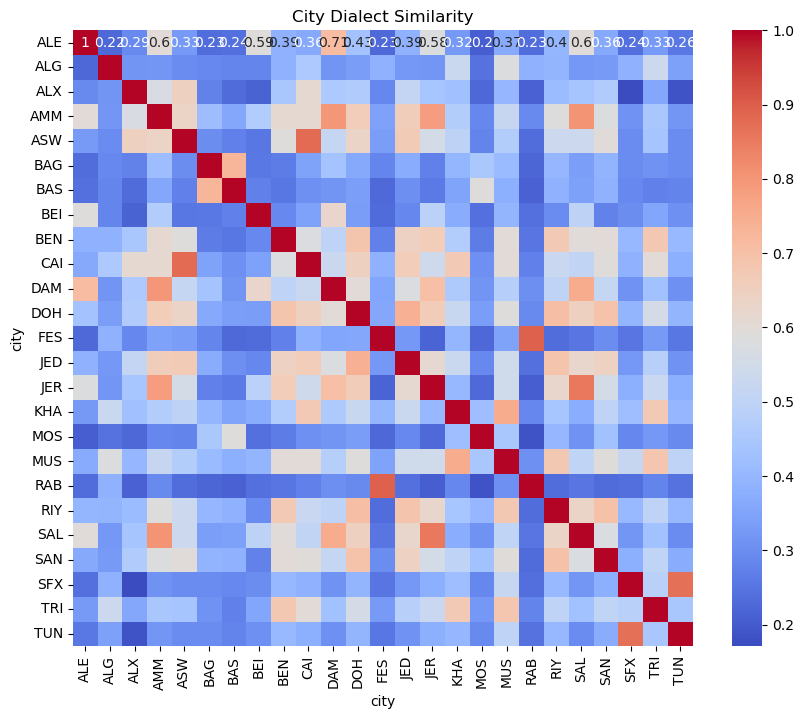

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(city_similarity_df, annot=True, cmap='coolwarm')
plt.title('City Dialect Similarity')
plt.show()

###  تحليل نتائج التشابه بين اللهجات بناء على المدينة
-المدن الواقعة في نفس المنطقة الجغرافية تتشابه  في الارتباطات. على سبيل المثال
  - **حلب** و **عمان** (0.9246)، مما يعكس تشابها قويا بين المدينتين .
  - **اس** و **الرباط** (0.8267)، مما يشير إلى أوجه تشابه بين المدينتين.
  - **جدّة** و **الرياض** (0.6937) يظهران أيضًا تقاربًا،
### **نلاحظ**
**تشابه المدن ضمن نفس المنطقة الجغرافية:**
   - المدن التي تقع ضمن نفس المنطقة الجغرافية تظهر تقاربًا واضحًا في الخصائص، مثل:
     - **المدن المغربية (فاس، الرباط)**، حيث تشترك في العديد من الخصائص.
     - **المدن السورية (دمشق، حلب)** أيضًا تظهر تقاربًا كبيرًا في البيانات.
   الدولة أو المنطقة.


 **التوزيع الجغرافي والاختلافات بين المناطق:**
   - المدن الواقعة في **شمال أفريقيا** (مثل فاس، الرباط) تُظهر تقاربًا معينًا، لكن هذا التشابه يقل عندما نقارن مع مدن **المشرق العربي**، مما يشير إلى وجود اختلافات في اللهجات والثقافات بين المناطق.
   - في المقابل، **المدن الخليجية** تظهر تقاربًا كبيرًا مع بعضها البعض، مما يعكس التأثير المتبادل في الخصائص الاجتماعية والثقافية.



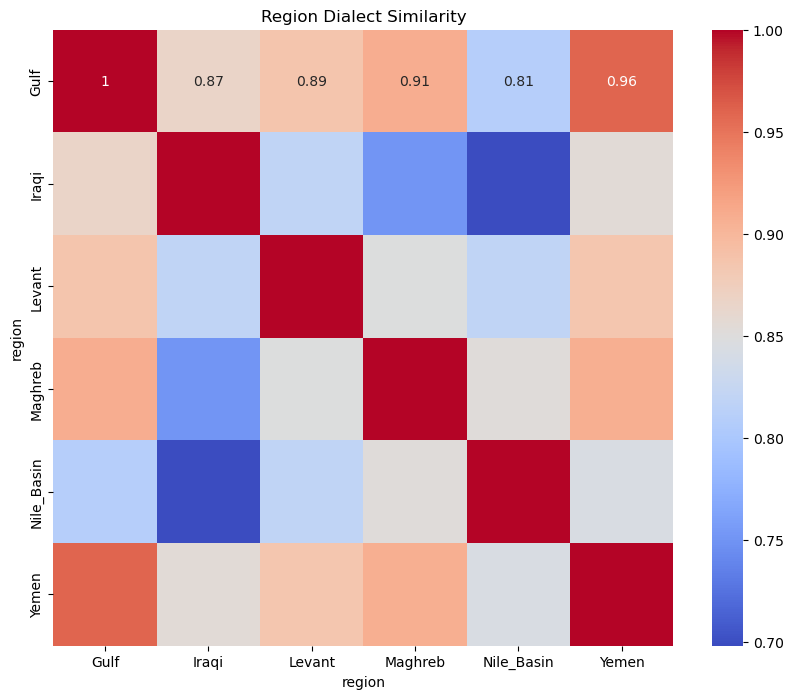

In [ ]:
# رسم Heatmap للتشابه بين المناطق
plt.figure(figsize=(10, 8))
sns.heatmap(region_similarity_df, annot=True, cmap='coolwarm')
plt.title('Region Dialect Similarity')
plt.show()


###  تحليل نتائج التشابه بين اللهجات بناء على المنطقة

1. **الخليج واليمن:**
   أعلى درجة تشابه بين اللهجات كانت بين الخليج واليمن (0.959). هذا يعكس التشابه الكبير في الاستخدام اللغوي بين اللهجات الخليجية واليمنية.

2. **الخليج والمغرب العربي:**
   هناك أيضًا درجة عالية من التشابه بين الخليج والمغرب العربي (0.908). هذا قد يشير إلى وجود تأثيرات لغوية متبادلة أو تقارب في مفردات معينة بين اللهجات.

3. **الخليج والشام:**
   أظهرت النتائج تقاربًا جيدًا بين الخليج وبلاد الشام (0.885). يشير هذا إلى تشابه نسبي في بعض الصيغ اللغوية.

4. **العراق وبلاد الشام:**
   يظهر أن التشابه بين العراق وبلاد الشام أقل مقارنة مع باقي اللهجات (0.818)، ولكنه لا يزال يشير إلى ارتباط لغوي معتدل.

5. **المغرب العربي والنيل:**
   تم تسجيل تشابه معتدل بين المغرب العربي والنيل (0.852)، مما يعكس بعض القواسم المشتركة في المفردات أو الأساليب اللغوية.

6. **اليمن والمناطق الأخرى:**
   اليمن أظهرت درجات عالية من التشابه مع معظم المناطق، مما يعكس تداخلًا لغويًا وثقافيًا مع المناطق الأخرى في العالم العربي.

**الاستنتاجات:**
- **أعلى درجة تشابه:** بين الخليج واليمن، مما يشير إلى التقارب اللغوي الكبير.
- **أقل درجة تشابه:** بين العراق والمناطق الأخرى، خاصة بلاد الشام، مما قد يشير إلى تنوع أكبر في اللهجات العراقية.


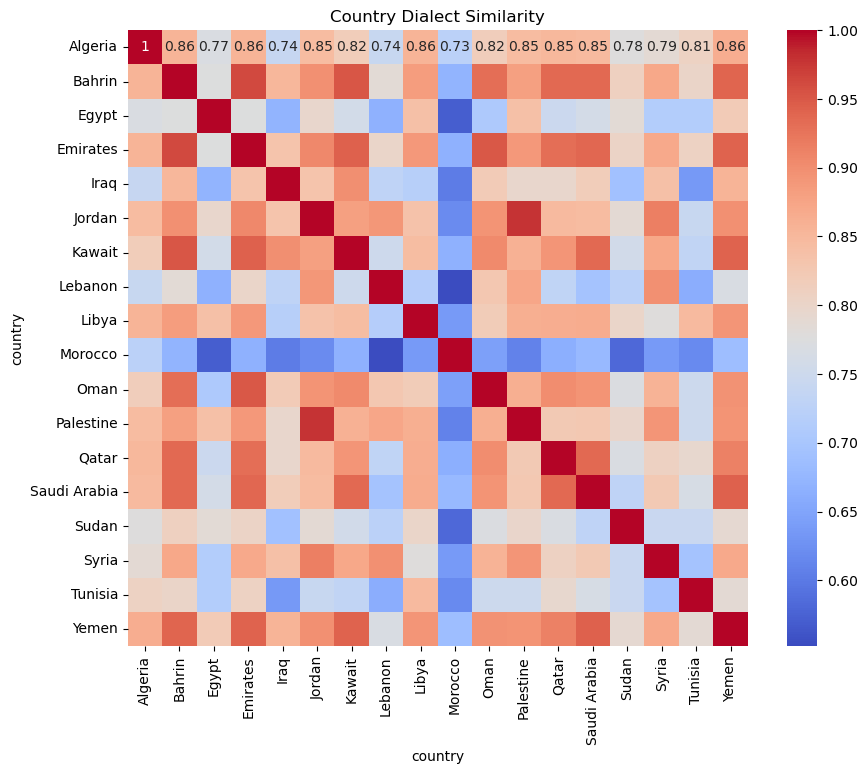

In [ ]:
# رسم Heatmap للتشابه بين البلدان
plt.figure(figsize=(10, 8))
sns.heatmap(country_similarity_df, annot=True, cmap='coolwarm')
plt.title('Country Dialect Similarity')
plt.show()



###  تحليل نتائج التشابه بين اللهجات بناء على الدولة
- يظهر من خلال مصفوفة التشابه أن **الدول الجغرافية المتقاربة** غالبًا ما تتشابه في نتائج التشابه بين بعضها. على سبيل المثال:
  - **دول الخليج العربي (البحرين، الإمارات، الكويت، قطر، عمان)** تظهر تقاربًا عاليًا في التشابه، حيث تتراوح قيم التشابه بينها بين **0.931025** و **0.962391**. هذا يعكس العوامل الثقافية واللغوية المشتركة بين هذه الدول، مثل اللغة والتقاليد الثقافية القريبة.
  - **دول الشام (سوريا، لبنان، الأردن، فلسطين)** يظهر أيضًا تقاربًا ملحوظًا بين بعضها، حيث تتراوح القيم بين **0.791226** و **0.977998**. هذا يشير إلى أن هذه الدول تشترك في بعض الخصائص الثقافية واللغوية.

### **نلاحظ**
**تشابه الدول ضمن نفس المنطقة الجغرافية**
   - الدول **الخليجية** (مثل **البحرين، الإمارات، قطر**) تُظهر تشابها قويا جدا في المقارنة مع بعضها البعض، حيث أن قيم التشابه بين بعضها تصل إلى مستويات عالية تتجاوز **0.9**.
   - الدول **المغاربية** (مثل **الجزائر، المغرب، تونس**) تظهر أيضا تشابها في بعض الجوانب، ولكن بدرجة أقل مقارنة مع دول الخليج والشام، حيث تراوحت قيم التشابه بين **0.6** .


- **الاختلافات الجغرافية** قد تساهم في وجود فوارق في التشابهات بين بعض الدول، مثل **المغرب** مقارنة مع دول الشام أو الخليج.

## [2.7]

In [43]:
# !pip install fasttext

# !wget -P /content https://dl.fbaipublicfiles.com/fasttext/vectors-crawl/cc.ar.300.bin.gz

# !gunzip /content/cc.ar.300.bin.gz

import fasttext

model = fasttext.load_model('C://Users//EUROPELAPTOP//Desktop//5th//NLP//Labs//NLP_homework//cc.ar.300.bin')


In [2]:
!pip install fasttext-wheel


  Using cached pybind11-2.13.6-py3-none-any.whl.metadata (9.5 kB)
   ---------------------------------------- 0.0/232.4 kB ? eta -:--:--
   ---------------------------------------- 0.0/232.4 kB ? eta -:--:--
   - -------------------------------------- 10.2/232.4 kB ? eta -:--:--
   - -------------------------------------- 10.2/232.4 kB ? eta -:--:--
   --- ----------------------------------- 20.5/232.4 kB 131.3 kB/s eta 0:00:02
   --- ----------------------------------- 20.5/232.4 kB 131.3 kB/s eta 0:00:02
   --- ----------------------------------- 20.5/232.4 kB 131.3 kB/s eta 0:00:02
   ----- ---------------------------------- 30.7/232.4 kB 93.5 kB/s eta 0:00:03
   ----- ---------------------------------- 30.7/232.4 kB 93.5 kB/s eta 0:00:03
   ----- ---------------------------------- 30.7/232.4 kB 93.5 kB/s eta 0:00:03
   ----- ---------------------------------- 30.7/232.4 kB 93.5 kB/s eta 0:00:03
   ------- -------------------------------- 41.0/232.4 kB 81.9 kB/s eta 0:00:03
   -----

In [ ]:
# import fasttext
# import fasttext.util

# # Download the model
# fasttext.util.download_model('ar', if_exists='ignore')

# # Load the model
# ft = fasttext.load_model('cc.ar.300.bin')

# # Define the save path on Google Drive
# save_path = '/content/drive/My Drive/Nlp1/cc.ar.300.bin'

# # Save the model
# ft.save_model(save_path)

# print(f"Model saved to: {save_path}")


In [ ]:
import fasttext
fasttext_model = fasttext.load_model('/content/drive/My Drive/Nlp1/cc.ar.300.bin')

all_tokens = train['tokens']

total_words = 0
oov_count = 0

model_words_set = set(fasttext_model.words)

for tokens in all_tokens:
    total_words += len(tokens)
    oov_count += len([word for word in tokens if word not in model_words_set])

oov_percentage = (oov_count / total_words) * 100 if total_words > 0 else 0

print(f"total words: {total_words}")
print(f"oov : {oov_count}")
print(f"oov percentage: {oov_percentage:.2f}%")

total words: 9104054
oov : 1046093
oov percentage: 11.49%


# مهمة 03 : تنظيف وتوحيد النص

normalization and cleaning Text

## [3.1]


In [50]:
def remove_diacritics(text):
    return re.sub(r'[ًٌٍَُِْ]', '', text)

def normalize_letters(text):
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "ء", text)
    text = re.sub("ئ", "ء", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)
    return text

def remove_repeated_characters(text):
    return re.sub(r'(.)\1+', r'\1\1', text)

def remove_punctuation(text):
    cleaned_text = re.sub(r'[^\w\s]', '', text)
    return cleaned_text.strip()

def remove_urls(text):
    return re.sub(r'http[s]?://\S+|www\.\S+', '', text)

def remove_mentions(text):
    return re.sub(r'@\w+', '', text)

def remove_hashtags(text):
    return re.sub(r'#\w+', '', text)

def remove_emojis(text):
    emoji_pattern = re.compile("["
                                u"\U0001F600-\U0001F64F"  # emoticons
                                u"\U0001F300-\U0001F5FF"  # symbols & pictographs
                                u"\U0001F680-\U0001F6FF"  # transport & map symbols
                                u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
                                u"\U00002700-\U000027BF"  # other symbols
                                u"\U000024C2-\U0001F251"  # enclosed characters
                                "]+", flags=re.UNICODE)
    return emoji_pattern.sub('', text)

def remove_stop_words(text):
    nltk_stop_words = set(stopwords.words('arabic'))
    custom_stop_words = {'ان', 'شاء', 'الله', 'من', 'في', 'و', 'يا', 'ما', 'الله', 'يبارك', 'فيك', 'اللي', 'مش', 'علي', 'على'}
    all_stop_words = nltk_stop_words.union(custom_stop_words)

    tokens = text.split()
    cleaned_tokens = [token for token in tokens if token not in all_stop_words]
    return ' '.join(cleaned_tokens)


## [3.2]

In [51]:
def apply_text_processing_functions(text, functions_list):
    for func in functions_list:
        text = func(text)
    return text

processing_functions = [
    # remove_diacritics,
    # normalize_letters,
    # remove_repeated_characters,
    remove_urls,
    remove_mentions,
    # remove_hashtags,
    # remove_emojis,
    # remove_stop_words,
    remove_punctuation,
]

## [3.3]

In [ ]:
original_text = train['text']
original_tokens = original_text.str.split().explode()
original_word_count = len(original_tokens)
original_unique_word_count = len(set(original_tokens))

# Apply text processing functions to the 'text' column
train['cleaned_text'] = train['text'].apply(lambda x: apply_text_processing_functions(x, processing_functions))

# Calculate word and unique word counts after cleaning
cleaned_tokens = train['cleaned_text'].str.split().explode()  
cleaned_word_count = len(cleaned_tokens)
cleaned_unique_word_count = len(set(cleaned_tokens))

# Print statistics
print("Words before cleaning:", original_word_count)
print("Unique words before cleaning:", original_unique_word_count)
print("Words after cleaning:", cleaned_word_count)
print("Unique words after cleaning:", cleaned_unique_word_count)

# Check if word counts were reduced
if cleaned_word_count < original_word_count:
    print("Total word count was reduced after cleaning.")
else:
    print("Total word count wasn't reduced after cleaning.")

if cleaned_unique_word_count < original_unique_word_count:
    print("Unique word count was reduced after cleaning.")
else:
    print("Unique word count wasn't reduced after cleaning.")


Words before cleaning: 7070970
Unique words before cleaning: 910291
Words after cleaning: 6286715
Unique words after cleaning: 545980
Total word count was reduced after cleaning.
Unique word count was reduced after cleaning.


## [3.4]

In [53]:
def is_short_sentence(text):
    """Determine if a sentence is short based on its total character count."""
    total_characters = len(text.replace(" ", ""))  # Remove spaces and count characters
    return total_characters < 5

# Identify rows to remove based on short sentences
rows_to_remove = train[train['cleaned_text'].apply(is_short_sentence)]

rows_to_remove_count = len(rows_to_remove)
print("Number of rows to be removed:", rows_to_remove_count)

# Filter out rows with short sentences
train_cleaned = train[~train['cleaned_text'].apply(is_short_sentence)]

print("Number of rows after removal:", len(train_cleaned))


Number of rows to be removed: 418
Number of rows after removal: 524163


In [ ]:
train.head()

,id,split,city,text,region,country,tokens,cleaned_text
0,5,train,TRI,اوني غادي، قدام متاع معلومات السواح بالضبط.,Maghreb,Libya,"[اوني, غادي, ،, قدام, متاع, معلومات, السواح, ب...",اوني غادي قدام متاع معلومات السواح بالضبط
1,9,train,TRI,ماعمريش سمعت بيه العنوان هدا هنايا.,Maghreb,Libya,"[ماعمريش, سمعت, بيه, العنوان, هدا, هنايا, .]",ماعمريش سمعت بيه العنوان هدا هنايا
2,11,train,TRI,برا طول لين تشوف صيدلية.,Maghreb,Libya,"[برا, طول, لين, تشوف, صيدلية, .]",برا طول لين تشوف صيدلية
3,26,train,TRI,بقداش الفطور؟,Maghreb,Libya,"[بقداش, الفطور, ؟]",بقداش الفطور
4,27,train,TRI,كيف نقدر نساعدك؟,Maghreb,Libya,"[كيف, نقدر, نساعدك, ؟]",كيف نقدر نساعدك


# مهمة 04  : بناء النموذج المرجعي

Model Baseline

## [4.1]


In [47]:
# merged_dataframe['text'] هي الداتا كلها خام
# train
X_train = train['text']
y_train = train['country']

# test
X_test = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test'),
    'text'
]
y_test = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test'),
    'country'
]

# validation
X_validation = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation'),
    'text'
]
y_validation = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation'),
    'country'
]

print(f"X_train rows: {len(X_train)}")
print(f"y_train rows: {len(y_train)}")
print(f"X_test rows: {len(X_test)}")
print(f"X_validation rows: {len(X_validation)}")


X_train rows: 524581
y_train rows: 524581
X_test rows: 13979
X_validation rows: 19152


## [4.2]

In [48]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
def train_model(function = "null"):
  X_train_new = X_train.copy()
  if function != "null":
    X_train_new = X_train_new.apply(lambda x: function(x))

  X_validation_new = X_validation.copy()
  if function != "null":
    X_validation_new = X_validation_new.apply(lambda x: function(x))

  X_test_new = X_test.copy()
  if function != "null":
    X_test_new = X_test_new.apply(lambda x: function(x))

  # الخطوة 1: تمثيل البيانات بطريقة TF-IDF
  # تمثيل البيانات بطريقة TF-IDF
  vectorizer = TfidfVectorizer(
    max_features=50000,
    analyzer='word',
    token_pattern=r'\b\w+\b',
    ngram_range=(1, 1),
    sublinear_tf=True,
    smooth_idf=True,
    use_idf=True,)
  X_train_tfidf = vectorizer.fit_transform(X_train_new)
  X_val_tfidf = vectorizer.transform(X_validation_new)
  X_test_tfidf = vectorizer.transform(X_test_new)

  # الخطوة 2: إنشاء نموذج Naive Bayes
  model = MultinomialNB(alpha=0.01)

  # الخطوة3: تدريب النموذج
  model.fit(X_train_tfidf, y_train)

  return model, X_val_tfidf, X_test_tfidf

model, x_val, x_test = train_model()

## [4.3]

In [72]:
comparison_table = {}

comparison_table['question_step_number'] = []
comparison_table['model_name'] = []
comparison_table['features'] = []
comparison_table['model_parameters'] = []
comparison_table['preprocessing_methods'] = []
comparison_table['accuracy'] = []
comparison_table['balance_accuracy'] = []

def save_results(question_number, model_name, model_parameters, accuracy, balance_accuracy, features="TF-IDF", preprocessing_methods="None"):
    comparison_table['question_step_number'].append(question_number)
    comparison_table['model_name'].append(model_name)
    comparison_table['features'].append(features)
    comparison_table['model_parameters'].append(model_parameters)
    comparison_table['preprocessing_methods'].append(preprocessing_methods)
    comparison_table['accuracy'].append(accuracy)
    comparison_table['balance_accuracy'].append(balance_accuracy)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, f1_score

# تعريف التابع لتدريب النموذج واختباره
def evaluate_model(model, X_val_tfidf, X_test_tfidf, function_name, is_none = False):

    # تقييم النموذج على مجموعة التحقق
    Y_val_pred = model.predict(X_val_tfidf)
    val_accuracy = accuracy_score(y_validation, Y_val_pred)

    # تقييم النموذج على مجموعة الاختبار
    Y_test_pred = model.predict(X_test_tfidf)
    test_accuracy = accuracy_score(y_test, Y_test_pred)

    f1_val = f1_score(y_validation, Y_val_pred, average='weighted')  # تستخدم 'weighted' للبيانات غير المتوازنة
    f1_test = f1_score(y_test, Y_test_pred, average='weighted')  # تستخدم 'weighted' للبيانات غير المتوازنة

    print("Accuracy: ", test_accuracy)
    print("F1-score: ", f1_test)

    if is_none == True:
      return test_accuracy, f1_test

    else:
      save_results(
      question_number="4.4",
      model_name='multinomial_naive_bayes',
      features='TF-IDF',
      model_parameters='alpha = 1',
      preprocessing_methods=f"{[function_name][0].__name__}",
      accuracy=test_accuracy,
      balance_accuracy=f1_test,
      )


test_accuracy, f1_test = evaluate_model(model, x_val, x_test, "null", True)

save_results(
    question_number="4.2",
    model_name='multinomial_naive_bayes',
    features='TF-IDF',
    model_parameters='alpha = 1',
    preprocessing_methods='None',
    accuracy=test_accuracy,
    balance_accuracy=f1_test,
)


Accuracy:  0.5885971814865155
F1-score:  0.5792074989474166


## [4.4]

In [ ]:
for function in processing_functions:
  print("function name: ", [function][0].__name__)
  print("\n")
  model, x_val, x_test = train_model(function)
  evaluate_model(model, x_val, x_test, function)

In [ ]:
comparison_df = pd.DataFrame(comparison_table)
comparison_df

,question_step_number,model_name,features,model_parameters,preprocessing_methods,accuracy,balance_accuracy
0,4.2,multinomial_naive_bayes,TF-IDF,alpha = 1,None,0.588597,0.579207
1,4.2,multinomial_naive_bayes,TF-IDF,alpha = 1,None,0.588597,0.579207
2,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_diacritics,0.589026,0.579728
3,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,normalize_letters,0.581515,0.571239
4,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_repeated_characters,0.589956,0.580611
5,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_urls,0.588669,0.579449
6,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_mentions,0.519422,0.507370
7,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_hashtags,0.585020,0.575429
8,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_emojis,0.589456,0.579979
9,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_stop_words,0.578081,0.567910


## [4.5]

In [ ]:
clean_functions = [
    remove_diacritics,
    normalize_letters,
    remove_repeated_characters,
    remove_urls,
    remove_hashtags,
    remove_punctuation,
]

clean_functions_names = []

for function in clean_functions:
  clean_functions_names.append([function][0].__name__)

In [ ]:
X_train_new = X_train.copy()
X_train_new = X_train_new.apply(lambda x: apply_text_processing_functions(x, clean_functions))

X_validation_new = X_validation.copy()
X_validation_new = X_validation_new.apply(lambda x: apply_text_processing_functions(x, clean_functions))

X_test_new = X_test.copy()
X_test_new = X_test_new.apply(lambda x: apply_text_processing_functions(x, clean_functions))

# الخطوة 1: تمثيل البيانات بطريقة TF-IDF
vectorizer = TfidfVectorizer(
    max_features=50000,
    analyzer='word',
    token_pattern=r'\b\w+\b',
    ngram_range=(1, 1),
    sublinear_tf=True,
    smooth_idf=True,
    use_idf=True,)
X_train_tfidf = vectorizer.fit_transform(X_train_new)
X_val_tfidf = vectorizer.transform(X_validation_new)
X_test_tfidf = vectorizer.transform(X_test_new)

# الخطوة 2: إنشاء نموذج Naive Bayes
model =MultinomialNB(alpha=0.01)

# الخطوة3: تدريب النموذج
model.fit(X_train_tfidf, y_train)

MultinomialNB(alpha=0.01)

In [ ]:
# تقييم النموذج على مجموعة التحقق
Y_val_pred = model.predict(X_val_tfidf)
val_accuracy = accuracy_score(y_validation, Y_val_pred)

# تقييم النموذج على مجموعة الاختبار
Y_test_pred = model.predict(X_test_tfidf)
test_accuracy = accuracy_score(y_test, Y_test_pred)

f1_val = f1_score(y_validation, Y_val_pred, average='weighted')  # تستخدم 'weighted' للبيانات غير المتوازنة
f1_test = f1_score(y_test, Y_test_pred, average='weighted')  # تستخدم 'weighted' للبيانات غير المتوازنة

print("Accuracy: ", test_accuracy)
print("F1-score: ", f1_test)

Accuracy:  0.5761499391945061
F1-score:  0.5662366648126175


In [ ]:
save_results(
question_number="4.5",
model_name='multinomial_naive_bayes',
features='TF-IDF',
model_parameters='alpha = 1',
preprocessing_methods= clean_functions_names,
accuracy=test_accuracy,
balance_accuracy=f1_test,
)

In [ ]:
comparison_df = pd.DataFrame(comparison_table)
comparison_df

,question_step_number,model_name,features,model_parameters,preprocessing_methods,accuracy,balance_accuracy
0,4.2,multinomial_naive_bayes,TF-IDF,alpha = 1,None,0.588597,0.579207
1,4.2,multinomial_naive_bayes,TF-IDF,alpha = 1,None,0.588597,0.579207
2,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_diacritics,0.589026,0.579728
3,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,normalize_letters,0.581515,0.571239
4,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_repeated_characters,0.589956,0.580611
5,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_urls,0.588669,0.579449
6,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_mentions,0.519422,0.507370
7,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_hashtags,0.585020,0.575429
8,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_emojis,0.589456,0.579979
9,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_stop_words,0.578081,0.567910


## [4.6]

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline

X_train_new = X_train.copy()
X_train_new = X_train_new.apply(lambda x: apply_text_processing_functions(x, clean_functions))

X_validation_new = X_validation.copy()
X_validation_new = X_validation_new.apply(lambda x: apply_text_processing_functions(x, clean_functions))

X_test_new = X_test.copy()
X_test_new = X_test_new.apply(lambda x: apply_text_processing_functions(x, clean_functions))



# إنشاء نموذج Pipeline
pipeline = Pipeline([
('tfidf', TfidfVectorizer()),
('model', MultinomialNB())
])

# ضبط معاملات TF-IDF
param_grid = {
'tfidf__max_features': [500, 1000, 2000, None],
'tfidf__ngram_range': [(1, 1), (1, 2)],  # كلمات منفردة أو أزواج كلمات
'tfidf__min_df': [1, 5, 10],
'tfidf__max_df': [0.8, 0.9, 1.0],
}

# استخدام GridSearchCV للبحث عن أفضل معاملات
grid_search = GridSearchCV(pipeline, param_grid, scoring='f1_weighted', cv=3, verbose=2)
grid_search.fit(X_train_new, y_train)


# أفضل نموذج
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_new)

# حساب المقاييس
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')

print("accuracy: ", accuracy)
print("f1-score: ", f1)

# حفظ النتائج
save_results(
    question_number="4.6",
    model_name='multinomial_naive_bayes',
    features='TF-IDF',
    model_parameters= grid_search.best_params_,
    preprocessing_methods= clean_functions_names,
    accuracy=test_accuracy,
    balance_accuracy=f1,
)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  14.1s
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  13.7s
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=1, tfidf__ngram_range=(1, 1); total time=  14.0s
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=1, tfidf__ngram_range=(1, 2); total time=  44.9s
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=1, tfidf__ngram_range=(1, 2); total time=  44.7s
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=1, tfidf__ngram_range=(1, 2); total time=  41.3s
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time=  15.2s
[CV] END tfidf__max_df=0.8, tfidf__max_features=500, tfidf__min_df=5, tfidf__ngram_range=(1, 1); total time=  14.5s
[CV] END t

In [ ]:
comparison_df = pd.DataFrame(comparison_table)
comparison_df

,question_step_number,model_name,features,model_parameters,preprocessing_methods,accuracy,balance_accuracy
0,4.2,multinomial_naive_bayes,TF-IDF,alpha = 1,None,0.588597,0.579207
1,4.2,multinomial_naive_bayes,TF-IDF,alpha = 1,None,0.588597,0.579207
2,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_diacritics,0.589026,0.579728
3,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,normalize_letters,0.581515,0.571239
4,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_repeated_characters,0.589956,0.580611
5,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_urls,0.588669,0.579449
6,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_mentions,0.519422,0.507370
7,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_hashtags,0.585020,0.575429
8,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_emojis,0.589456,0.579979
9,4.4,multinomial_naive_bayes,TF-IDF,alpha = 1,remove_stop_words,0.578081,0.567910


# مهمة 05 : التدريب باستخدام نماذج التعلم العميق

Deep learning

The Comparison Dictionary example

In [ ]:
# comparison_table = {
#     'question_step_number': [],
#     'model_name': [],
#     'features': [],
#     'model_parameters': [],
#     'preprocessing_methods': [],
#     'accuracy': [],
#     'balanced_accuracy': [] }

Filling the dictionary example

In [ ]:
# comparison_table['question_step_number'].append("3.5")
# comparison_table['model_name'].append('logistic_regression')
# comparison_table['features'].append('bag of words')
# comparison_table['model_parameters'].append('default')
# comparison_table['preprocessing_methods'].append("remove links")
# comparison_table['accuracy'].append(accuracy)
# comparison_table['balance_accuracy'].append(balance_accuracy_value)

## [5.1]

In [ ]:
nan_count = train['city'].isna().sum()
print(f"NAN city': {nan_count}")

nan_count = merged_dataframe.loc[merged_dataframe['split'] == 'validation'].isna().sum()
print(f"NAN city': {nan_count}")

NAN city': 440052
NAN city': id            0
split         0
city       9164
text          0
region     1197
country    1197
dtype: int64


In [55]:
# train
X_train = train.loc[train['city'].notna(), 'cleaned_text']
y_train = train.loc[train['city'].notna(), 'city']
# test
X_test = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test') & merged_dataframe['city'].notna(),
    'text'
]
y_test = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test') & merged_dataframe['city'].notna(),
    'city'
]

# validation
X_validation = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation') & merged_dataframe['city'].notna(),
    'text'
]
y_validation = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation') & merged_dataframe['city'].notna(),
    'city'
]

In [56]:
print(f" X_train: {len(X_train)}")
print(f" y_train: {len(y_train)}")
print(f" X_test: {len(X_test)}")
print(f" X_validation: {len(X_validation)}")


 X_train: 84529
 y_train: 84529
 X_test: 4998
 X_validation: 9988


In [57]:
# # Preprocess X_trainn to join tokens into strings
# X_train = [' '.join(tokens) for tokens in X_train]  # Join token lists into strings

In [58]:
# Step 2: Encode target labels
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_validation_encoded = label_encoder.transform(y_validation)
y_test_encoded = label_encoder.transform(y_test)

In [59]:
# One-hot encode the labels
y_train_categorical = to_categorical(y_train_encoded)
y_validation_categorical = to_categorical(y_validation_encoded)
y_test_categorical = to_categorical(y_test_encoded)

In [60]:
print("Number of unique classes in y_train_encoded:", len(np.unique(y_train_encoded)))


Number of unique classes in y_train_encoded: 25


In [61]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    analyzer='word',
    token_pattern=r'\b\w+\b',
    ngram_range=(1, 1),
    sublinear_tf=True,
    smooth_idf=True,
    use_idf=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_validation_tfidf = vectorizer.transform(X_validation)
X_test_tfidf = vectorizer.transform(X_test)


In [62]:
nb_model = MultinomialNB(alpha=0.01)

nb_model.fit(X_train_tfidf, y_train)

train_nb_proba = nb_model.predict_proba(X_train_tfidf)
validation_nb_proba = nb_model.predict_proba(X_validation_tfidf)
test_nb_proba = nb_model.predict_proba(X_test_tfidf)

from scipy.sparse import hstack

X_train_combined = hstack((X_train_tfidf, train_nb_proba))
X_validation_combined = hstack((X_validation_tfidf, validation_nb_proba))
X_test_combined = hstack((X_test_tfidf, test_nb_proba))


In [63]:
model1 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_combined.shape[1],)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    # Dense(64, activation='relu'),
    # Dropout(0.4),
    # Dense(32, activation='relu'),
    # Dropout(0.4),
    Dense(y_train_categorical.shape[1], activation='softmax')
])

model1.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\EUROPELAPTOP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [64]:
history = model1.fit(
    X_train_combined, y_train_categorical,
    validation_data=(X_validation_combined, y_validation_categorical),
    epochs=6,
    batch_size=64,
    verbose=1
)

Epoch 1/6
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 82s 59ms/step - accuracy: 0.6037 - loss: 1.6298 - val_accuracy: 0.7072 - val_loss: 1.3496
Epoch 2/6
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 74s 56ms/step - accuracy: 0.8409 - loss: 0.6126 - val_accuracy: 0.7075 - val_loss: 1.3830
Epoch 3/6
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 76s 57ms/step - accuracy: 0.8601 - loss: 0.5137 - val_accuracy: 0.7054 - val_loss: 1.4371
Epoch 4/6
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 79s 60ms/step - accuracy: 0.8687 - loss: 0.4679 - val_accuracy: 0.7057 - val_loss: 1.5335
Epoch 5/6
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 79s 59ms/step - accuracy: 0.8775 - loss: 0.4238 - val_accuracy: 0.7049 - val_loss: 1.6163
Epoch 6/6
1321/1321 ━━━━━━━━━━━━━━━━━━━━ 78s 59ms/step - accuracy: 0.8802 - loss: 0.4104 - val_accuracy: 0.7036 - val_loss: 1.6989


In [65]:
from sklearn.metrics import f1_score, classification_report

train_loss, train_accuracy = model1.evaluate(X_train_combined, y_train_categorical, verbose=1)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

validation_loss, validation_accuracy = model1.evaluate(X_validation_combined, y_validation_categorical, verbose=1)
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")

test_loss, test_accuracy = model1.evaluate(X_test_combined, y_test_categorical, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

y_test_pred = model1.predict(X_test_combined).argmax(axis=1)
y_test_true = y_test_categorical.argmax(axis=1)
test_f1 = f1_score(y_test_true, y_test_pred, average='weighted')
print(f"Test F1-score: {test_f1 * 100:.2f}%")

2642/2642 ━━━━━━━━━━━━━━━━━━━━ 17s 6ms/step - accuracy: 0.9031 - loss: 0.2893
Training Accuracy: 92.07%
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6400 - loss: 2.0979
Validation Accuracy: 70.36%
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5084 - loss: 3.0751
Test Accuracy: 54.98%
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step
Test F1-score: 55.71%


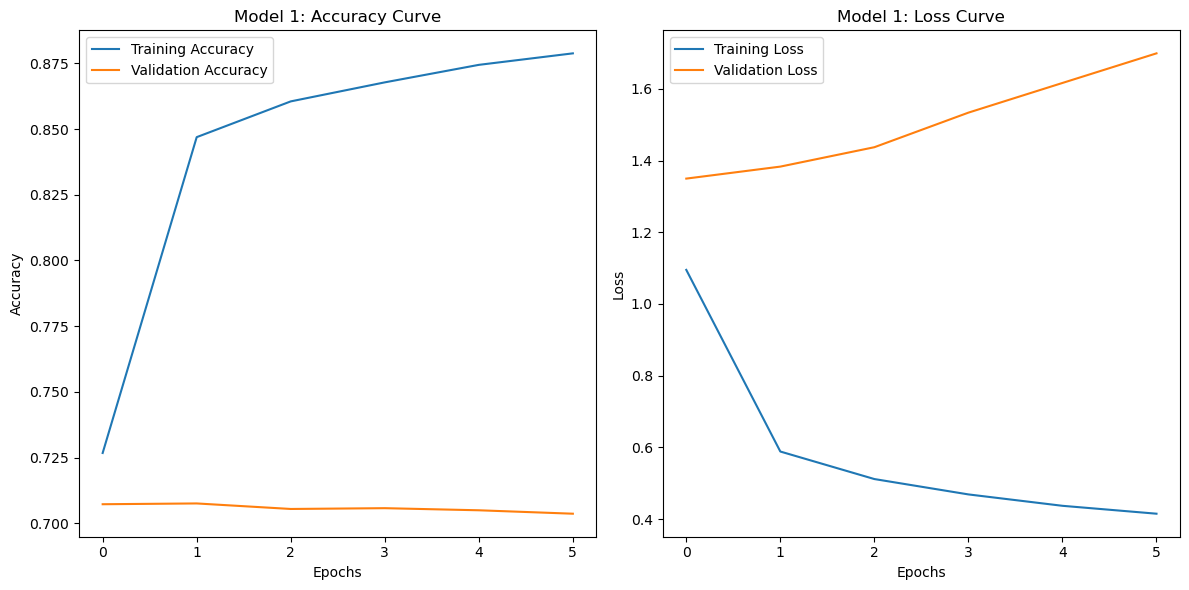

In [66]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model 1: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


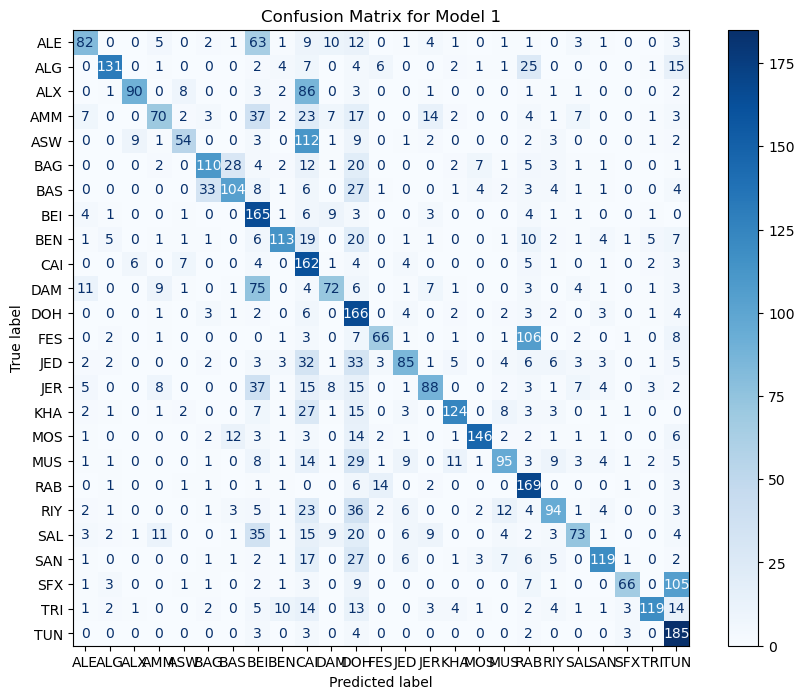

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

class_names = label_encoder.classes_

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_true, y_test_pred)

# Create a ConfusionMatrixDisplay with custom labels and larger size
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)

# Customize the plot
fig, ax = plt.subplots(figsize=(10, 8))  # Set figure size
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title("Confusion Matrix for Model 1")
plt.show()


In [73]:
save_results(
    question_number="5.1_city_",
    model_name="Sequential_Neural_Network",
    features='TF-IDF',
    model_parameters="max_features=50000,optimizer=adam,epochs=6,batch_size=64,loss=categorical_crossentropyepochs=6,batch_size=64",
    preprocessing_methods=' remove_diacritics,normalize_letters, remove_repeated_characters, remove_urls,remove_hashtags,remove_punctuation',
    accuracy=test_accuracy,
    balance_accuracy=test_f1,
)


In [74]:
comparison_df = pd.DataFrame(comparison_table)
comparison_df

,question_step_number,model_name,features,model_parameters,preprocessing_methods,accuracy,balance_accuracy
0,5.1_city_,Sequential_Neural_Network,TF-IDF,"max_features=50000,optimizer=adam,epochs=6,bat...","remove_diacritics,normalize_letters, remove_r...",0.54982,0.557129


In [75]:
df.to_csv("[results].csv", index=False)

In [76]:
import joblib
joblib.dump(model1, 'model1.pkl')  # Save the model to a file
print("Model saved successfully!")


Model saved successfully!


In [77]:
from tensorflow.keras import backend as K
K.clear_session()

## [5.2]

### [5.2.1]

In [78]:
tokenizer = Tokenizer(num_words=50000)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_validation_seq = tokenizer.texts_to_sequences(X_validation)

max_length = max(len(seq) for seq in tokenizer.texts_to_sequences(X_train))
X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')
X_validation_padded = pad_sequences(X_validation_seq, maxlen=max_length, padding='post')

In [79]:
model = Sequential([
    Embedding(input_dim=50000, output_dim=128, input_length=max_length),

    # طبقة CNN مع MaxPooling
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),

    Dense(y_train_categorical.shape[1], activation='softmax')

])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

c:\Users\EUROPELAPTOP\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [80]:
model.fit(X_train_padded, y_train_categorical,
          validation_data=(X_validation_padded, y_validation_categorical),
          epochs=6, batch_size=128)

Epoch 1/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 87s 121ms/step - accuracy: 0.3753 - loss: 2.2472 - val_accuracy: 0.6089 - val_loss: 1.3394
Epoch 2/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 79s 119ms/step - accuracy: 0.7210 - loss: 0.9049 - val_accuracy: 0.6390 - val_loss: 1.2684
Epoch 3/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 79s 119ms/step - accuracy: 0.8273 - loss: 0.5452 - val_accuracy: 0.6440 - val_loss: 1.3364
Epoch 4/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 80s 121ms/step - accuracy: 0.8825 - loss: 0.3726 - val_accuracy: 0.6418 - val_loss: 1.4468
Epoch 5/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 80s 121ms/step - accuracy: 0.9064 - loss: 0.2902 - val_accuracy: 0.6379 - val_loss: 1.5816
Epoch 6/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 73s 110ms/step - accuracy: 0.9229 - loss: 0.2336 - val_accuracy: 0.6388 - val_loss: 1.6820


In [82]:
# Predict on the test set
y_test_pred_prob = model.predict(X_test_padded)

# Convert probabilities to class labels
y_test_pred = np.argmax(y_test_pred_prob, axis=1)
y_test_true = np.argmax(y_test_categorical, axis=1)  # Assuming y_test_categorical is one-hot encoded

# Calculate accuracy
accuracy = accuracy_score(y_test_true, y_test_pred)

# Calculate F1-score (macro-average for multi-class problems)
f1 = f1_score(y_test_true, y_test_pred, average='macro')

# Print results
print(f"Accuracy: {accuracy:.2f}")
print(f"F1 Score (Macro): {f1:.2f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.47
F1 Score (Macro): 0.47


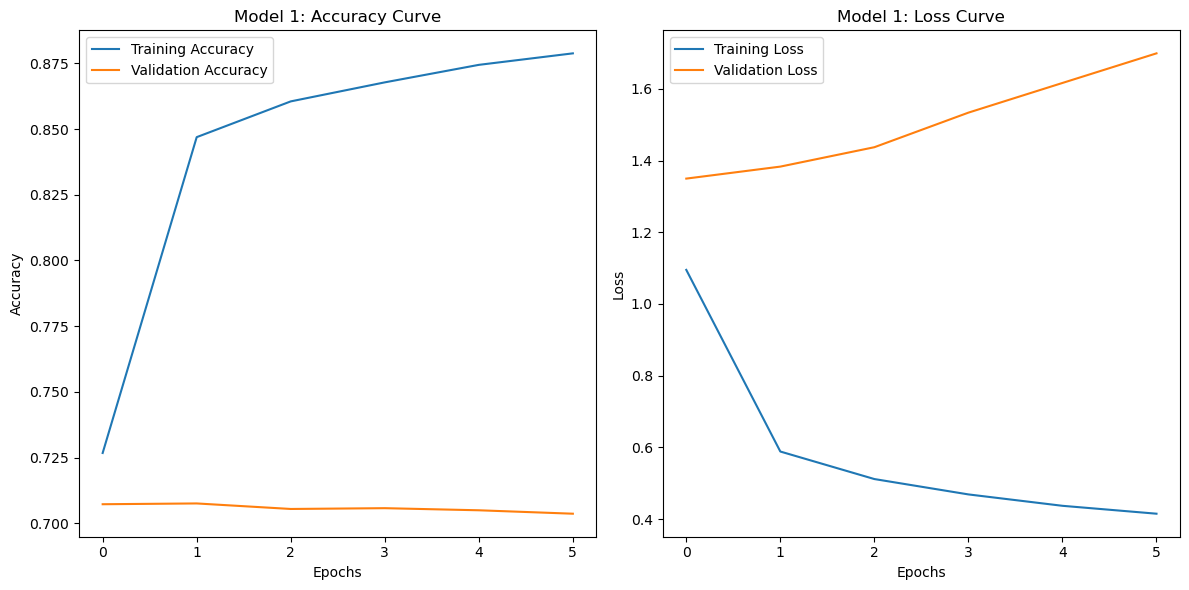

In [83]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model 1: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


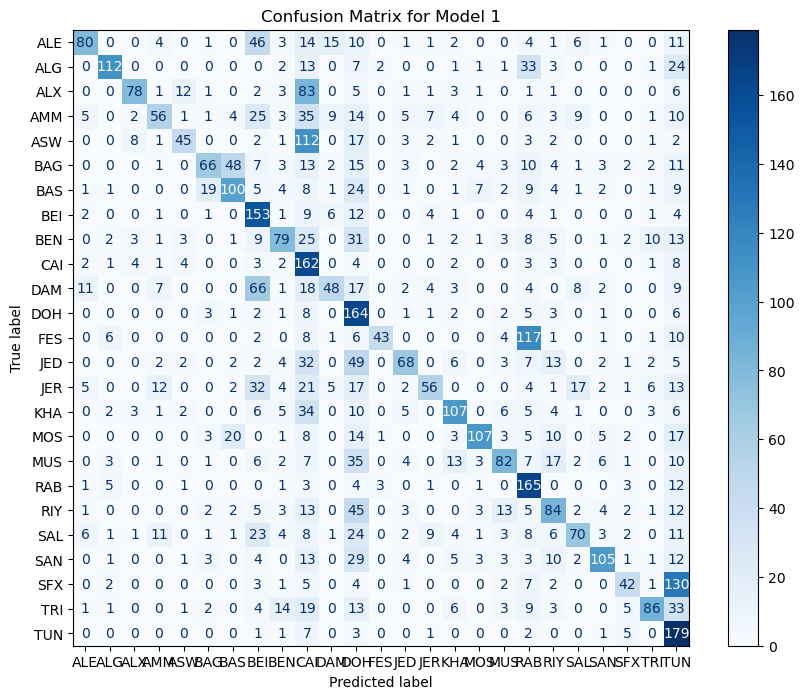

In [84]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

class_names = label_encoder.classes_

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_true, y_test_pred)

# Create a ConfusionMatrixDisplay with custom labels and larger size
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)

# Customize the plot
fig, ax = plt.subplots(figsize=(10, 8))  # Set figure size
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title("Confusion Matrix for Model 1")
plt.show()


In [89]:
save_results(
    question_number="5.2.1_city_",
    model_name="CNN_without_fasttext",
    features="Embedding layer",
    model_parameters="Embedding:50000,cnn(128,5),batch_size=128,epochs=6,optimizer=adam,loss=categorical_crossentropy",
    preprocessing_methods=' remove_diacritics,normalize_letters, remove_repeated_characters, remove_urls,remove_hashtags,remove_punctuation',
    accuracy=accuracy,
    balance_accuracy=f1,
)



In [90]:
comparison_df = pd.DataFrame(comparison_table)
comparison_df

,question_step_number,model_name,features,model_parameters,preprocessing_methods,accuracy,balance_accuracy
0,5.1_city_,Sequential_Neural_Network,TF-IDF,"max_features=50000,optimizer=adam,epochs=6,bat...","remove_diacritics,normalize_letters, remove_r...",0.549820,0.557129
1,5.2.1_city_,CNN_without_fasttext,Embedding layer,"Embedding:50000,cnn(128,5),batch_size=128,epoc...","remove_diacritics,normalize_letters, remove_r...",0.549820,0.467591
2,5.2.1_city_,CNN_without_fasttext,Embedding layer,"Embedding:50000,cnn(128,5),batch_size=128,epoc...","remove_diacritics,normalize_letters, remove_r...",0.467587,0.467591


In [91]:
df.to_csv("[results].csv", index=False)

In [92]:
import pickle

# Save the model to a file
with open('cnn.model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Model saved successfully!")

Model saved successfully!


In [93]:
from tensorflow.keras import backend as K
K.clear_session()

### [5.2.2]

In [94]:
import fasttext
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load FastText binary model
#model = fasttext.load_model('cc.ar.100.bin')

# Use `to_categorical` encoded labels directly
num_classes = y_train_categorical.shape[1]

# Parameters
max_vocab_size = 50000
#max_sequence_length = 200
embedding_dim = 300

# Prepare embedding matrix
def create_embedding_matrix(tokenizer, model, max_vocab_size, embedding_dim):
    word_index = tokenizer.word_index
    num_words = min(max_vocab_size, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embedding_dim))
    for word, i in word_index.items():
        if i < max_vocab_size:
            try:
                embedding_matrix[i] = model.get_word_vector(word)
            except KeyError:
                embedding_matrix[i] = np.zeros(embedding_dim)  # Default vector for unknown words
    return embedding_matrix

# Tokenizer setup
tokenizer = Tokenizer(num_words=max_vocab_size)

tokenizer.fit_on_texts(X_train)
max_sequence_length = max(len(seq) for seq in tokenizer.texts_to_sequences(X_train))

# Create the embedding matrix
embedding_matrix = create_embedding_matrix(tokenizer, fasttext_model, max_vocab_size, embedding_dim)

# Prepare padded sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_validation_seq = tokenizer.texts_to_sequences(X_validation)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post')
X_validation_padded = pad_sequences(X_validation_seq, maxlen=max_sequence_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post')

# Define the CNN model
model_1 = Sequential([
    Embedding(input_dim=embedding_matrix.shape[0],
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_sequence_length,
              trainable=False),  # Set to True for fine-tuning
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model_1.fit(X_train_padded, y_train_categorical,
          validation_data=(X_validation_padded, y_validation_categorical),
          epochs=6, batch_size=128)



c:\Users\EUROPELAPTOP\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 34s 47ms/step - accuracy: 0.4476 - loss: 2.0721 - val_accuracy: 0.5491 - val_loss: 1.5099
Epoch 2/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 33s 50ms/step - accuracy: 0.6179 - loss: 1.2674 - val_accuracy: 0.5782 - val_loss: 1.3849
Epoch 3/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 34s 52ms/step - accuracy: 0.6622 - loss: 1.0928 - val_accuracy: 0.5914 - val_loss: 1.3520
Epoch 4/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 43s 64ms/step - accuracy: 0.6945 - loss: 0.9723 - val_accuracy: 0.5935 - val_loss: 1.3163
Epoch 5/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.7200 - loss: 0.8812 - val_accuracy: 0.5970 - val_loss: 1.3320
Epoch 6/6
661/661 ━━━━━━━━━━━━━━━━━━━━ 47s 71ms/step - accuracy: 0.7465 - loss: 0.7974 - val_accuracy: 0.5956 - val_loss: 1.3996


In [95]:
from sklearn.metrics import f1_score, classification_report
# Evaluate the model
loss, accuracy = model_1.evaluate(X_test_padded, y_test_categorical)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

y_pred_prob = model_1.predict(X_test_padded)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1}")


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3587 - loss: 2.1562
Test Loss: 2.143934488296509, Test Accuracy: 0.3781512677669525
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
F1 Score: 0.3659294815477914


AttributeError: 'Sequential' object has no attribute 'model_1'

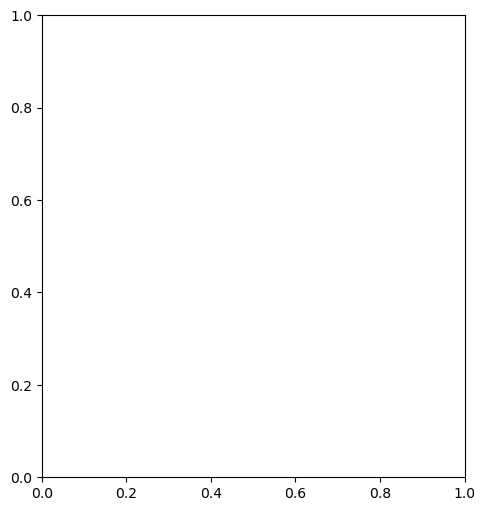

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# منحنى الدقة
plt.subplot(1, 2, 1)
plt.plot(model_1.model_1['accuracy'], label='Training Accuracy')
plt.plot(model_1.model_1['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# منحنى الخسارة
plt.subplot(1, 2, 2)
plt.plot(model_1.model_1['loss'], label='Training Loss')
plt.plot(model_1.model_1['val_loss'], label='Validation Loss')
plt.title('Model 1: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

class_names = label_encoder.classes_

# Compute the confusion matrix
conf_matrix = confusion_matrix(y_test_true, y_test_pred)

# Create a ConfusionMatrixDisplay with custom labels and larger size
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)

# Customize the plot
fig, ax = plt.subplots(figsize=(10, 8))  # Set figure size
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=ax)
plt.title("Confusion Matrix for Model 1")
plt.show()


In [ ]:
save_results(
    question_number="5.2.2_city_",
    model_name="CNN with fastext with freeze"
    features="Embedding layer",
    model_parameters="Embedding:50000,cnn(128,5),batch_size=128,epochs=6,optimizer=adam,loss=categorical_crossentropy"
    preprocessing_methods=' remove_diacritics,normalize_letters, remove_repeated_characters, remove_urls,remove_hashtags,remove_punctuation',
    accuracy=accuracy,
    balance_accuracy=f1,
)

In [ ]:
import pickle

# Save the model to a file
with open('5.2.2.model.pkl', 'wb') as file:
    pickle.dump(model_1, file)
print("Model saved successfully!")

In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

### [5.2.3]

In [ ]:
# Define the CNN model
model_2 = Sequential([
    Embedding(input_dim=embedding_matrix.shape[0],
              output_dim=embedding_dim,
              weights=[embedding_matrix],
              input_length=max_sequence_length,
              trainable=True),  # Set to True for fine-tuning
    Conv1D(filters=128, kernel_size=5, activation='relu'),
    GlobalMaxPooling1D(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model
model_2.fit(X_train_padded, y_train_categorical,
          validation_data=(X_validation_padded, y_validation_categorical),
          epochs=6, batch_size=128)



Epoch 1/6
743/743 [==============================] - 409s 549ms/step - loss: 1.3197 - accuracy: 0.6276 - val_loss: 1.1145 - val_accuracy: 0.6657
Epoch 2/6
743/743 [==============================] - 406s 547ms/step - loss: 0.6488 - accuracy: 0.7927 - val_loss: 1.1099 - val_accuracy: 0.6815
Epoch 3/6
743/743 [==============================] - 407s 547ms/step - loss: 0.4009 - accuracy: 0.8713 - val_loss: 1.2171 - val_accuracy: 0.6742
Epoch 4/6
743/743 [==============================] - 405s 545ms/step - loss: 0.2913 - accuracy: 0.9052 - val_loss: 1.3451 - val_accuracy: 0.6651
Epoch 5/6
743/743 [==============================] - 406s 546ms/step - loss: 0.2376 - accuracy: 0.9222 - val_loss: 1.4618 - val_accuracy: 0.6713
Epoch 6/6
163/163 [==============================] - 2s 14ms/step - loss: 2.5203 - accuracy: 0.4958
Test Loss: 2.520272731781006, Test Accuracy: 0.49576759338378906


In [ ]:
from sklearn.metrics import f1_score, classification_report
# Evaluate the model
loss, accuracy = model_2.evaluate(X_test_padded, y_test_categorical)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")

y_pred_prob = model_2.predict(X_test_padded)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_categorical, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted')
print(f"F1 Score: {f1}")


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

# منحنى الدقة
plt.subplot(1, 2, 1)
plt.plot(model_2.model_2['accuracy'], label='Training Accuracy')
plt.plot(model_2.model_2['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# منحنى الخسارة
plt.subplot(1, 2, 2)
plt.plot(model_2.model_2['loss'], label='Training Loss')
plt.plot(model_2.model_2['val_loss'], label='Validation Loss')
plt.title('Model 1: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
save_results(
    question_number="5.2.3_city_",
    model_name="CNN with fastext without freeze"
    features="Embedding layer",
    model_parameters="Embedding:50000,cnn(128,5),batch_size=128,epochs=6,optimizer=adam,loss=categorical_crossentropy"
    preprocessing_methods=' remove_diacritics,normalize_letters, remove_repeated_characters, remove_urls,remove_hashtags,remove_punctuation',
    accuracy=accuracy,
    balance_accuracy=f1,
)

In [ ]:
import pickle

# Save the model to a file
with open('5.2.2.model.pkl', 'wb') as file:
    pickle.dump(model_2, file)
print("Model saved successfully!")

In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

## [5.3]

In [ ]:
# Model 1: TF-IDF + MultinomialNB + Dense Neural Network
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam



# Use `to_categorical` encoded labels directly
num_classes = y_train_categorical.shape[1]

# Parameters
max_vocab_size = 50000
#max_sequence_length = 200
embedding_dim = 300

# Prepare embedding matrix
def create_embedding_matrix(tokenizer, model, max_vocab_size, embedding_dim):
    word_index = tokenizer.word_index
    num_words = min(max_vocab_size, len(word_index) + 1)
    embedding_matrix = np.zeros((num_words, embedding_dim))
    for word, i in word_index.items():
        if i < max_vocab_size:
            try:
                embedding_matrix[i] = model.get_word_vector(word)
            except KeyError:
                embedding_matrix[i] = np.zeros(embedding_dim)  # Default vector for unknown words
    return embedding_matrix

# Tokenizer setup
tokenizer = Tokenizer(num_words=max_vocab_size)

tokenizer.fit_on_texts(X_train)
max_sequence_length = max(len(seq) for seq in tokenizer.texts_to_sequences(X_train))

# Create the embedding matrix
embedding_matrix = create_embedding_matrix(tokenizer, fasttext_model, max_vocab_size, embedding_dim)

# Prepare padded sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_validation_seq = tokenizer.texts_to_sequences(X_validation)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post')
X_validation_padded = pad_sequences(X_validation_seq, maxlen=max_sequence_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post')


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the CNN model with regularization
model = Sequential([
    # Embedding layer
    Embedding(input_dim=embedding_matrix.shape[0],
              output_dim=embedding_dim,  # Reduced to avoid overfitting
              weights=[embedding_matrix],
              input_length=max_sequence_length,
              trainable=True),

    # Convolutional layer
    Conv1D(filters=128, kernel_size=3, activation='relu'),
    GlobalMaxPooling1D(),

    # Dropout for regularization
    Dropout(0.5),

    # Dense layer with Dropout
    Dense(64, activation='relu'),
    Dropout(0.5),

    # Output layer
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(
    X_train_padded, y_train_categorical,
    validation_data=(X_validation_padded, y_validation_categorical),
    epochs=10,
    batch_size=64
)

# Evaluate the model
loss, accuracy = model.evaluate(X_test_padded, y_test_categorical)
print(f"Test Loss: {loss}, Test Accuracy: {accuracy}")



In [ ]:
# طباعة الدقة للنموذج الأول
train_accuracy1 = model.evaluate(X_train_combined, y_train_categorical, verbose=0)[1]
validation_accuracy1 = model.evaluate(X_validation_combined, y_validation_categorical, verbose=0)[1]
test_accuracy1 = model.evaluate(X_test_combined, y_test_categorical, verbose=0)[1]

print(f"Model - Training Accuracy: {train_accuracy1:.4f}")
print(f"Model - Validation Accuracy: {validation_accuracy1:.4f}")
print(f"Model - Test Accuracy: {test_accuracy1:.4f}")

In [ ]:
import matplotlib.pyplot as plt

# رسم منحنيات التعلم للنموذج الأول
plt.figure(figsize=(12, 6))

# منحنيات الدقة
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# منحنيات الخسارة
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model 1: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
from tensorflow.keras import backend as K
K.clear_session()

## [5.4]

## [5.5]

## [5.6]

الدولة

In [76]:
# train
X_train_c = train.loc[train['country'].notna(), 'cleaned_text']
y_train_c = train.loc[train['country'].notna(), 'country']
# test
X_test_c = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test') & merged_dataframe['country'].notna(),
    'text'
]
y_test_c = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test') & merged_dataframe['country'].notna(),
    'country'
]

# validation
X_validation_c = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation') & merged_dataframe['country'].notna(),
    'text'
]
y_validation_c = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation') & merged_dataframe['country'].notna(),
    'country'
]

In [77]:
# Step 2: Encode target labels
label_encoder = LabelEncoder()
y_train_encoded_c = label_encoder.fit_transform(y_train_c)
y_validation_encoded_c  = label_encoder.transform(y_validation_c)
y_test_encoded_c  = label_encoder.transform(y_test_c)

In [78]:
# One-hot encode the labels
y_train_categorical_c = to_categorical(y_train_encoded_c)
y_validation_categorical_c = to_categorical(y_validation_encoded_c)
y_test_categorical_c = to_categorical(y_test_encoded_c)

In [86]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    analyzer='word',
    token_pattern=r'\b\w+\b',
    ngram_range=(1, 1),
    sublinear_tf=True,
    smooth_idf=True,
    use_idf=True,
)

X_train_tfidf_c = vectorizer.fit_transform(X_train_c)
X_validation_tfidf_c = vectorizer.transform(X_validation_c)
X_test_tfidf_c = vectorizer.transform(X_test_c)


In [87]:
nb_model = MultinomialNB(alpha=0.01)

nb_model.fit(X_train_tfidf_c, y_train_c)

train_nb_proba_c = nb_model.predict_proba(X_train_tfidf_c)
validation_nb_proba_c = nb_model.predict_proba(X_validation_tfidf_c)
test_nb_proba_c = nb_model.predict_proba(X_test_tfidf_c)

from scipy.sparse import hstack

X_train_combined_c  = hstack((X_train_tfidf_c, train_nb_proba_c))
X_validation_combined_c  = hstack((X_validation_tfidf_c , validation_nb_proba_c))
X_test_combined_c  = hstack((X_test_tfidf_c , test_nb_proba_c))


In [88]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_combined_c.shape[1],)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    # Dense(64, activation='relu'),
    # Dropout(0.4),
    # Dense(32, activation='relu'),
    # Dropout(0.4),
    Dense(y_train_categorical_c.shape[1], activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\EUROPELAPTOP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [89]:
history = model.fit(
    X_train_combined_c, y_train_categorical_c,
    validation_data=(X_validation_combined_c, y_validation_categorical_c),
    epochs=6,
    batch_size=64,
    verbose=1
)

Epoch 1/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 493s 60ms/step - accuracy: 0.5677 - loss: 1.5233 - val_accuracy: 0.6036 - val_loss: 1.4153
Epoch 2/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 538s 66ms/step - accuracy: 0.6607 - loss: 1.1877 - val_accuracy: 0.6041 - val_loss: 1.4396
Epoch 3/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 4369s 533ms/step - accuracy: 0.6710 - loss: 1.1390 - val_accuracy: 0.6057 - val_loss: 1.4539
Epoch 4/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 576s 70ms/step - accuracy: 0.6799 - loss: 1.1006 - val_accuracy: 0.6054 - val_loss: 1.4700
Epoch 5/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 539s 66ms/step - accuracy: 0.6867 - loss: 1.0685 - val_accuracy: 0.6054 - val_loss: 1.5026
Epoch 6/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 532s 65ms/step - accuracy: 0.6931 - loss: 1.0410 - val_accuracy: 0.6056 - val_loss: 1.5284


In [90]:
from sklearn.metrics import f1_score, classification_report

train_loss, train_accuracy = model.evaluate(X_train_combined_c, y_train_categorical_c, verbose=1)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

validation_loss, validation_accuracy = model.evaluate(X_validation_combined_c, y_validation_categorical_c, verbose=1)
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")

test_loss, test_accuracy = model.evaluate(X_test_combined_c, y_test_categorical_c, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

y_test_pred = model.predict(X_test_combined_c).argmax(axis=1)
y_test_true = y_test_categorical_c.argmax(axis=1)
test_f1 = f1_score(y_test_true, y_test_pred, average='weighted')
print(f"Test F1-score: {test_f1 * 100:.2f}%")

16394/16394 ━━━━━━━━━━━━━━━━━━━━ 139s 8ms/step - accuracy: 0.7791 - loss: 0.7565
Training Accuracy: 76.56%
599/599 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6563 - loss: 1.3228
Validation Accuracy: 60.56%
437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.5642 - loss: 1.6447
Test Accuracy: 53.00%
437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step
Test F1-score: 52.23%


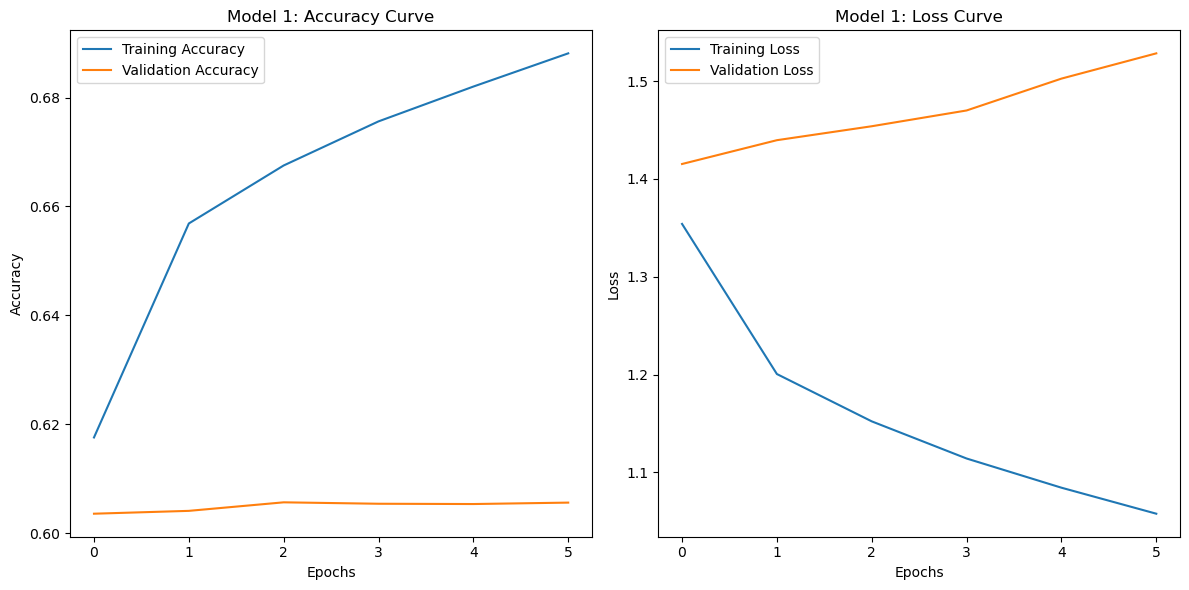

In [93]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model 1: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [97]:
save_results(
    question_number="5.6.1_country_",
    model_name="Sequential_Neural_Network",
    features='TF-IDF',
    model_parameters=' remove_diacritics,normalize_letters, remove_repeated_characters, remove_urls,remove_hashtags,remove_punctuation',
    preprocessing_methods="max_features=50000,optimizer=adam,loss=categorical_crossentropyepochs=6,batch_size=64",
    accuracy=test_accuracy,
    balance_accuracy=test_f1,
)


In [100]:
import pickle

# Save the model to a file
with open('country.model.pkl', 'wb') as file:
    pickle.dump(model, file)
print("Model saved successfully!")

Model saved successfully!


In [101]:
from tensorflow.keras import backend as K
K.clear_session()

المنطقة

In [102]:
# train
X_train_r = train.loc[train['region'].notna(), 'cleaned_text']
y_train_r = train.loc[train['region'].notna(), 'region']
# test
X_test_r = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test') & merged_dataframe['region'].notna(),
    'text'
]
y_test_r = merged_dataframe.loc[
    (merged_dataframe['split'] == 'test') & merged_dataframe['region'].notna(),
    'region'
]

# validation
X_validation_r = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation') & merged_dataframe['region'].notna(),
    'text'
]
y_validation_r = merged_dataframe.loc[
    (merged_dataframe['split'] == 'validation') & merged_dataframe['region'].notna(),
    'region'
]

In [103]:
# Step 2: Encode target labels
label_encoder = LabelEncoder()
y_train_encoded_r = label_encoder.fit_transform(y_train_r)
y_validation_encoded_r  = label_encoder.transform(y_validation_r)
y_test_encoded_r  = label_encoder.transform(y_test_r)

In [104]:
# One-hot encode the labels
y_train_categorical_r = to_categorical(y_train_encoded_r)
y_validation_categorical_r = to_categorical(y_validation_encoded_r)
y_test_categorical_r = to_categorical(y_test_encoded_r)

In [105]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    analyzer='word',
    token_pattern=r'\b\w+\b',
    ngram_range=(1, 1),
    sublinear_tf=True,
    smooth_idf=True,
    use_idf=True,
)

X_train_tfidf_r = vectorizer.fit_transform(X_train_r)
X_validation_tfidf_r = vectorizer.transform(X_validation_r)
X_test_tfidf_r = vectorizer.transform(X_test_r)


In [106]:
nb_model = MultinomialNB(alpha=0.01)

nb_model.fit(X_train_tfidf_r, y_train_r)

train_nb_proba_r = nb_model.predict_proba(X_train_tfidf_r)
validation_nb_proba_r = nb_model.predict_proba(X_validation_tfidf_r)
test_nb_proba_r= nb_model.predict_proba(X_test_tfidf_r)

from scipy.sparse import hstack

X_train_combined_r  = hstack((X_train_tfidf_c, train_nb_proba_r))
X_validation_combined_r = hstack((X_validation_tfidf_c , validation_nb_proba_r))
X_test_combined_r= hstack((X_test_tfidf_c , test_nb_proba_r))


In [107]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_combined_r.shape[1],)),
    Dropout(0.4),
    Dense(32, activation='relu'),
    Dropout(0.4),
    # Dense(64, activation='relu'),
    # Dropout(0.4),
    # Dense(32, activation='relu'),
    # Dropout(0.4),
    Dense(y_train_categorical_r.shape[1], activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\EUROPELAPTOP\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [108]:
history = model.fit(
    X_train_combined_r, y_train_categorical_r,
    validation_data=(X_validation_combined_r, y_validation_categorical_r),
    epochs=6,
    batch_size=64,
    verbose=1
)

Epoch 1/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 564s 68ms/step - accuracy: 0.7764 - loss: 0.6929 - val_accuracy: 0.7850 - val_loss: 0.6241
Epoch 2/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 543s 66ms/step - accuracy: 0.8206 - loss: 0.5292 - val_accuracy: 0.7848 - val_loss: 0.6308
Epoch 3/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 538s 66ms/step - accuracy: 0.8310 - loss: 0.4914 - val_accuracy: 0.7850 - val_loss: 0.6405
Epoch 4/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 571s 70ms/step - accuracy: 0.8393 - loss: 0.4669 - val_accuracy: 0.7849 - val_loss: 0.6578
Epoch 5/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 513s 63ms/step - accuracy: 0.8470 - loss: 0.4439 - val_accuracy: 0.7831 - val_loss: 0.6806
Epoch 6/6
8197/8197 ━━━━━━━━━━━━━━━━━━━━ 560s 68ms/step - accuracy: 0.8527 - loss: 0.4277 - val_accuracy: 0.7833 - val_loss: 0.7015


In [ ]:
from sklearn.metrics import f1_score, classification_report

train_loss, train_accuracy = model.evaluate(X_train_combined_r, y_train_categorical_r, verbose=1)
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

validation_loss, validation_accuracy = model.evaluate(X_validation_combined_r, y_validation_categorical_r, verbose=1)
print(f"Validation Accuracy: {validation_accuracy * 100:.2f}%")

test_loss, test_accuracy = model.evaluate(X_test_combined_r, y_test_categorical_r, verbose=1)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


16394/16394 ━━━━━━━━━━━━━━━━━━━━ 147s 9ms/step - accuracy: 0.8808 - loss: 0.3304
Training Accuracy: 88.17%
599/599 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7953 - loss: 0.6148
Validation Accuracy: 78.33%
437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7668 - loss: 0.7446
Test Accuracy: 75.50%
437/437 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step


NameError: name 'y_test_categorical' is not defined

In [111]:

y_test_pred = model.predict(X_test_combined_r).argmax(axis=1)
y_test_true = y_test_categorical_r.argmax(axis=1)
test_f1 = f1_score(y_test_true, y_test_pred, average='weighted')
print(f"Test F1-score: {test_f1 * 100:.2f}%")

437/437 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Test F1-score: 75.12%


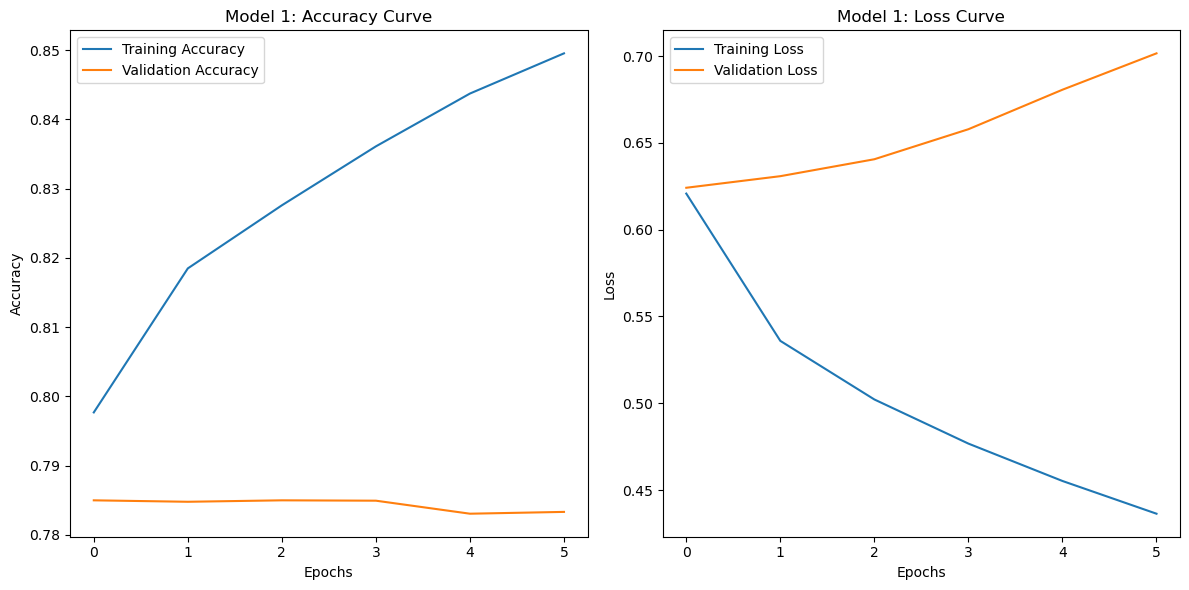

In [112]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model 1: Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model 1: Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [113]:
save_results(
    question_number="5.6.1_region_",
    model_name='TF_IDF deep learning',
    features='TF-IDF',
    model_parameters=' remove_diacritics,normalize_letters, remove_repeated_characters, remove_urls,remove_hashtags,remove_punctuation',
    preprocessing_methods="optimizer=adam,loss=categorical_crossentropyepochs=6,batch_size=64",
    accuracy=test_accuracy,
    balance_accuracy=test_f1,
)


# مهمة 06 : التمثيل الداللي

Semantic representation

## [6.1]

In [44]:
fasttext_model = fasttext.load_model('C://Users//EUROPELAPTOP//Desktop//5th//NLP//Labs//NLP_homework//cc.ar.300.bin')

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Function to extract embeddings
def get_embeddings(words, model):
   
    embeddings = []
    valid_words = []
    for word in words:
        if word in model:
            embeddings.append(model[word])
            valid_words.append(word)
    return np.array(embeddings), valid_words

def prepare_data(top_words, model):
    category_embeddings = {}
    for category, words in top_words.items():
        embeddings, valid_words = get_embeddings(words, model)
        category_embeddings[category] = (embeddings, valid_words)
    return category_embeddings


In [46]:
def plot_embeddings(category_embeddings, title):
   
    plt.figure(figsize=(12, 8))

    for category, (embeddings, words) in category_embeddings.items():
        if len(embeddings) > 0:
            # Adjust perplexity dynamically
            max_perplexity = len(embeddings) - 1
            perplexity = min(30, max_perplexity)  # Set a max default value of 30
            print(f"Category: {category}, Samples: {len(embeddings)}, Perplexity: {perplexity}")
            
            tsne = TSNE(n_components=2, random_state=42, perplexity=perplexity)
            reduced_embeddings = tsne.fit_transform(embeddings)
            
            plt.scatter(
                reduced_embeddings[:, 0],
                reduced_embeddings[:, 1],
                label=category,
                alpha=0.7
            )
            # Uncomment the following block to annotate points
            # for i, word in enumerate(words):
            #     plt.annotate(word, (reduced_embeddings[i, 0], reduced_embeddings[i, 1]))

    plt.title(title)
    plt.legend()
    plt.show()


## [6.2]

In [47]:
top_log_odds_region_500 = extract_top_words(region_word_ratios,500)
top_log_odds_country_500 = extract_top_words(country_word_ratios,500)
top_log_odds_city_500 = extract_top_words(city_word_ratios, 500)

In [48]:
region_embeddings_500 = prepare_data(top_log_odds_region_500, fasttext_model)
country_embeddings_500 = prepare_data(top_log_odds_country_500, fasttext_model)
city_embeddings_500 = prepare_data(top_log_odds_city_500, fasttext_model)

Category: Levant, Samples: 37, Perplexity: 30
Category: Nile_Basin, Samples: 66, Perplexity: 30
Category: Maghreb, Samples: 60, Perplexity: 30
Category: Iraqi, Samples: 41, Perplexity: 30
Category: Gulf, Samples: 63, Perplexity: 30
Category: Yemen, Samples: 32, Perplexity: 30


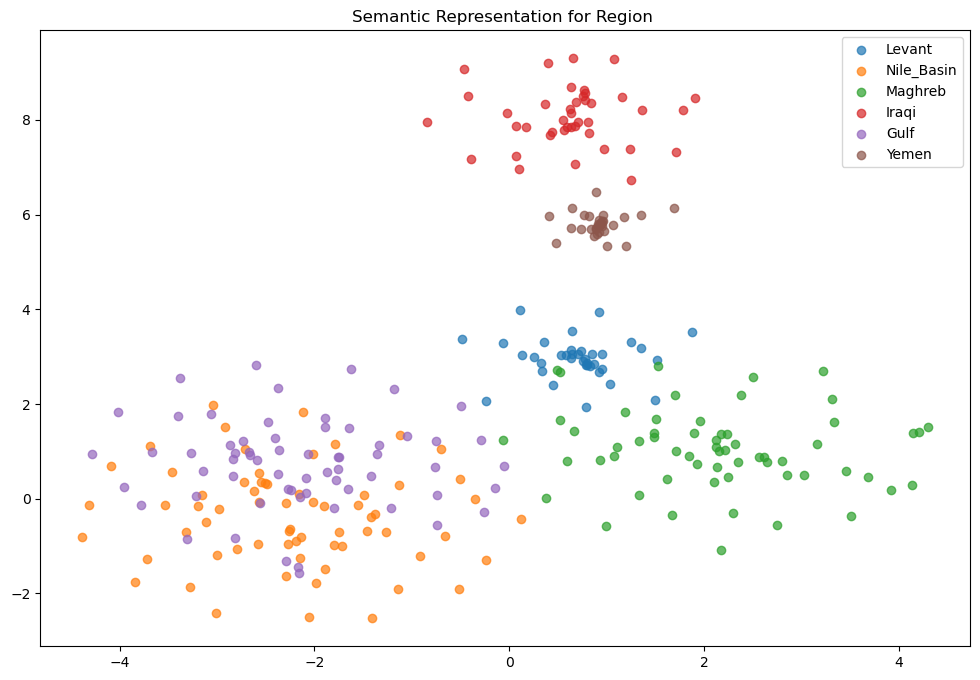

Category: Syria, Samples: 24, Perplexity: 23
Category: Egypt, Samples: 63, Perplexity: 30
Category: Algeria, Samples: 41, Perplexity: 30
Category: Jordan, Samples: 37, Perplexity: 30
Category: Iraq, Samples: 41, Perplexity: 30
Category: Lebanon, Samples: 35, Perplexity: 30
Category: Libya, Samples: 34, Perplexity: 30
Category: Qatar, Samples: 43, Perplexity: 30
Category: Morocco, Samples: 34, Perplexity: 30
Category: Saudi Arabia, Samples: 33, Perplexity: 30
Category: Palestine, Samples: 30, Perplexity: 29
Category: Sudan, Samples: 54, Perplexity: 30
Category: Oman, Samples: 53, Perplexity: 30
Category: Yemen, Samples: 32, Perplexity: 30
Category: Tunisia, Samples: 35, Perplexity: 30
Category: Emirates, Samples: 16, Perplexity: 15
Category: Kawait, Samples: 17, Perplexity: 16
Category: Bahrin, Samples: 22, Perplexity: 21


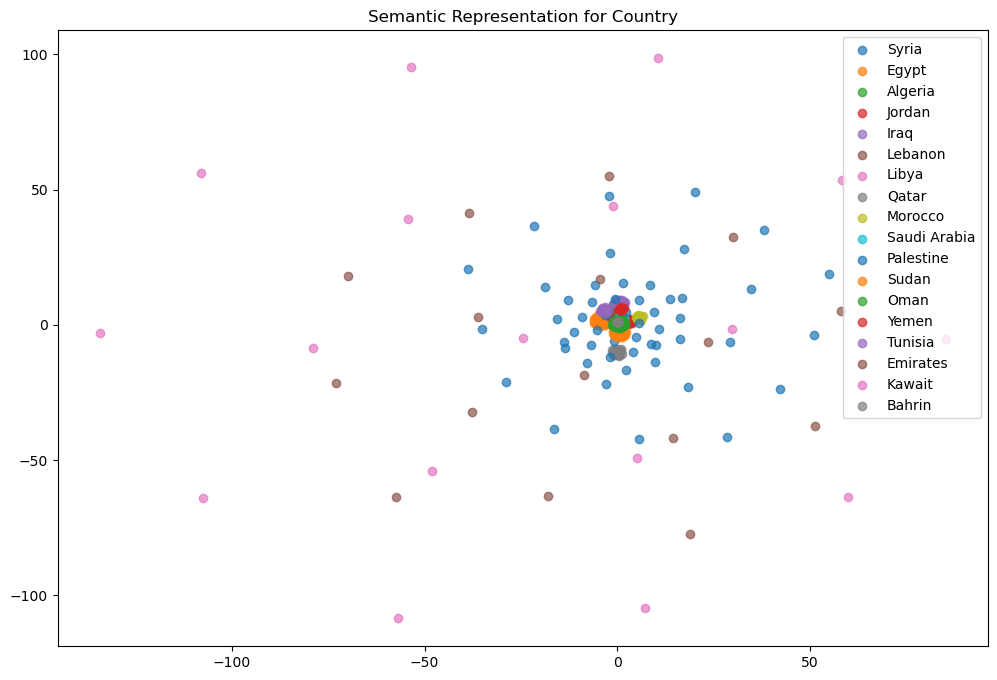

Category: ALE, Samples: 23, Perplexity: 22
Category: ALX, Samples: 50, Perplexity: 30
Category: ALG, Samples: 35, Perplexity: 30
Category: AMM, Samples: 37, Perplexity: 30
Category: ASW, Samples: 36, Perplexity: 30
Category: BAG, Samples: 30, Perplexity: 29
Category: BAS, Samples: 34, Perplexity: 30
Category: BEI, Samples: 28, Perplexity: 27
Category: BEN, Samples: 36, Perplexity: 30
Category: CAI, Samples: 39, Perplexity: 30
Category: DAM, Samples: 27, Perplexity: 26
Category: DOH, Samples: 43, Perplexity: 30
Category: FES, Samples: 19, Perplexity: 18
Category: JED, Samples: 31, Perplexity: 30
Category: JER, Samples: 31, Perplexity: 30
Category: KHA, Samples: 51, Perplexity: 30
Category: MOS, Samples: 17, Perplexity: 16
Category: MUS, Samples: 53, Perplexity: 30
Category: RAB, Samples: 34, Perplexity: 30
Category: RIY, Samples: 61, Perplexity: 30
Category: SAL, Samples: 36, Perplexity: 30
Category: SAN, Samples: 31, Perplexity: 30
Category: SFX, Samples: 25, Perplexity: 24
Category: T

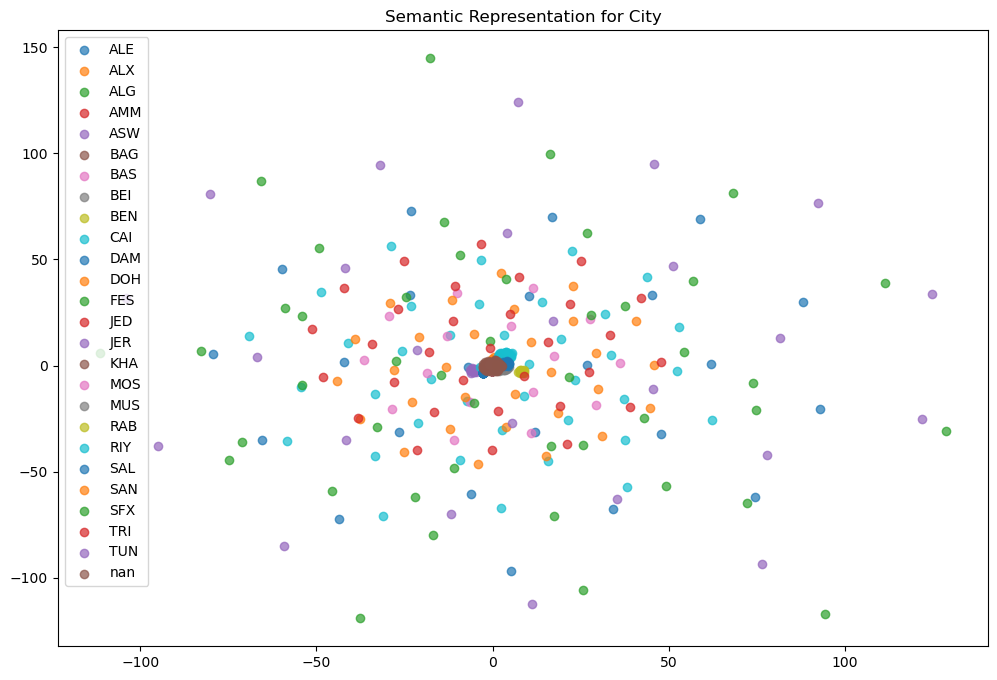

In [70]:
# Plot for each level
plot_embeddings(region_embeddings_100, "Semantic Representation for Region ")
plot_embeddings(country_embeddings_100, "Semantic Representation for Country")
plot_embeddings(city_embeddings_100, "Semantic Representation for City")

Category: Levant, Samples: 206, Perplexity: 30
Category: Nile_Basin, Samples: 294, Perplexity: 30
Category: Maghreb, Samples: 254, Perplexity: 30
Category: Iraqi, Samples: 211, Perplexity: 30
Category: Gulf, Samples: 312, Perplexity: 30
Category: Yemen, Samples: 113, Perplexity: 30


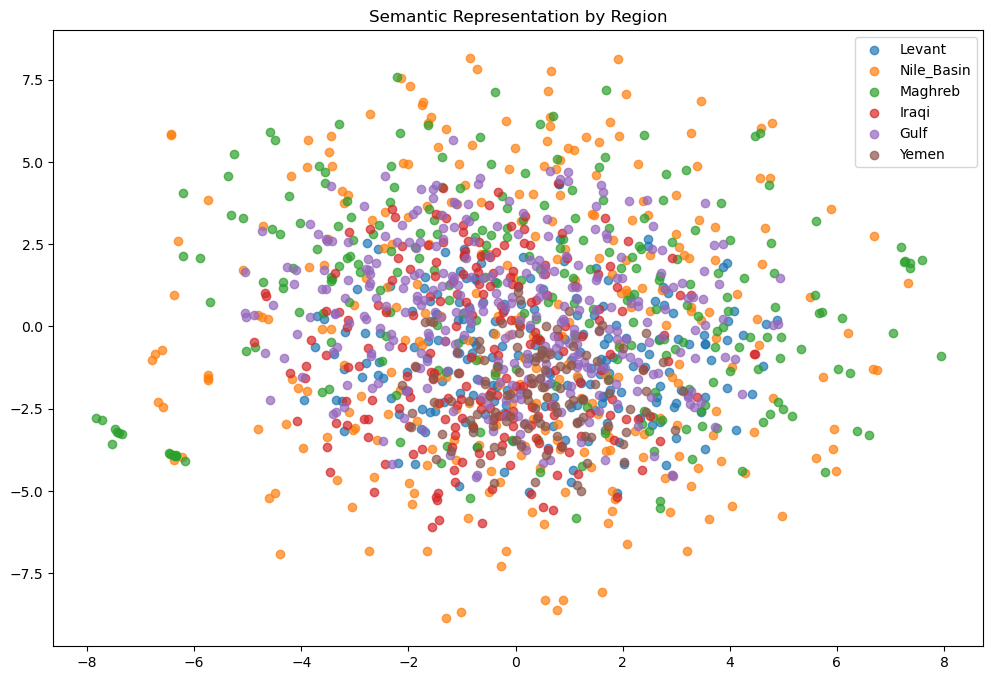

Category: Syria, Samples: 126, Perplexity: 30
Category: Egypt, Samples: 280, Perplexity: 30
Category: Algeria, Samples: 143, Perplexity: 30
Category: Jordan, Samples: 137, Perplexity: 30
Category: Iraq, Samples: 211, Perplexity: 30
Category: Lebanon, Samples: 155, Perplexity: 30
Category: Libya, Samples: 173, Perplexity: 30
Category: Qatar, Samples: 229, Perplexity: 30
Category: Morocco, Samples: 163, Perplexity: 30
Category: Saudi Arabia, Samples: 171, Perplexity: 30
Category: Palestine, Samples: 99, Perplexity: 30
Category: Sudan, Samples: 162, Perplexity: 30
Category: Oman, Samples: 135, Perplexity: 30
Category: Yemen, Samples: 113, Perplexity: 30
Category: Tunisia, Samples: 170, Perplexity: 30
Category: Emirates, Samples: 93, Perplexity: 30
Category: Kawait, Samples: 106, Perplexity: 30
Category: Bahrin, Samples: 86, Perplexity: 30


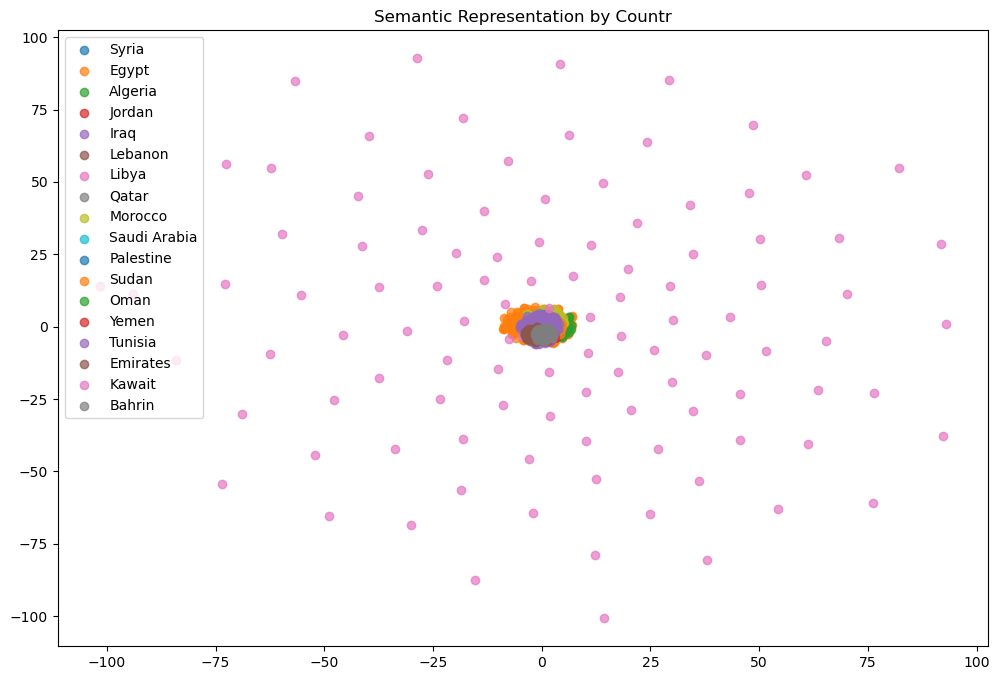

Category: ALE, Samples: 250, Perplexity: 30
Category: ALX, Samples: 327, Perplexity: 30
Category: ALG, Samples: 255, Perplexity: 30
Category: AMM, Samples: 345, Perplexity: 30
Category: ASW, Samples: 256, Perplexity: 30
Category: BAG, Samples: 312, Perplexity: 30
Category: BAS, Samples: 263, Perplexity: 30
Category: BEI, Samples: 140, Perplexity: 30
Category: BEN, Samples: 280, Perplexity: 30
Category: CAI, Samples: 172, Perplexity: 30
Category: DAM, Samples: 260, Perplexity: 30
Category: DOH, Samples: 226, Perplexity: 30
Category: FES, Samples: 165, Perplexity: 30
Category: JED, Samples: 314, Perplexity: 30
Category: JER, Samples: 334, Perplexity: 30
Category: KHA, Samples: 373, Perplexity: 30
Category: MOS, Samples: 99, Perplexity: 30
Category: MUS, Samples: 387, Perplexity: 30
Category: RAB, Samples: 129, Perplexity: 30
Category: RIY, Samples: 424, Perplexity: 30
Category: SAL, Samples: 383, Perplexity: 30
Category: SAN, Samples: 230, Perplexity: 30
Category: SFX, Samples: 166, Perp

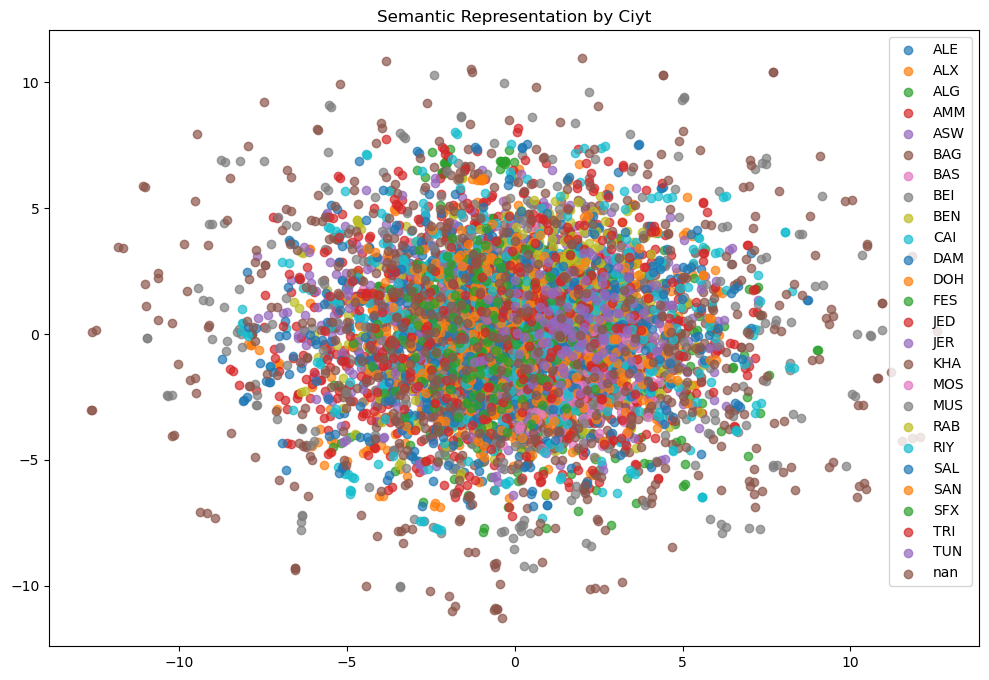

In [49]:
# Plot for each level
plot_embeddings(region_embeddings_500, "Semantic Representation by Region")
plot_embeddings(country_embeddings_500, "Semantic Representation by Countr")
plot_embeddings(city_embeddings_500, "Semantic Representation by Ciyt")

# Final Results

In [ ]:
df = pd.DataFrame(comparison_table)
df

In [ ]:
df.to_csv("[your_name].csv", index=False)